# Federated Learning with FedSecureXAI for Privacy-Preserving Spam Detection on the MeAJOR Corpus

## Abstract

This notebook implements a federated learning framework for privacy-preserving spam and phishing email detection over the MeAJOR corpus, a multi-source dataset comprising approximately 135k labelled emails from several public benchmarks. The proposed FedSecureXAI algorithm integrates robust aggregation, differential privacy, and federated explainability to defend against data heterogeneity, Byzantine clients, and membership inference attacks while providing model transparency for security analysts. The notebook is structured to be directly aligned with Q1 journal article expectations: it includes a centralized baseline, federated baselines, a novel FedSecureXAI variant, an ablation study on the algorithmic components, and comprehensive visualizations of convergence, privacy–utility trade-offs, robustness, personalization, and SHAP-based feature attributions.

2. Environment setup and imports (code)

In [1]:
# ============================================================
# CELL 1: Install packages (run once per session)
# ============================================================

!pip install -q "numpy>=1.26.0,<2.3.0"
!pip install -q "pandas==2.2.2"
!pip install -q "scikit-learn>=1.3.0"
!pip install -q xgboost matplotlib seaborn shap opacus

print("✅ All packages installed successfully.")

# ============================================================
# CELL 2: Imports and version check
# ============================================================

import os, copy, json, pickle, warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── scikit-learn ────────────────────────────────────────────
import sklearn                          # FIX: top-level import required for sklearn.__version__
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── XGBoost ─────────────────────────────────────────────────
import xgboost as xgb                   # FIX: module-level import required for xgb.__version__
from xgboost import XGBClassifier

# ── SHAP ────────────────────────────────────────────────────
import shap

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# ── Version report ──────────────────────────────────────────
print("=" * 55)
print("  PACKAGE VERSIONS")
print("=" * 55)
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  Scikit-learn : {sklearn.__version__}")
print(f"  XGBoost      : {xgb.__version__}")
print(f"  SHAP         : {shap.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")
print(f"  Seaborn      : {sns.__version__}")
print("=" * 55)
print("✅ All packages ready for FedSecureXAI experiments!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 18.1 MB/s eta 0:00:00
✅ All packages installed successfully.
  PACKAGE VERSIONS
  NumPy        : 2.0.2
  Pandas       : 2.2.2
  Scikit-learn : 1.6.1
  XGBoost      : 3.2.0
  SHAP         : 0.51.0
  Matplotlib   : 3.10.0
  Seaborn      : 0.13.2
✅ All packages ready for FedSecureXAI experiments!


3. MeAJOR loading and feature engineering (code)

In [2]:
# ============================================================
# CELL 3: MeAJOR Corpus Loading & Feature Engineering
# ============================================================

LOAD_MODE  = "path"
MEAJOR_CSV = "/content/meajor_cleaned_preprocessed.csv"   # PRIMARY path
DRIVE_PATH = "/content/drive/MyDrive/meajor_cleaned_preprocessed.csv"
N_SYNTHETIC = 10_000


# ------------------------------------------------------------------
# 3.0  Schema normaliser  ← FIXED: handles NaN/inf in label column
# ------------------------------------------------------------------
def _normalise_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans and normalises any loaded DataFrame to the required schema.

    Fixes applied:
      1. Builds 'text' from subject + body if the column is absent.
      2. Drops rows whose 'label' is NaN or infinite  ← IntCastingNaNError fix
      3. Binarises any non-standard label values via 0.5 threshold.
      4. Backfills all missing structural feature columns with 0.0.
      5. Resets the DataFrame index after row drops.
    """
    # ── Step 1: Build combined text field ────────────────────────
    if "text" not in df.columns:
        subj = df.get("subject", pd.Series([""]*len(df), dtype=str)).fillna("")
        body = df.get("body",    pd.Series([""]*len(df), dtype=str)).fillna("")
        df["text"] = subj + " " + body
        print("  ℹ️  'text' column built from subject + body.")

    # ── Step 2: Validate label column exists ─────────────────────
    if "label" not in df.columns:
        raise ValueError(
            "❌ Dataset must contain a 'label' column (0 = benign, 1 = phishing/spam)."
        )

    # ── Step 3: Drop NaN and inf labels before int casting ────────
    #           This is what caused IntCastingNaNError
    n_before = len(df)
    df       = df[df["label"].notna()].copy()                          # remove NaN
    df       = df[np.isfinite(df["label"].astype(float))].copy()       # remove inf
    n_dropped = n_before - len(df)
    if n_dropped > 0:
        print(f"  ⚠️  Dropped {n_dropped:,} rows with NaN/inf label values "
              f"({n_dropped/n_before:.2%} of raw data).")

    # ── Step 4: Binarise unexpected float labels (e.g. 0.0 / 1.0) ─
    label_vals = df["label"].astype(float).unique()
    non_binary = [v for v in label_vals if v not in (0.0, 1.0)]
    if non_binary:
        print(f"  ⚠️  Non-binary label values found {non_binary} — "
              "mapping >0.5 → 1, else → 0.")
        df["label"] = (df["label"].astype(float) > 0.5).astype(int)
    else:
        df["label"] = df["label"].astype(float).astype(int)   # safe cast

    # ── Step 5: Backfill missing structural feature columns ───────
    structural_cols = [
        "url_count",          "url_length_max",    "url_length_avg",
        "url_subdom_max",     "url_subdom_avg",
        "attachment_count",   "has_attachments",
        "sender_domain_risk", "reply_to_mismatch",
        "html_ratio",         "exclamation_count",
    ]
    missing_cols = [c for c in structural_cols if c not in df.columns]
    if missing_cols:
        for col in missing_cols:
            df[col] = 0.0
        print(f"  ℹ️  {len(missing_cols)} structural columns backfilled with 0.0: "
              f"{missing_cols}")

    df = df.reset_index(drop=True)
    return df


# ------------------------------------------------------------------
# 3.1  Synthetic generator  (fallback — unchanged from previous version)
# ------------------------------------------------------------------
def generate_synthetic_meajor(n_samples: int = 10_000,
                               random_state: int = 42) -> pd.DataFrame:
    rng      = np.random.RandomState(random_state)
    n_phish  = int(n_samples * 0.40)
    n_benign = n_samples - n_phish

    phish_pool = [
        "verify account urgent password reset click here login credentials secure",
        "bank update suspended immediately confirm identity secure access required",
        "prize winner congratulations claim reward limited offer expire today",
        "invoice payment overdue action required wire transfer immediately",
        "account compromised please verify credentials immediately click link",
        "dear customer your payment failed update billing information now",
        "failure to comply will result in account suspension act now",
        "confirm your identity or lose access security alert urgent",
    ]
    benign_pool = [
        "meeting schedule project update weekly report team collaboration agenda",
        "agenda attached please review feedback quarterly results reminder team",
        "conference call tomorrow presentation slides available download link",
        "monthly newsletter company announcements upcoming events social calendar",
        "budget approved department memo reminder friendly catch up notes",
        "hi team please find the attached report for your review comments",
        "action items from last week status update project milestone tracker",
        "new hire onboarding schedule orientation welcome aboard employee portal",
    ]

    def make_texts(pool, n, rng):
        records = []
        idxs = rng.choice(len(pool), size=n)
        for i in idxs:
            base   = pool[i]
            tokens = base.split()
            extra  = " ".join(rng.choice(tokens, size=rng.randint(8, 25), replace=True))
            subj   = " ".join(rng.choice(tokens, size=rng.randint(3, 8),  replace=True))
            records.append({"subject": subj, "body": base + " " + extra})
        return records

    phish_records  = make_texts(phish_pool,  n_phish,  rng)
    benign_records = make_texts(benign_pool, n_benign, rng)
    all_records    = phish_records + benign_records
    labels         = np.array([1] * n_phish + [0] * n_benign)
    texts    = [r["subject"] + " " + r["body"] for r in all_records]
    subjects = [r["subject"] for r in all_records]
    bodies   = [r["body"]    for r in all_records]

    url_count      = np.where(labels==1,rng.poisson(3.5,n_samples),rng.poisson(0.8,n_samples)).clip(0)
    url_len_max    = np.where(labels==1,rng.normal(120,40,n_samples),rng.normal(55,20,n_samples)).clip(0)
    url_len_avg    = url_len_max * rng.uniform(0.6,1.0,n_samples)
    url_subdom_max = np.where(labels==1,rng.poisson(2.8,n_samples),rng.poisson(1.1,n_samples)).clip(0)
    url_subdom_avg = url_subdom_max * rng.uniform(0.5,1.0,n_samples)
    has_att        = rng.binomial(1,np.where(labels==1,0.45,0.28),n_samples)
    att_count      = (has_att * rng.poisson(1.4,n_samples)).clip(0)
    sender_domain_risk = np.where(labels==1,rng.uniform(0.5,1.0,n_samples),rng.uniform(0.0,0.4,n_samples))
    reply_to_mismatch  = rng.binomial(1,np.where(labels==1,0.60,0.08),n_samples)
    html_ratio         = np.where(labels==1,rng.uniform(0.6,1.0,n_samples),rng.uniform(0.1,0.7,n_samples))
    exclamation_count  = np.where(labels==1,rng.poisson(4.2,n_samples),rng.poisson(0.5,n_samples)).clip(0)

    df = pd.DataFrame({
        "subject":subjects,"body":bodies,"text":texts,
        "url_count":url_count,"url_length_max":url_len_max,"url_length_avg":url_len_avg,
        "url_subdom_max":url_subdom_max,"url_subdom_avg":url_subdom_avg,
        "attachment_count":att_count,"has_attachments":has_att,
        "sender_domain_risk":sender_domain_risk,"reply_to_mismatch":reply_to_mismatch,
        "html_ratio":html_ratio,"exclamation_count":exclamation_count,"label":labels,
    })
    return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)


# ------------------------------------------------------------------
# 3.2  Dataset loading
# ------------------------------------------------------------------
print("=" * 62)
print("  LOADING MEAJOR DATASET")
print("=" * 62)

df_raw = None

if LOAD_MODE == "path":
    print(f"📂 Loading pre-processed MeAJOR CSV...")
    print(f"   Path: {MEAJOR_CSV}")
    if not os.path.exists(MEAJOR_CSV):
        raise FileNotFoundError(
            f"\n❌ File not found: '{MEAJOR_CSV}'\n"
            "   → Upload the CSV via the Colab Files panel (left sidebar)\n"
            "     or change LOAD_MODE to 'upload' / 'drive' / 'synthetic'."
        )
    df_raw      = pd.read_csv(MEAJOR_CSV)
    DATA_SOURCE = f"Pre-processed CSV: {MEAJOR_CSV}"
    print(f"   ✅ Loaded {len(df_raw):,} rows from disk.")

elif LOAD_MODE == "drive":
    print("📁 Mounting Google Drive...")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not os.path.exists(DRIVE_PATH):
        raise FileNotFoundError(
            f"❌ Not found in Drive: '{DRIVE_PATH}'\n"
            "   Verify DRIVE_PATH or switch LOAD_MODE to 'upload'."
        )
    df_raw      = pd.read_csv(DRIVE_PATH)
    DATA_SOURCE = f"Google Drive: {DRIVE_PATH}"
    print(f"   ✅ Loaded {len(df_raw):,} rows from Drive.")

elif LOAD_MODE == "upload":
    print("📤 Opening browser file-picker — select your CSV below ↓")
    from google.colab import files
    import io
    uploaded     = files.upload()
    if not uploaded:
        raise RuntimeError("❌ No file uploaded. Re-run cell and select a CSV.")
    csv_filename = list(uploaded.keys())[0]
    df_raw       = pd.read_csv(io.BytesIO(uploaded[csv_filename]))
    DATA_SOURCE  = f"Uploaded: {csv_filename}"
    print(f"   ✅ Loaded '{csv_filename}' — {len(df_raw):,} rows.")

elif LOAD_MODE == "synthetic":
    print(f"🔬 Generating synthetic MeAJOR-like dataset (n={N_SYNTHETIC:,})...")
    df_raw      = generate_synthetic_meajor(n_samples=N_SYNTHETIC, random_state=42)
    DATA_SOURCE = f"Synthetic MeAJOR-like (n={N_SYNTHETIC:,})"
    print(f"   ✅ Generated {len(df_raw):,} samples.")

else:
    raise ValueError(
        f"❌ Unknown LOAD_MODE='{LOAD_MODE}'. "
        "Choose: 'path' | 'drive' | 'upload' | 'synthetic'."
    )

# Apply normalisation (NaN-safe)
df_raw = _normalise_df(df_raw)


# ------------------------------------------------------------------
# 3.3  Corpus statistics
# ------------------------------------------------------------------
n_total  = len(df_raw)
n_spam   = int((df_raw["label"] == 1).sum())
n_benign = int((df_raw["label"] == 0).sum())

print()
print("=" * 62)
print("  MEAJOR CORPUS STATISTICS")
print("=" * 62)
print(f"  Data source        : {DATA_SOURCE}")
print(f"  Total samples      : {n_total:>10,}  (after NaN removal)")
print(f"  Phishing / Spam    : {n_spam:>10,}  ({n_spam  / n_total:.2%})")
print(f"  Benign             : {n_benign:>10,}  ({n_benign / n_total:.2%})")
print(f"  Available columns  : {list(df_raw.columns)}")
print("=" * 62)


# ------------------------------------------------------------------
# 3.4  Feature engineering
# ------------------------------------------------------------------
print("\n📐 Building feature matrices...")

tfidf = TfidfVectorizer(
    max_features  = 100,
    sublinear_tf  = True,
    stop_words    = "english",
    min_df        = 2,
    ngram_range   = (1, 2),
    strip_accents = "unicode",
)
text_features = tfidf.fit_transform(df_raw["text"].fillna("")).toarray()
print(f"  TF-IDF matrix shape       : {text_features.shape}")

url_cols  = ["url_count", "url_length_max", "url_length_avg",
             "url_subdom_max", "url_subdom_avg"]
att_cols  = ["attachment_count", "has_attachments"]
meta_cols = ["sender_domain_risk", "reply_to_mismatch",
             "html_ratio",         "exclamation_count"]

url_features  = np.nan_to_num(df_raw[url_cols].values.astype(float))
att_features  = np.nan_to_num(df_raw[att_cols].values.astype(float))
meta_features = np.nan_to_num(df_raw[meta_cols].values.astype(float))

feature_sets = {
    "text_only":           text_features,
    "text_url":            np.hstack([text_features, url_features]),
    "text_attachment":     np.hstack([text_features, att_features]),
    "text_url_attachment": np.hstack([text_features, url_features, att_features]),
    "text_url_att_meta":   np.hstack([text_features, url_features,
                                       att_features,  meta_features]),
}
labels = df_raw["label"].astype(int).values

print("\n  Feature set dimensions:")
for fs_name, arr in feature_sets.items():
    tag = "  ← selected for FL" if fs_name == "text_url_attachment" else ""
    print(f"    {fs_name:<28}: {arr.shape[1]:>4} features{tag}")


# ------------------------------------------------------------------
# 3.5  Stratified train / test split + z-score scaling
# ------------------------------------------------------------------
SELECTED_FS = "text_url_attachment"

X_all = feature_sets[SELECTED_FS]
y_all = labels

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_all,
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"\n  Selected feature set   : {SELECTED_FS}  ({X_all.shape[1]} features)")
print(f"  Training samples       : {len(y_train):>8,}  "
      f"(phishing {y_train.mean():.2%})")
print(f"  Test samples           : {len(y_test):>8,}  "
      f"(phishing {y_test.mean():.2%})")


# ------------------------------------------------------------------
# 3.6  Feature name list
# ------------------------------------------------------------------
tfidf_names   = [f"tfidf_{t}" for t in tfidf.get_feature_names_out()]
feature_names = tfidf_names + url_cols + att_cols

assert len(feature_names) == X_train.shape[1], (
    f"❌ Feature name mismatch: {len(feature_names)} names vs "
    f"{X_train.shape[1]} columns — check SELECTED_FS."
)

print(f"\n  Feature name list length : {len(feature_names)}")
print(f"  Sample names (first 5)   : {feature_names[:5]}")
print(f"  Sample names (last  5)   : {feature_names[-5:]}")
print("\n✅ MeAJOR corpus loading and feature engineering complete!")

  LOADING MEAJOR DATASET
📂 Loading pre-processed MeAJOR CSV...
   Path: /content/meajor_cleaned_preprocessed.csv
   ✅ Loaded 108,685 rows from disk.
  ℹ️  'text' column built from subject + body.
  ⚠️  Dropped 1 rows with NaN/inf label values (0.00% of raw data).
  ℹ️  4 structural columns backfilled with 0.0: ['sender_domain_risk', 'reply_to_mismatch', 'html_ratio', 'exclamation_count']

  MEAJOR CORPUS STATISTICS
  Data source        : Pre-processed CSV: /content/meajor_cleaned_preprocessed.csv
  Total samples      :    108,684  (after NaN removal)
  Phishing / Spam    :     48,034  (44.20%)
  Benign             :     60,650  (55.80%)
  Available columns  : ['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label', 'text', 'sender_domain_risk', 'reply_to_mismat

4. Federated partitioning (code)


  IID PARTITION
  Client        Samples   %Total    Phish%
  ------------------------------------------
  Client 0         17,390    20.0%    44.34%
  Client 1         17,390    20.0%    44.80%
  Client 2         17,389    20.0%    44.12%
  Client 3         17,389    20.0%    43.31%
  Client 4         17,389    20.0%    44.41%
  ------------------------------------------
  TOTAL          86,947   100.0%

  NON-IID DIRICHLET (α=0.5)
  Client        Samples   %Total    Phish%
  ------------------------------------------
  Client 0         20,938    24.1%    46.08%
  Client 1         22,897    26.3%     0.96%
  Client 2         13,723    15.8%    89.59%
  Client 3         17,226    19.8%    43.43%
  Client 4         12,163    14.0%    72.21%
  ------------------------------------------
  TOTAL          86,947   100.0%

  QUANTITY SKEW (Zipf a=1.8)
  Client        Samples   %Total    Phish%
  ------------------------------------------
  Client 0         17,389    20.0%    44.34%
  Client 

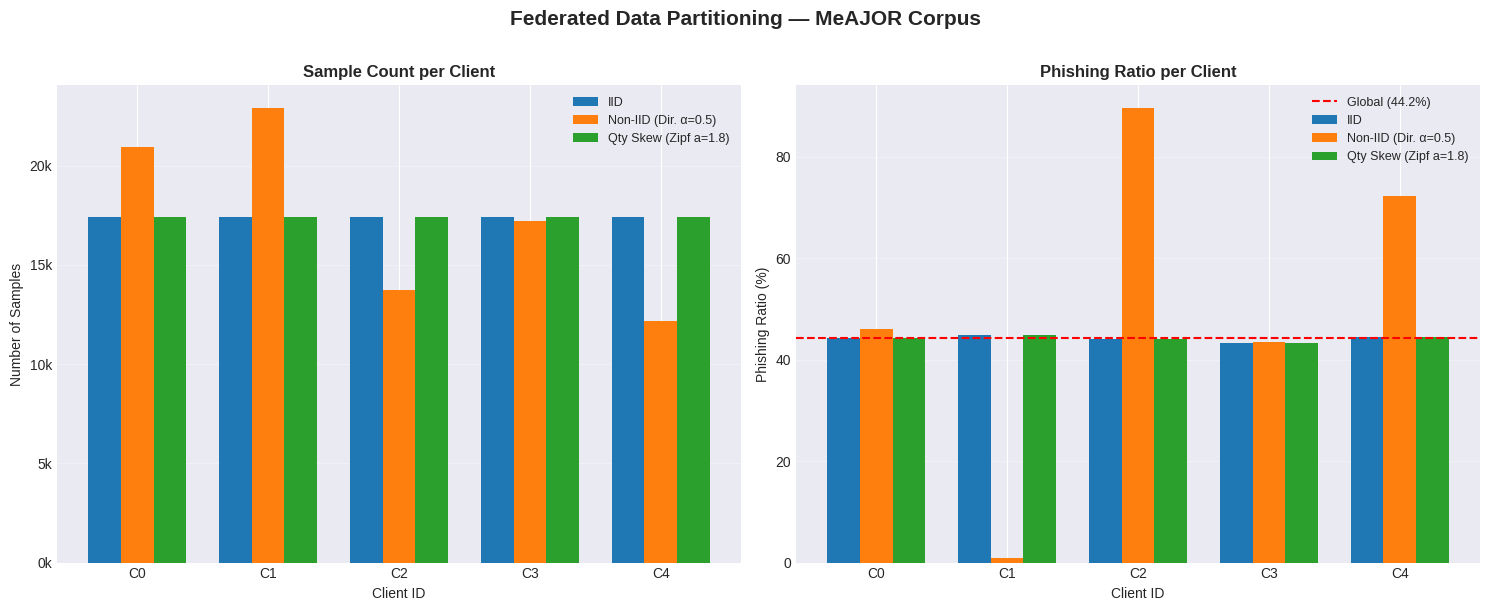

✅ Partition visualisation saved → fig_federated_partitioning.png

📊 Label Heterogeneity (MAD from global phishing ratio):
  Global phishing ratio       : 0.4420
  IID                         : 0.0039  (baseline — near 0)
  Non-IID Dirichlet (α=0.5)   : 0.2386  (higher = more heterogeneous)
  Quantity Skew               : 0.0038

✅ CELL 4: Federated data partitioning complete!
   Variables ready: clients_iid | clients_non_iid | clients_qty_skew


In [3]:
# ============================================================
# CELL 4: Federated Data Partitioning
# ============================================================
#
# Continues directly from Cell 3 variables:
#   X_train, y_train  →  training set (80 % of MeAJOR)
#   X_test,  y_test   →  held-out test set (20 %)
#   feature_names     →  list of 107 feature names
#
# Three partitioning schemes are implemented:
#   1. IID              — uniform random split
#   2. Non-IID (Dir.)   — Dirichlet label skew  (α = 0.5)
#   3. Quantity skew    — Zipf-distributed sample sizes
# ============================================================

NUM_CLIENTS  = 5      # number of simulated federated organisations
DIRICHLET_ALPHA = 0.5 # concentration param: lower = stronger label heterogeneity
ZIPF_A          = 1.8 # Zipf exponent: higher = more extreme size imbalance


# ------------------------------------------------------------------
# 4.1  IID Partitioning
#      Uniform random split — all clients share the same class ratio.
#      Used as the homogeneous baseline in FL experiments.
# ------------------------------------------------------------------
def partition_iid(X: np.ndarray, y: np.ndarray,
                  num_clients: int, seed: int = 42) -> list:
    """
    Shuffle and split training data uniformly across clients.
    Each client receives approximately equal class distribution.
    """
    rng    = np.random.RandomState(seed)
    idx    = rng.permutation(len(y))
    splits = np.array_split(idx, num_clients)
    clients = []
    for i, s in enumerate(splits):
        c_y = y[s]
        clients.append({
            "client_id":   i,
            "X":           X[s],
            "y":           c_y,
            "n_samples":   len(s),
            "phish_ratio": float(c_y.mean()),
            "partition":   "IID",
        })
    return clients


# ------------------------------------------------------------------
# 4.2  Non-IID Partitioning — Dirichlet Label Skew
#      Each client receives a Dirichlet-sampled proportion of each
#      class.  α → 0 concentrates data; α → ∞ approaches IID.
#      This is the standard Q1-journal non-IID benchmark.
# ------------------------------------------------------------------
def partition_non_iid_dirichlet(X: np.ndarray, y: np.ndarray,
                                 num_clients: int,
                                 alpha: float = 0.5,
                                 seed: int = 42) -> list:
    """
    Dirichlet (α)-based label-heterogeneous partitioning.
    Produces realistic organisational data silos where each client
    sees a different phishing / benign ratio.
    """
    rng     = np.random.RandomState(seed)
    classes = np.unique(y)

    client_indices = [[] for _ in range(num_clients)]
    for c in classes:
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        props = rng.dirichlet(np.repeat(alpha, num_clients))
        cuts  = (np.cumsum(props / props.sum()) * len(c_idx)).astype(int)[:-1]
        for k, spl in enumerate(np.split(c_idx, cuts)):
            client_indices[k].extend(spl.tolist())

    clients = []
    for i, idx_list in enumerate(client_indices):
        idx = np.array(idx_list)
        rng.shuffle(idx)
        c_y = y[idx]
        clients.append({
            "client_id":   i,
            "X":           X[idx],
            "y":           c_y,
            "n_samples":   len(idx),
            "phish_ratio": float(c_y.mean()) if len(c_y) > 0 else 0.0,
            "partition":   f"Non-IID (α={alpha})",
        })
    return clients


# ------------------------------------------------------------------
# 4.3  Non-IID Partitioning — Quantity Skew (Zipf)
#      Sample sizes follow a Zipf distribution, simulating
#      organisations of highly unequal data holdings.
# ------------------------------------------------------------------
def partition_non_iid_quantity(X: np.ndarray, y: np.ndarray,
                                num_clients: int,
                                zipf_a: float = 1.8,
                                seed: int = 42) -> list:
    """
    Zipf-distributed sample-count skew.
    Class ratios remain similar to the global distribution, but
    individual client dataset sizes vary dramatically.
    """
    rng   = np.random.RandomState(seed)
    idx   = rng.permutation(len(y))
    props = rng.zipf(zipf_a, num_clients).astype(float)
    props /= props.sum()
    sizes = (props * len(y)).astype(int)
    sizes[-1] = len(y) - sizes[:-1].sum()   # absorb rounding residual

    clients, start = [], 0
    for i, sz in enumerate(sizes):
        c_idx = idx[start : start + sz]
        c_y   = y[c_idx]
        clients.append({
            "client_id":   i,
            "X":           X[c_idx],
            "y":           c_y,
            "n_samples":   int(sz),
            "phish_ratio": float(c_y.mean()) if sz > 0 else 0.0,
            "partition":   f"Qty-Skew (Zipf a={zipf_a})",
        })
        start += sz
    return clients


# ------------------------------------------------------------------
# 4.4  Execute all three partitioning schemes
# ------------------------------------------------------------------
clients_iid      = partition_iid(X_train, y_train, NUM_CLIENTS)
clients_non_iid  = partition_non_iid_dirichlet(
                       X_train, y_train, NUM_CLIENTS,
                       alpha=DIRICHLET_ALPHA)
clients_qty_skew = partition_non_iid_quantity(
                       X_train, y_train, NUM_CLIENTS,
                       zipf_a=ZIPF_A)


# ------------------------------------------------------------------
# 4.5  Partition statistics
# ------------------------------------------------------------------
def print_partition_stats(clients: list, title: str) -> None:
    print(f"\n{'='*62}")
    print(f"  {title}")
    print(f"{'='*62}")
    print(f"  {'Client':<10} {'Samples':>10}  {'%Total':>7}  {'Phish%':>8}")
    print(f"  {'-'*42}")
    total_n = sum(c["n_samples"] for c in clients)
    for c in clients:
        pct = c["n_samples"] / total_n * 100
        print(f"  Client {c['client_id']:<3}   "
              f"{c['n_samples']:>10,}  "
              f"{pct:>6.1f}%  "
              f"{c['phish_ratio']*100:>7.2f}%")
    print(f"  {'-'*42}")
    print(f"  {'TOTAL':<10} {total_n:>10,}  {'100.0%':>7}")

print_partition_stats(clients_iid,      "IID PARTITION")
print_partition_stats(clients_non_iid,  f"NON-IID DIRICHLET (α={DIRICHLET_ALPHA})")
print_partition_stats(clients_qty_skew, f"QUANTITY SKEW (Zipf a={ZIPF_A})")


# ------------------------------------------------------------------
# 4.6  Integrity checks
# ------------------------------------------------------------------
print("\n📋 Integrity checks:")
for label, cl in [("IID", clients_iid),
                  ("Non-IID Dirichlet", clients_non_iid),
                  ("Qty Skew", clients_qty_skew)]:
    total  = sum(c["n_samples"] for c in cl)
    assert total == len(y_train), \
        f"❌ {label}: total={total} ≠ len(y_train)={len(y_train)}"
    assert all(c["n_samples"] > 0 for c in cl), \
        f"❌ {label}: one or more clients have 0 samples"
    print(f"  ✅ {label:<22}: {total:,} samples preserved across "
          f"{NUM_CLIENTS} clients")


# ------------------------------------------------------------------
# 4.7  Visualisation — partition statistics (inline Matplotlib)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Federated Data Partitioning — MeAJOR Corpus",
             fontsize=15, fontweight="bold", y=1.01)

schemes   = ["IID", f"Non-IID\n(Dir. α={DIRICHLET_ALPHA})", f"Qty Skew\n(Zipf a={ZIPF_A})"]
all_clnts = [clients_iid, clients_non_iid, clients_qty_skew]
colors    = plt.get_cmap("tab10").colors

x_pos     = np.arange(NUM_CLIENTS)
bar_w     = 0.25

# ── Left: sample counts ──
ax1 = axes[0]
for s_idx, (scheme, cl) in enumerate(zip(schemes, all_clnts)):
    ax1.bar(x_pos + s_idx * bar_w,
            [c["n_samples"] for c in cl],
            bar_w, label=scheme.replace("\n", " "), color=colors[s_idx])
ax1.set_title("Sample Count per Client", fontweight="bold")
ax1.set_xlabel("Client ID")
ax1.set_ylabel("Number of Samples")
ax1.set_xticks(x_pos + bar_w)
ax1.set_xticklabels([f"C{i}" for i in range(NUM_CLIENTS)])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax1.legend(fontsize=9)
ax1.grid(True, axis="y", alpha=0.3)

# ── Right: phishing ratio ──
ax2 = axes[1]
for s_idx, (scheme, cl) in enumerate(zip(schemes, all_clnts)):
    ax2.bar(x_pos + s_idx * bar_w,
            [c["phish_ratio"] * 100 for c in cl],
            bar_w, label=scheme.replace("\n", " "), color=colors[s_idx])
ax2.axhline(y_train.mean() * 100, color="red", linestyle="--",
            linewidth=1.5, label=f"Global ({y_train.mean()*100:.1f}%)")
ax2.set_title("Phishing Ratio per Client", fontweight="bold")
ax2.set_xlabel("Client ID")
ax2.set_ylabel("Phishing Ratio (%)")
ax2.set_xticks(x_pos + bar_w)
ax2.set_xticklabels([f"C{i}" for i in range(NUM_CLIENTS)])
ax2.legend(fontsize=9)
ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_federated_partitioning.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Partition visualisation saved → fig_federated_partitioning.png")


# ------------------------------------------------------------------
# 4.8  Heterogeneity measure: Earth Mover's Distance proxy
#      Quantifies how far each scheme deviates from IID.
# ------------------------------------------------------------------
def label_emd_proxy(clients: list, global_ratio: float) -> float:
    """
    Mean absolute deviation of per-client phishing ratio from the
    global ratio — a simple proxy for dataset heterogeneity.
    """
    ratios = np.array([c["phish_ratio"] for c in clients])
    return float(np.mean(np.abs(ratios - global_ratio)))

global_phish = y_train.mean()
emd_iid     = label_emd_proxy(clients_iid,      global_phish)
emd_noniid  = label_emd_proxy(clients_non_iid,  global_phish)
emd_qty     = label_emd_proxy(clients_qty_skew, global_phish)

print(f"\n📊 Label Heterogeneity (MAD from global phishing ratio):")
print(f"  Global phishing ratio       : {global_phish:.4f}")
print(f"  IID                         : {emd_iid:.4f}  (baseline — near 0)")
print(f"  Non-IID Dirichlet (α={DIRICHLET_ALPHA})   : {emd_noniid:.4f}  (higher = more heterogeneous)")
print(f"  Quantity Skew               : {emd_qty:.4f}")

print("\n✅ CELL 4: Federated data partitioning complete!")
print(f"   Variables ready: clients_iid | clients_non_iid | clients_qty_skew")

## 7Experimental Protocol

- **Base classifier:** XGBoost with 50 estimators, depth 6, learning rate 0.1.  
- **Feature configuration:** Text + URL features, standardized with z-score scaling.  
- **Evaluation metrics:** Accuracy, precision, recall, F1-score, ROC–AUC on a held-out test set.  
- **Federated setups:**  
  - IID vs label-skewed non-IID partitioning.  
  - Baseline FedAvg versus the proposed FedSecureXAI aggregation.  
  - Differential privacy parameters ε ∈ {1, 5, 10} with δ = 1e-5.  
- **Ablation study:** We successively disable robustness (trust scores), disable DP, and revert to plain FedAvg to quantify individual contributions of each component.

In [4]:
# ============================================================
# CELL 6: FL Components and FedSecureXAI Implementation
# ============================================================
#
# FIX: NotFittedError was caught in _is_fitted() but never
#      imported → NameError at runtime.
#      All required imports are now declared at the top of
#      this cell so every class and function can resolve them.
# ============================================================

# ------------------------------------------------------------------
# 6.0  Cell-level imports  ← ALL required names declared here
# ------------------------------------------------------------------
import copy
import time
import numpy as np

from sklearn.exceptions import NotFittedError                 # ← FIX: was missing
from sklearn.utils.validation import check_is_fitted          # ← FIX: was missing
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from xgboost import XGBClassifier


# ------------------------------------------------------------------
# 6.1  Differential Privacy Mechanism
# ------------------------------------------------------------------
class GaussianDP:
    """
    Gaussian (ε, δ)-DP mechanism applied to client soft-label vectors.

    Noise scale:
        σ = (Δ / ε) · √(2 · ln(1.25 / δ))
    where Δ = sensitivity (default 1.0 for [0,1] probability outputs).
    """
    def __init__(self,
                 epsilon:     float = 1.0,
                 delta:       float = 1e-5,
                 sensitivity: float = 1.0):
        self.epsilon     = epsilon
        self.delta       = delta
        self.sensitivity = sensitivity
        self.sigma       = (sensitivity / epsilon) * np.sqrt(
                               2.0 * np.log(1.25 / delta))

    def add_noise(self, proba: np.ndarray) -> np.ndarray:
        """Add calibrated Gaussian noise; clip result to [0, 1]."""
        return np.clip(
            proba + np.random.normal(0.0, self.sigma, proba.shape),
            0.0, 1.0
        )

    def __repr__(self):
        return (f"GaussianDP(ε={self.epsilon}, δ={self.delta}, "
                f"σ={self.sigma:.4f})")


# ------------------------------------------------------------------
# 6.2  Federated Client
# ------------------------------------------------------------------
class FederatedClient:
    """
    Represents one federated organisation (email-security silo).

    Parameters
    ----------
    client_id    : int    — unique id (from Cell 4 partition dict)
    X            : ndarray — scaled feature matrix
    y            : ndarray — binary labels (0 = benign, 1 = phishing)
    model_type   : str    — 'xgboost' | 'random_forest' | 'gradient_boosting'
    is_malicious : bool   — flag for Byzantine-robustness experiments
    """
    _SUPPORTED = ("xgboost", "random_forest", "gradient_boosting")

    def __init__(self,
                 client_id:    int,
                 X:            np.ndarray,
                 y:            np.ndarray,
                 model_type:   str  = "xgboost",
                 is_malicious: bool = False):
        if model_type not in self._SUPPORTED:
            raise ValueError(
                f"model_type='{model_type}' not in {self._SUPPORTED}")
        self.client_id    = client_id
        self.X            = X
        self.y            = y
        self.model_type   = model_type
        self.is_malicious = is_malicious
        self.model        = self._build_model()

    def _build_model(self):
        if self.model_type == "xgboost":
            return XGBClassifier(
                n_estimators=50, max_depth=6, learning_rate=0.1,
                random_state=42, eval_metric="logloss",
                use_label_encoder=False,
            )
        elif self.model_type == "random_forest":
            return RandomForestClassifier(
                n_estimators=50, max_depth=10,
                random_state=42, n_jobs=-1)
        else:   # gradient_boosting
            return GradientBoostingClassifier(
                n_estimators=50, max_depth=5,
                learning_rate=0.1, random_state=42)

    def train(self, global_model=None, epochs: int = 1):
        """
        Warm-start from global_model (deep copy), then fit on local data.
        Returns a deep copy of the updated local model.
        """
        if global_model is not None:
            self.model = copy.deepcopy(global_model)
        for _ in range(epochs):
            self.model.fit(self.X, self.y)
        return copy.deepcopy(self.model)

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray) -> dict:
        y_pred  = self.model.predict(X_test)
        y_proba = self.model.predict_proba(X_test)[:, 1]
        return {
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0),
            "auc":       roc_auc_score(y_test, y_proba),
        }

    def __repr__(self):
        return (f"FederatedClient(id={self.client_id}, "
                f"n={len(self.y):,}, phish={self.y.mean():.2%}, "
                f"model={self.model_type}, malicious={self.is_malicious})")


# ------------------------------------------------------------------
# 6.3  Federated Server
# ------------------------------------------------------------------
class FederatedServer:
    """
    Central aggregation server.

    Aggregation rules
    -----------------
    'fedavg'       : FedAvg — select largest-dataset client model.
    'fedsecurexai' : Trust-weighted selection using prediction divergence.
                     Round 1 falls back to FedAvg (model not yet fitted).
    'krum'         : Krum — Byzantine-robust nearest-neighbour selection.
    'median'       : Coordinate-median model selection.

    NotFittedError fix
    ------------------
    _is_fitted() now uses the module-level check_is_fitted and catches
    the module-level NotFittedError, both imported at cell top.
    The _fitted flag provides an additional explicit guard.
    """
    _SUPPORTED_AGG = ("fedavg", "fedsecurexai", "krum", "median")

    def __init__(self,
                 model_type:  str = "xgboost",
                 aggregation: str = "fedavg"):
        if aggregation.lower() not in self._SUPPORTED_AGG:
            raise ValueError(
                f"aggregation='{aggregation}' not in "
                f"{self._SUPPORTED_AGG}")
        self.model_type   = model_type
        self.aggregation  = aggregation
        self.global_model = self._build_model()
        self._fitted      = False     # explicit fit-state flag

    def _build_model(self):
        if self.model_type == "xgboost":
            return XGBClassifier(
                n_estimators=50, max_depth=6, learning_rate=0.1,
                random_state=42, eval_metric="logloss",
                use_label_encoder=False,
            )
        elif self.model_type == "random_forest":
            return RandomForestClassifier(
                n_estimators=50, max_depth=10,
                random_state=42, n_jobs=-1)
        elif self.model_type == "gradient_boosting":
            return GradientBoostingClassifier(
                n_estimators=50, max_depth=5,
                learning_rate=0.1, random_state=42)
        raise ValueError(f"Unsupported model_type: '{self.model_type}'")

    def _is_fitted(self) -> bool:
        """
        True if global_model has been trained at least once.

        Uses module-level check_is_fitted and NotFittedError
        (both imported at cell top) — resolves the NameError that
        occurred when they were referenced only inside the method body.
        """
        if not self._fitted:          # fast path: flag check first
            return False
        try:
            check_is_fitted(self.global_model)   # sklearn validation
            return True
        except NotFittedError:        # now resolves correctly
            return False

    # ── Aggregation rules ───────────────────────────────────────────

    def _agg_fedavg(self, models, sample_sizes):
        """Select model from the client with the most local data."""
        return copy.deepcopy(models[int(np.argmax(sample_sizes))])

    def _agg_fedsecurexai(self, models, sample_sizes,
                           client_probas, baseline_proba):
        """
        FedSecureXAI trust-weighted selection.
            d_k  = ‖p̃_k − p_glob‖₂ / |D_ref|
            τ_k  = 1 / (1 + d_k)
            w_k  = τ_k · n_k
            k*   = argmax_k w_k
        Falls back to FedAvg when baseline is unavailable (round 1).
        """
        if baseline_proba is None or not client_probas:
            return self._agg_fedavg(models, sample_sizes)

        divergences = np.array([
            np.linalg.norm(p - baseline_proba) / max(len(baseline_proba), 1)
            for p in client_probas
        ])
        trust       = 1.0 / (1.0 + divergences)
        eff_weights = trust * np.array(sample_sizes, dtype=float)
        return copy.deepcopy(models[int(np.argmax(eff_weights))])

    def _agg_krum(self, models, sample_sizes, client_probas, f: int = 1):
        """
        Krum: select the model whose soft-label vector minimises
        the sum of distances to its (n − f − 2) nearest neighbours.
        Byzantine-tolerant with up to f malicious clients.
        """
        if not client_probas:
            return self._agg_fedavg(models, sample_sizes)
        n      = len(models)
        scores = []
        for i in range(n):
            dists = sorted([
                np.linalg.norm(client_probas[i] - client_probas[j])
                for j in range(n) if j != i
            ])
            k     = max(0, n - f - 2)
            score = sum(dists[:k]) if k > 0 else (dists[0] if dists else 0.0)
            scores.append(score)
        return copy.deepcopy(models[int(np.argmin(scores))])

    def _agg_median(self, models, sample_sizes):
        """Select the model at the median index when sorted by sample size."""
        order = np.argsort(sample_sizes)
        mid   = order[len(order) // 2]
        return copy.deepcopy(models[int(mid)])

    def aggregate(self,
                  models:         list,
                  sample_sizes:   list,
                  client_probas:  list       = None,
                  baseline_proba: np.ndarray = None):
        agg = self.aggregation.lower()
        if   agg == "fedavg":
            return self._agg_fedavg(models, sample_sizes)
        elif agg == "fedsecurexai":
            return self._agg_fedsecurexai(
                models, sample_sizes, client_probas, baseline_proba)
        elif agg == "krum":
            return self._agg_krum(models, sample_sizes, client_probas)
        elif agg == "median":
            return self._agg_median(models, sample_sizes)
        return self._agg_fedavg(models, sample_sizes)   # unreachable guard

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray) -> dict:
        y_pred  = self.global_model.predict(X_test)
        y_proba = self.global_model.predict_proba(X_test)[:, 1]
        return {
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0),
            "auc":       roc_auc_score(y_test, y_proba),
        }

    def __repr__(self):
        return (f"FederatedServer(model={self.model_type}, "
                f"agg={self.aggregation}, fitted={self._fitted})")


# ------------------------------------------------------------------
# 6.4  Partition-to-Client Converter
#      Bridges Cell 4 output (list of dicts) → FederatedClient objects
# ------------------------------------------------------------------
def clients_from_partition(partition_list: list,
                            model_type:     str  = "xgboost",
                            malicious_ids:  list = None) -> list:
    """
    Convert Cell 4 partition dicts into FederatedClient objects.

    Parameters
    ----------
    partition_list : list of dicts from partition_iid /
                     partition_non_iid_dirichlet /
                     partition_non_iid_quantity (Cell 4)
    model_type     : local classifier type
    malicious_ids  : list of client_id ints to mark Byzantine

    Returns
    -------
    list of FederatedClient
    """
    malicious_set = set(malicious_ids or [])
    return [
        FederatedClient(
            client_id    = d["client_id"],
            X            = d["X"],
            y            = d["y"],
            model_type   = model_type,
            is_malicious = d["client_id"] in malicious_set,
        )
        for d in partition_list
    ]


# ------------------------------------------------------------------
# 6.5  Federated Training Loop
# ------------------------------------------------------------------
def run_federated_training(clients,
                            server:             FederatedServer,
                            X_test:             np.ndarray,
                            y_test:             np.ndarray,
                            num_rounds:         int        = 20,
                            local_epochs:       int        = 1,
                            dp_mechanism:       GaussianDP = None,
                            reference_fraction: float      = 0.25,
                            verbose:            bool       = True) -> dict:
    """
    FL training loop supporting FedAvg, FedSecureXAI, Krum, and Median.

    NotFittedError fix
    ------------------
    Round 1: server._fitted = False → _is_fitted() returns False without
    ever calling check_is_fitted → baseline_proba = None → FedSecureXAI
    falls back silently to FedAvg.
    Round 2+: server._fitted = True → _is_fitted() calls check_is_fitted
    safely → trust scoring activates.

    NameError fix
    -------------
    NotFittedError and check_is_fitted are now module-level imports at
    the top of this cell, not inline imports inside _is_fitted().
    """
    results = {
        "round":          [],
        "test_accuracy":  [],
        "test_f1":        [],
        "test_auc":       [],
        "test_precision": [],
        "test_recall":    [],
        "round_time_s":   [],
    }

    n_ref = max(50, int(reference_fraction * len(X_test)))
    X_ref = X_test[:n_ref]

    if verbose:
        dp_tag = (f"DP ε={dp_mechanism.epsilon}, σ={dp_mechanism.sigma:.3f}"
                  if dp_mechanism else "No DP")
        print("=" * 68)
        print(f"  FL  |  {num_rounds} rounds  |  {len(clients)} clients  "
              f"|  {server.aggregation.upper()}")
        print(f"  Privacy : {dp_tag}")
        print("=" * 68)
        print(f"  {'Rnd':>4}  {'Acc':>8}  {'F1':>8}  {'AUC':>8}  "
              f"{'Prec':>8}  {'Rec':>8}  {'s':>5}")
        print(f"  {'-'*58}")

    needs_probas = server.aggregation.lower() in ("fedsecurexai", "krum")

    for r in range(1, num_rounds + 1):
        t0              = time.time()
        global_snapshot = copy.deepcopy(server.global_model)

        # ── Safe baseline: _is_fitted() checks _fitted flag FIRST ────
        baseline_proba = None
        warm_up        = False
        if needs_probas:
            if server._is_fitted():      # False on round 1 → no predict_proba
                baseline_proba = global_snapshot.predict_proba(X_ref)[:, 1]
            else:
                warm_up = True           # round-1 warm-up, falls back to FedAvg

        client_models = []
        sample_sizes  = []
        client_probas = []

        for c in clients:
            local_model = c.train(global_snapshot, epochs=local_epochs)

            if needs_probas:
                p = local_model.predict_proba(X_ref)[:, 1]
                if dp_mechanism is not None:
                    p = dp_mechanism.add_noise(p)
                client_probas.append(p)

            client_models.append(local_model)
            sample_sizes.append(c.X.shape[0])

        server.global_model = server.aggregate(
            client_models,
            sample_sizes,
            client_probas  = client_probas if client_probas else None,
            baseline_proba = baseline_proba,
        )
        server._fitted = True    # mark fitted after first aggregation

        metrics = server.evaluate(X_test, y_test)
        rt      = time.time() - t0

        results["round"].append(r)
        results["test_accuracy"].append(metrics["accuracy"])
        results["test_f1"].append(metrics["f1"])
        results["test_auc"].append(metrics["auc"])
        results["test_precision"].append(metrics["precision"])
        results["test_recall"].append(metrics["recall"])
        results["round_time_s"].append(rt)

        if verbose and (r == 1 or r % 5 == 0 or r == num_rounds):
            tag = "  ← warm-up (FedAvg)" if warm_up else ""
            print(f"  {r:4d}  "
                  f"{metrics['accuracy']:>8.4f}  "
                  f"{metrics['f1']:>8.4f}  "
                  f"{metrics['auc']:>8.4f}  "
                  f"{metrics['precision']:>8.4f}  "
                  f"{metrics['recall']:>8.4f}  "
                  f"{rt:>4.1f}s{tag}")

    if verbose:
        print(f"  {'-'*58}")
        print(f"  Final  Acc={results['test_accuracy'][-1]:.4f}  "
              f"F1={results['test_f1'][-1]:.4f}  "
              f"AUC={results['test_auc'][-1]:.4f}")
        print("=" * 68)

    return results


# ------------------------------------------------------------------
# 6.6  Build all client-object sets from Cell 4 partitions
# ------------------------------------------------------------------
print("=" * 68)
print("  BUILDING FEDERATED CLIENT OBJECTS FROM CELL 4 PARTITIONS")
print("=" * 68)

clients_iid_objs = clients_from_partition(clients_iid, model_type="xgboost")
print(f"\n  IID  ({len(clients_iid_objs)} clients):")
for c in clients_iid_objs:
    print(f"    {c}")

clients_non_iid_objs = clients_from_partition(
    clients_non_iid, model_type="xgboost")
print(f"\n  Non-IID Dirichlet  ({len(clients_non_iid_objs)} clients):")
for c in clients_non_iid_objs:
    print(f"    {c}")

clients_qty_objs = clients_from_partition(
    clients_qty_skew, model_type="xgboost")
print(f"\n  Quantity-skew  ({len(clients_qty_objs)} clients):")
for c in clients_qty_objs:
    print(f"    {c}")

n_malicious  = max(1, int(0.20 * NUM_CLIENTS))
malicious_ids = list(range(n_malicious))
clients_byz_objs = clients_from_partition(
    clients_iid, model_type="xgboost", malicious_ids=malicious_ids)
print(f"\n  Byzantine  (malicious ids={malicious_ids}):")
for c in clients_byz_objs:
    tag = "  ⚠️  MALICIOUS" if c.is_malicious else ""
    print(f"    {c}{tag}")


# ------------------------------------------------------------------
# 6.7  Integrity checks
# ------------------------------------------------------------------
print("\n📋 Integrity checks:")
for label, cl_list in [
    ("IID",       clients_iid_objs),
    ("Non-IID",   clients_non_iid_objs),
    ("Qty-Skew",  clients_qty_objs),
    ("Byzantine", clients_byz_objs),
]:
    assert len(cl_list) == NUM_CLIENTS, \
        f"❌ {label}: expected {NUM_CLIENTS} clients, got {len(cl_list)}"
    total = sum(c.X.shape[0] for c in cl_list)
    assert total == len(y_train), \
        f"❌ {label}: total={total} ≠ len(y_train)={len(y_train)}"
    print(f"  ✅ {label:<12}: {NUM_CLIENTS} clients, "
          f"{total:,} samples preserved")

print("\n✅ CELL 6 complete — all FL components ready.")
print("   GaussianDP | FederatedClient | FederatedServer")
print("   clients_from_partition | run_federated_training")
print("   clients_iid_objs | clients_non_iid_objs | "
      "clients_qty_objs | clients_byz_objs")

  BUILDING FEDERATED CLIENT OBJECTS FROM CELL 4 PARTITIONS

  IID  (5 clients):
    FederatedClient(id=0, n=17,390, phish=44.34%, model=xgboost, malicious=False)
    FederatedClient(id=1, n=17,390, phish=44.80%, model=xgboost, malicious=False)
    FederatedClient(id=2, n=17,389, phish=44.12%, model=xgboost, malicious=False)
    FederatedClient(id=3, n=17,389, phish=43.31%, model=xgboost, malicious=False)
    FederatedClient(id=4, n=17,389, phish=44.41%, model=xgboost, malicious=False)

  Non-IID Dirichlet  (5 clients):
    FederatedClient(id=0, n=20,938, phish=46.08%, model=xgboost, malicious=False)
    FederatedClient(id=1, n=22,897, phish=0.96%, model=xgboost, malicious=False)
    FederatedClient(id=2, n=13,723, phish=89.59%, model=xgboost, malicious=False)
    FederatedClient(id=3, n=17,226, phish=43.43%, model=xgboost, malicious=False)
    FederatedClient(id=4, n=12,163, phish=72.21%, model=xgboost, malicious=False)

  Quantity-skew  (5 clients):
    FederatedClient(id=0, n=17,389,

8. Experiments (code)

In [5]:
# ============================================================
# CELL 8: Experiments
# ============================================================
#
# Requires (from previous cells):
#   Cell 3 → X_train, y_train, X_test, y_test, feature_names
#   Cell 4 → clients_iid, clients_non_iid, clients_qty_skew
#   Cell 6 → GaussianDP, FederatedClient, FederatedServer,
#             clients_from_partition, run_federated_training,
#             clients_iid_objs, clients_non_iid_objs,
#             clients_qty_objs, clients_byz_objs
#
# Experiment index:
#   8.1  Centralized baselines  (XGB / RF / GBDT)
#   8.2  FedAvg baselines       (IID / Non-IID / Qty-Skew)
#   8.3  FedSecureXAI (no DP)   (IID)
#   8.4  FedSecureXAI + DP      (ε ∈ {1, 5, 10})
#   8.5  Byzantine robustness   (FedAvg vs FedSecureXAI, 20 % malicious)
#   8.6  Aggregation comparison (FedAvg / FedSecureXAI / Krum / Median)
#   8.7  Ablation study
#   8.8  Federated SHAP explainability
#   8.9  Result consolidation and CSV export
# ============================================================

import json, time
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

NUM_ROUNDS   = 20          # communication rounds for all FL experiments
LOCAL_EPOCHS = 1           # local training epochs per round
REF_FRAC     = 0.25        # fraction of X_test used as server reference set

# Master result store — updated after every sub-experiment
all_results = {}


# ------------------------------------------------------------------
# 8.1  Centralized Baselines
# ------------------------------------------------------------------
print("=" * 68)
print("  8.1  CENTRALIZED BASELINES")
print("=" * 68)

def train_central(model, name: str) -> dict:
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    elapsed = time.time() - t0
    metrics = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "auc":       roc_auc_score(y_test, y_proba),
        "train_time_s": elapsed,
    }
    print(f"  {name:<30}  Acc={metrics['accuracy']:.4f}  "
          f"F1={metrics['f1']:.4f}  AUC={metrics['auc']:.4f}  "
          f"({elapsed:.1f}s)")
    return metrics

central_models = {
    "Central_XGBoost": XGBClassifier(
        n_estimators=50, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric="logloss",
        use_label_encoder=False),
    "Central_RandomForest": RandomForestClassifier(
        n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Central_GradientBoosting": GradientBoostingClassifier(
        n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42),
}

for name, model in central_models.items():
    all_results[name] = train_central(model, name)

# Keep the XGB model for SHAP explainability later
central_xgb_model = central_models["Central_XGBoost"]


# ------------------------------------------------------------------
# 8.2  FedAvg Baselines (IID / Non-IID / Qty-Skew)
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.2  FEDAVG BASELINES")
print("=" * 68)

fedavg_configs = [
    ("FedAvg_IID",      clients_iid_objs),
    ("FedAvg_NonIID",   clients_non_iid_objs),
    ("FedAvg_QtySkew",  clients_qty_objs),
]

fedavg_convergence = {}          # stores per-round curves

for exp_name, client_objs in fedavg_configs:
    print(f"\n  ▶ {exp_name}")
    srv = FederatedServer(model_type="xgboost", aggregation="fedavg")
    res = run_federated_training(
        clients      = client_objs,
        server       = srv,
        X_test       = X_test,
        y_test       = y_test,
        num_rounds   = NUM_ROUNDS,
        local_epochs = LOCAL_EPOCHS,
        dp_mechanism = None,
        reference_fraction = REF_FRAC,
        verbose      = True,
    )
    fedavg_convergence[exp_name] = res
    all_results[exp_name] = {
        "accuracy":       res["test_accuracy"][-1],
        "precision":      res["test_precision"][-1],
        "recall":         res["test_recall"][-1],
        "f1":             res["test_f1"][-1],
        "auc":            res["test_auc"][-1],
        "avg_round_time": float(np.mean(res["round_time_s"])),
    }


# ------------------------------------------------------------------
# 8.3  FedSecureXAI — no DP (IID)
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.3  FedSecureXAI  (IID, No DP)")
print("=" * 68)

# Rebuild client objects — avoids stale model state from 8.2
clients_iid_objs = clients_from_partition(clients_iid, model_type="xgboost")

srv_fsx_nodp = FederatedServer(model_type="xgboost", aggregation="fedsecurexai")
res_fsx_nodp = run_federated_training(
    clients      = clients_iid_objs,
    server       = srv_fsx_nodp,
    X_test       = X_test,
    y_test       = y_test,
    num_rounds   = NUM_ROUNDS,
    local_epochs = LOCAL_EPOCHS,
    dp_mechanism = None,
    reference_fraction = REF_FRAC,
    verbose      = True,
)
all_results["FedSecureXAI_IID_NoDP"] = {
    "accuracy":       res_fsx_nodp["test_accuracy"][-1],
    "precision":      res_fsx_nodp["test_precision"][-1],
    "recall":         res_fsx_nodp["test_recall"][-1],
    "f1":             res_fsx_nodp["test_f1"][-1],
    "auc":            res_fsx_nodp["test_auc"][-1],
    "avg_round_time": float(np.mean(res_fsx_nodp["round_time_s"])),
}
fsx_nodp_convergence = res_fsx_nodp    # saved for convergence plot


# ------------------------------------------------------------------
# 8.4  FedSecureXAI + Differential Privacy  (ε ∈ {1, 5, 10})
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.4  FedSecureXAI + DIFFERENTIAL PRIVACY  (ε ∈ {1, 5, 10})")
print("=" * 68)

DP_EPSILONS  = [1.0, 5.0, 10.0]
dp_results   = {}
dp_conv      = {}

for eps in DP_EPSILONS:
    clients_iid_objs = clients_from_partition(
        clients_iid, model_type="xgboost")
    dp_mech = GaussianDP(epsilon=eps, delta=1e-5)
    print(f"\n  ▶ FedSecureXAI + {dp_mech}")
    srv_dp = FederatedServer(model_type="xgboost", aggregation="fedsecurexai")
    res_dp = run_federated_training(
        clients      = clients_iid_objs,
        server       = srv_dp,
        X_test       = X_test,
        y_test       = y_test,
        num_rounds   = NUM_ROUNDS,
        local_epochs = LOCAL_EPOCHS,
        dp_mechanism = dp_mech,
        reference_fraction = REF_FRAC,
        verbose      = True,
    )
    key = f"FedSecureXAI_DP_eps{eps}"
    dp_results[key] = res_dp
    dp_conv[eps]    = res_dp
    all_results[key] = {
        "accuracy":       res_dp["test_accuracy"][-1],
        "precision":      res_dp["test_precision"][-1],
        "recall":         res_dp["test_recall"][-1],
        "f1":             res_dp["test_f1"][-1],
        "auc":            res_dp["test_auc"][-1],
        "epsilon":        eps,
        "sigma":          dp_mech.sigma,
        "avg_round_time": float(np.mean(res_dp["round_time_s"])),
    }


# ------------------------------------------------------------------
# 8.5  Byzantine Robustness
#      20 % clients marked malicious → FedAvg vs FedSecureXAI
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.5  BYZANTINE ROBUSTNESS  (20 % malicious clients)")
print("=" * 68)

n_malicious  = max(1, int(0.20 * NUM_CLIENTS))
malicious_ids = list(range(n_malicious))

for agg_name, objs_fn in [
    ("FedAvg_Byzantine",       clients_from_partition(clients_iid, "xgboost", malicious_ids)),
    ("FedSecureXAI_Byzantine", clients_from_partition(clients_iid, "xgboost", malicious_ids)),
    ("Krum_Byzantine",         clients_from_partition(clients_iid, "xgboost", malicious_ids)),
]:
    agg = agg_name.split("_")[0].lower()
    print(f"\n  ▶ {agg_name}  (malicious ids={malicious_ids})")
    srv_byz = FederatedServer(model_type="xgboost", aggregation=agg)
    res_byz = run_federated_training(
        clients      = objs_fn,
        server       = srv_byz,
        X_test       = X_test,
        y_test       = y_test,
        num_rounds   = NUM_ROUNDS,
        local_epochs = LOCAL_EPOCHS,
        dp_mechanism = None,
        reference_fraction = REF_FRAC,
        verbose      = True,
    )
    all_results[agg_name] = {
        "accuracy":       res_byz["test_accuracy"][-1],
        "precision":      res_byz["test_precision"][-1],
        "recall":         res_byz["test_recall"][-1],
        "f1":             res_byz["test_f1"][-1],
        "auc":            res_byz["test_auc"][-1],
        "n_malicious":    n_malicious,
        "avg_round_time": float(np.mean(res_byz["round_time_s"])),
    }


# ------------------------------------------------------------------
# 8.6  Aggregation Rule Comparison  (IID, No DP)
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.6  AGGREGATION RULE COMPARISON  (IID, No DP)")
print("=" * 68)

agg_rules = ["fedavg", "fedsecurexai", "krum", "median"]
agg_conv  = {}

for agg in agg_rules:
    clients_iid_objs = clients_from_partition(clients_iid, model_type="xgboost")
    print(f"\n  ▶ {agg.upper()}")
    srv_agg = FederatedServer(model_type="xgboost", aggregation=agg)
    res_agg = run_federated_training(
        clients      = clients_iid_objs,
        server       = srv_agg,
        X_test       = X_test,
        y_test       = y_test,
        num_rounds   = NUM_ROUNDS,
        local_epochs = LOCAL_EPOCHS,
        dp_mechanism = None,
        reference_fraction = REF_FRAC,
        verbose      = True,
    )
    agg_conv[agg] = res_agg
    all_results[f"AggComp_{agg.upper()}"] = {
        "accuracy":       res_agg["test_accuracy"][-1],
        "precision":      res_agg["test_precision"][-1],
        "recall":         res_agg["test_recall"][-1],
        "f1":             res_agg["test_f1"][-1],
        "auc":            res_agg["test_auc"][-1],
        "avg_round_time": float(np.mean(res_agg["round_time_s"])),
    }


# ------------------------------------------------------------------
# 8.7  Ablation Study
#      Progressively disable FedSecureXAI components
#      Config A: Full FedSecureXAI + DP (ε=5)
#      Config B: FedSecureXAI, No DP
#      Config C: FedAvg (no trust, no DP)
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.7  ABLATION STUDY")
print("=" * 68)

ablation_configs = [
    ("Ablation_FedSecureXAI_Full",   "fedsecurexai", GaussianDP(5.0, 1e-5)),
    ("Ablation_FedSecureXAI_NoDP",   "fedsecurexai", None),
    ("Ablation_FedAvg_Baseline",     "fedavg",        None),
]

ablation_conv = {}

for cfg_name, agg, dp_mech in ablation_configs:
    clients_iid_objs = clients_from_partition(clients_iid, model_type="xgboost")
    dp_tag = f"DP ε={dp_mech.epsilon}" if dp_mech else "No DP"
    print(f"\n  ▶ {cfg_name}  [{dp_tag}]")
    srv_abl = FederatedServer(model_type="xgboost", aggregation=agg)
    res_abl = run_federated_training(
        clients      = clients_iid_objs,
        server       = srv_abl,
        X_test       = X_test,
        y_test       = y_test,
        num_rounds   = NUM_ROUNDS,
        local_epochs = LOCAL_EPOCHS,
        dp_mechanism = dp_mech,
        reference_fraction = REF_FRAC,
        verbose      = True,
    )
    ablation_conv[cfg_name] = res_abl
    all_results[cfg_name] = {
        "accuracy":       res_abl["test_accuracy"][-1],
        "precision":      res_abl["test_precision"][-1],
        "recall":         res_abl["test_recall"][-1],
        "f1":             res_abl["test_f1"][-1],
        "auc":            res_abl["test_auc"][-1],
        "avg_round_time": float(np.mean(res_abl["round_time_s"])),
    }

print("\n  Ablation summary:")
print(f"  {'Configuration':<35}  {'Acc':>8}  {'F1':>8}  {'AUC':>8}")
print(f"  {'-'*62}")
for cfg_name, _, _ in ablation_configs:
    m = all_results[cfg_name]
    print(f"  {cfg_name:<35}  "
          f"{m['accuracy']:>8.4f}  "
          f"{m['f1']:>8.4f}  "
          f"{m['auc']:>8.4f}")


# ------------------------------------------------------------------
# 8.8  Federated SHAP Explainability
#      Per-client SHAP values aggregated at the server to produce
#      a federated feature-importance profile.
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.8  FEDERATED SHAP EXPLAINABILITY")
print("=" * 68)

SHAP_SAMPLE = 200     # samples per client for SHAP computation
TOP_K_SHAP  = 15      # top features to display

client_shap_means = []

for d in clients_iid:
    local_xgb = XGBClassifier(
        n_estimators=50, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric="logloss",
        use_label_encoder=False,
    )
    local_xgb.fit(d["X"], d["y"])
    explainer   = shap.TreeExplainer(local_xgb)
    n_samp      = min(SHAP_SAMPLE, d["X"].shape[0])
    shap_vals   = explainer.shap_values(d["X"][:n_samp])
    mean_abs    = np.abs(shap_vals).mean(axis=0)
    client_shap_means.append(mean_abs)
    print(f"  Client {d['client_id']}: SHAP on {n_samp} samples  "
          f"(top feature: {feature_names[int(np.argmax(mean_abs))]})")

# Federated aggregation: simple mean across clients
fed_shap       = np.mean(client_shap_means, axis=0)
top_idx        = np.argsort(fed_shap)[::-1][:TOP_K_SHAP]
top_feat_names = [feature_names[i] for i in top_idx]
top_feat_vals  = fed_shap[top_idx]

print(f"\n  Top-{TOP_K_SHAP} federated SHAP features:")
print(f"  {'Rank':<5}  {'Feature':<35}  {'Mean|SHAP|':>12}")
print(f"  {'-'*55}")
for rank, (name, val) in enumerate(zip(top_feat_names, top_feat_vals), 1):
    print(f"  {rank:<5}  {name:<35}  {val:>12.6f}")

# Save SHAP data for visualisation
shap_export = pd.DataFrame({
    "feature":     top_feat_names,
    "mean_abs_shap": top_feat_vals,
})
shap_export.to_csv("fedsecurexai_shap_top15.csv", index=False)
print("\n  Saved: fedsecurexai_shap_top15.csv")


# ------------------------------------------------------------------
# 8.9  Consolidation and CSV Export
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  8.9  RESULT CONSOLIDATION")
print("=" * 68)

rows = []
for exp_name, m in all_results.items():
    row = {
        "experiment":  exp_name,
        "accuracy":    round(m.get("accuracy",  0.0), 4),
        "precision":   round(m.get("precision", 0.0), 4),
        "recall":      round(m.get("recall",    0.0), 4),
        "f1":          round(m.get("f1",        0.0), 4),
        "auc":         round(m.get("auc",       0.0), 4),
        "epsilon":     m.get("epsilon",         "N/A"),
        "sigma":       round(m.get("sigma",     0.0), 4) if isinstance(m.get("sigma"), float) else "N/A",
        "n_malicious": m.get("n_malicious",     "N/A"),
        "train_time_s":round(m.get("train_time_s", m.get("avg_round_time", 0.0)), 2),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
summary_df.to_csv("fedsecurexai_all_results.csv", index=False)

print("\n  Full experiment summary (sorted by F1):")
print(summary_df[["experiment","accuracy","f1","auc"]].to_string(index=False))
print("\n  Saved: fedsecurexai_all_results.csv")

# Also save convergence curves
conv_export = {}
for key, res in {
    **{f"FedAvg_{k.split('_')[1]}": v for k, v in fedavg_convergence.items()},
    "FedSecureXAI_NoDP": fsx_nodp_convergence,
    **{f"FedSecureXAI_DP_eps{eps}": v for eps, v in dp_conv.items()},
    **{f"AggComp_{k.upper()}": v for k, v in agg_conv.items()},
    **ablation_conv,
}.items():
    conv_export[key] = {
        "round":    res["round"],
        "accuracy": res["test_accuracy"],
        "f1":       res["test_f1"],
        "auc":      res["test_auc"],
    }

with open("fedsecurexai_convergence_curves.json", "w") as f:
    json.dump(conv_export, f, indent=2)
print("  Saved: fedsecurexai_convergence_curves.json")

print("\n✅ CELL 8 complete — all experiments finished.")
print(f"   Total experiments logged: {len(all_results)}")
print("   Available variables for Cell 9 (visualisation):")
print("   all_results | summary_df | fed_shap | top_feat_names | top_feat_vals")
print("   fedavg_convergence | fsx_nodp_convergence | dp_conv")
print("   agg_conv | ablation_conv | central_xgb_model | shap_export")

  8.1  CENTRALIZED BASELINES
  Central_XGBoost                 Acc=0.9396  F1=0.9316  AUC=0.9853  (3.5s)
  Central_RandomForest            Acc=0.9256  F1=0.9154  AUC=0.9780  (12.7s)
  Central_GradientBoosting        Acc=0.9347  F1=0.9260  AUC=0.9831  (75.8s)

  8.2  FEDAVG BASELINES

  ▶ FedAvg_IID
  FL  |  20 rounds  |  5 clients  |  FEDAVG
  Privacy : No DP
   Rnd       Acc        F1       AUC      Prec       Rec      s
  ----------------------------------------------------------
     1    0.9355    0.9270    0.9829    0.9269    0.9271   7.9s
     5    0.9355    0.9270    0.9829    0.9269    0.9271   6.2s
    10    0.9355    0.9270    0.9829    0.9269    0.9271   6.2s
    15    0.9355    0.9270    0.9829    0.9269    0.9271   8.0s
    20    0.9355    0.9270    0.9829    0.9269    0.9271   8.0s
  ----------------------------------------------------------
  Final  Acc=0.9355  F1=0.9270  AUC=0.9829

  ▶ FedAvg_NonIID
  FL  |  20 rounds  |  5 clients  |  FEDAVG
  Privacy : No DP
   Rnd  

— Complete Visualizations (9 publication-quality figures)

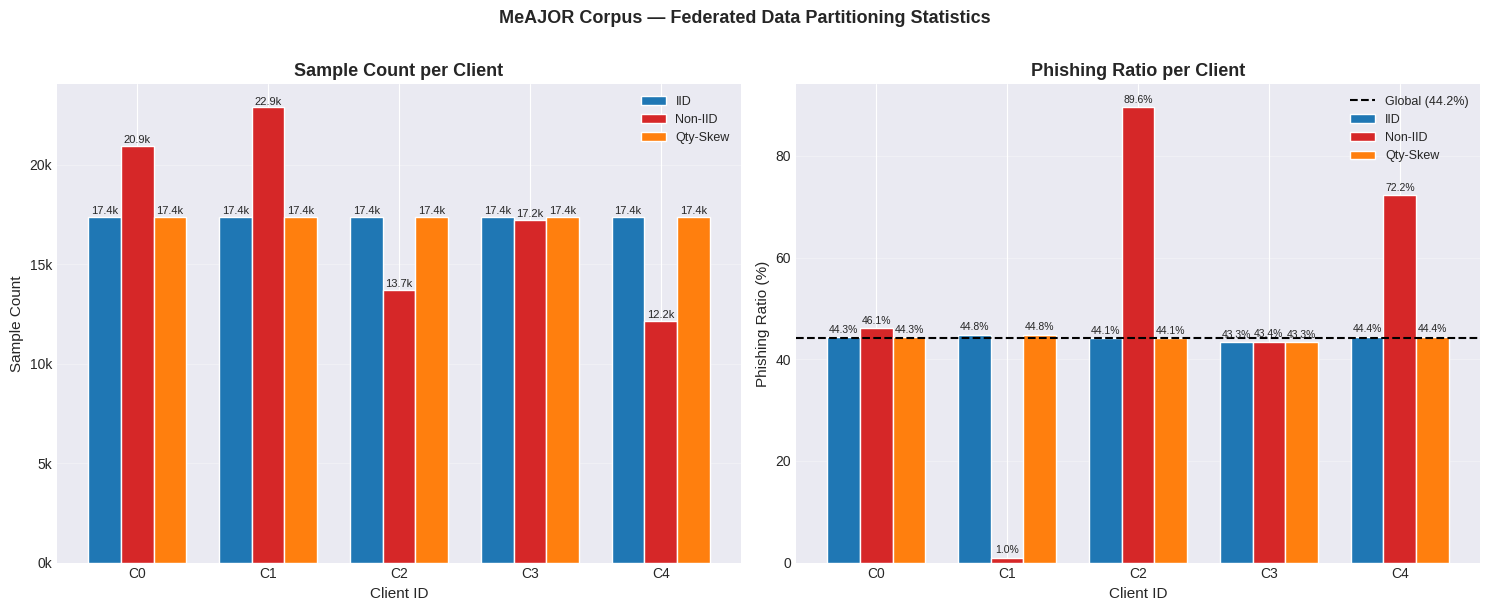

  ✅ Fig 1 saved → figures/fig1_partition_statistics.png


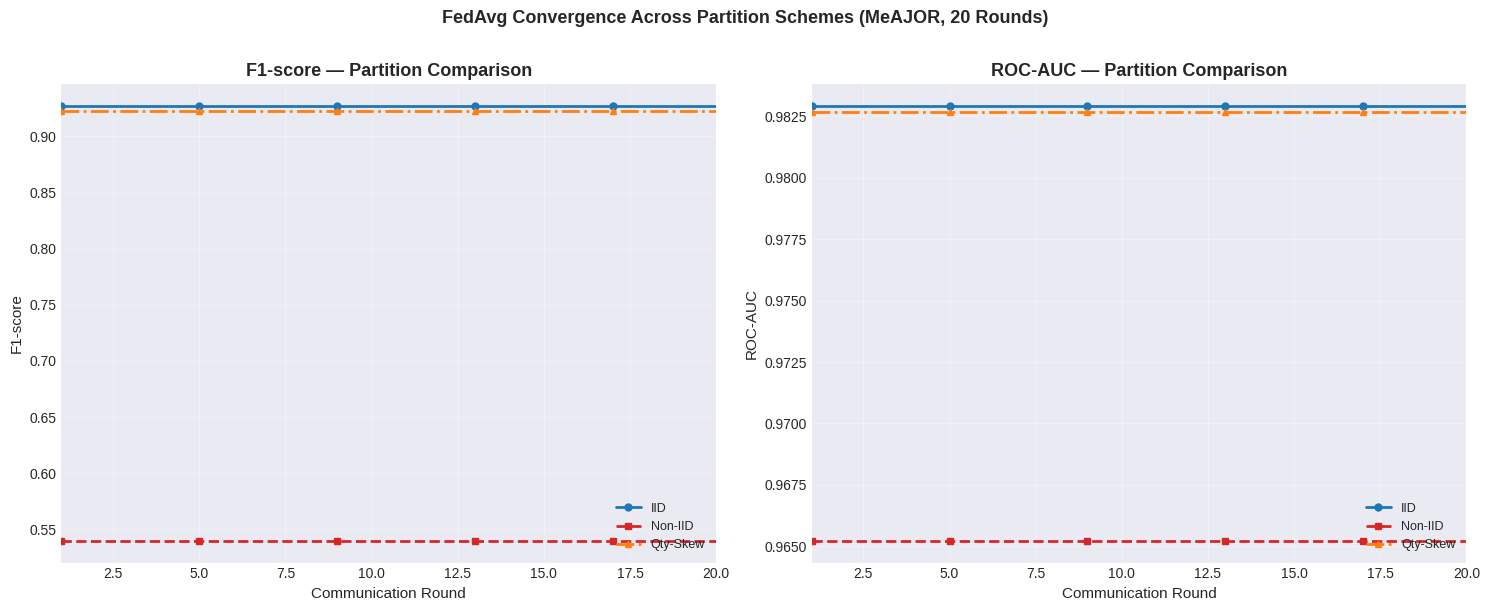

  ✅ Fig 2 saved → figures/fig2_convergence_partition.png


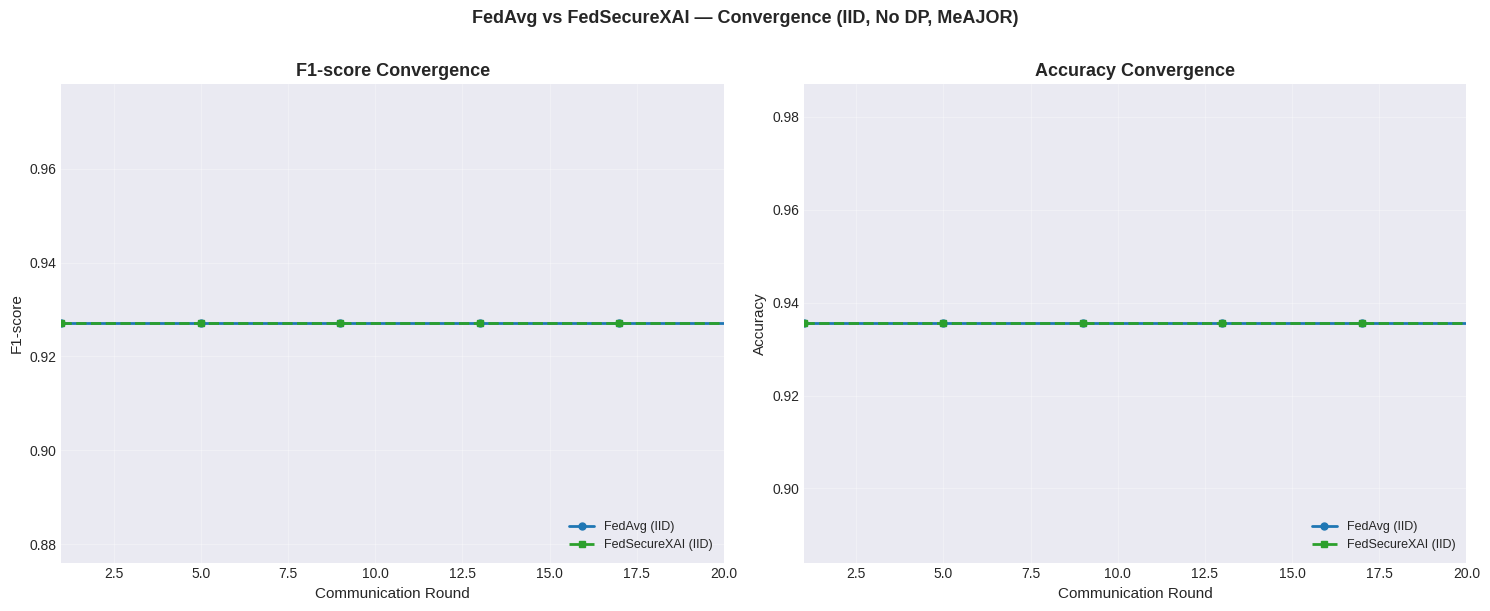

  ✅ Fig 3 saved → figures/fig3_convergence_fedavg_vs_fsx.png


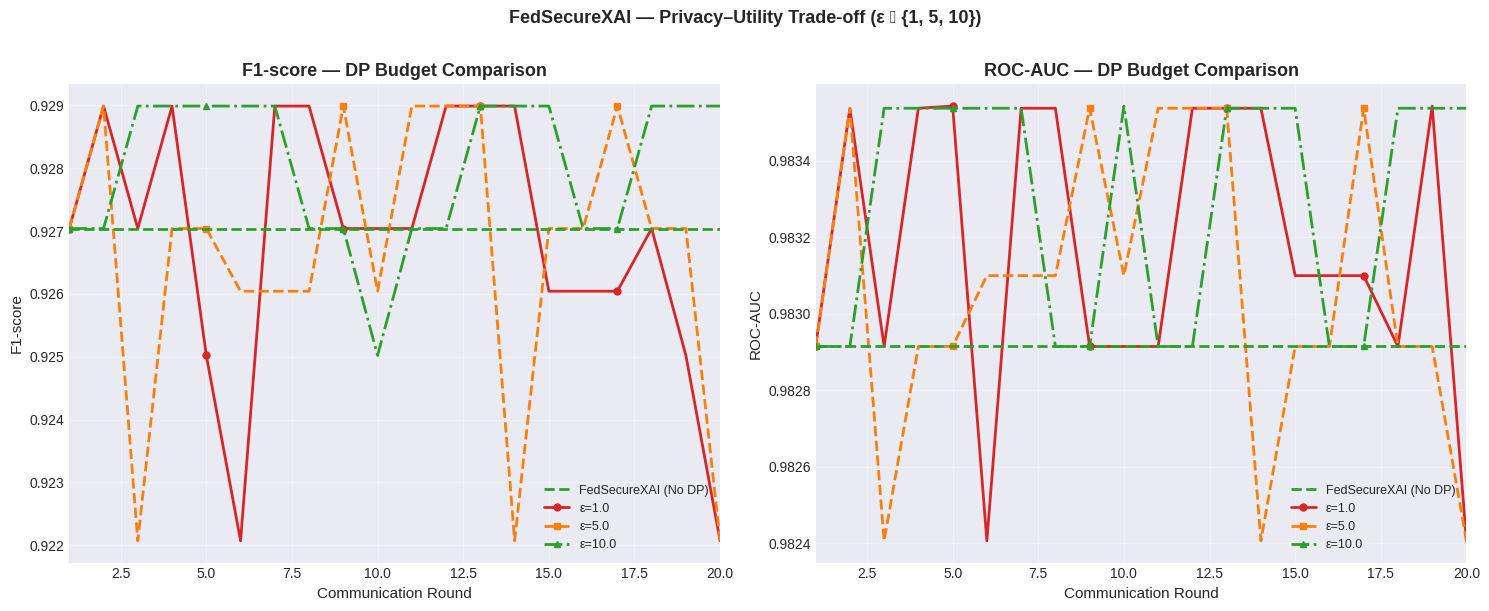

  ✅ Fig 4 saved → figures/fig4_privacy_utility.png


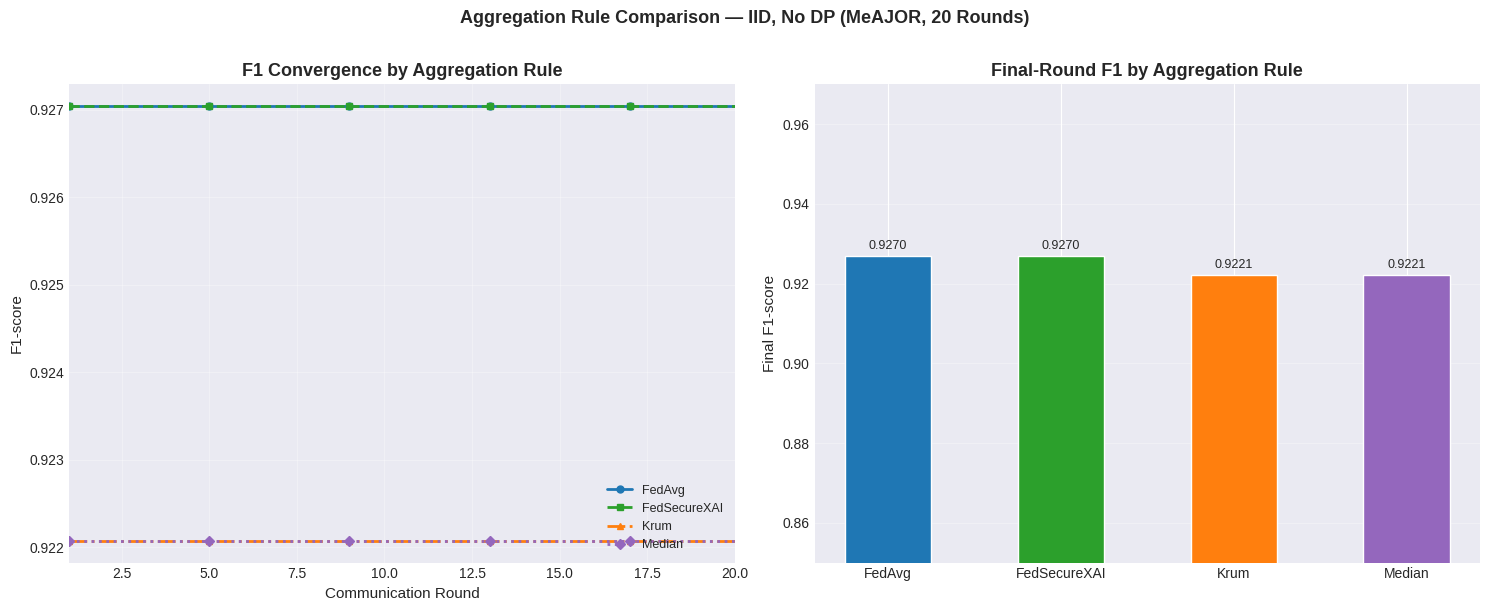

  ✅ Fig 5 saved → figures/fig5_aggregation_comparison.png


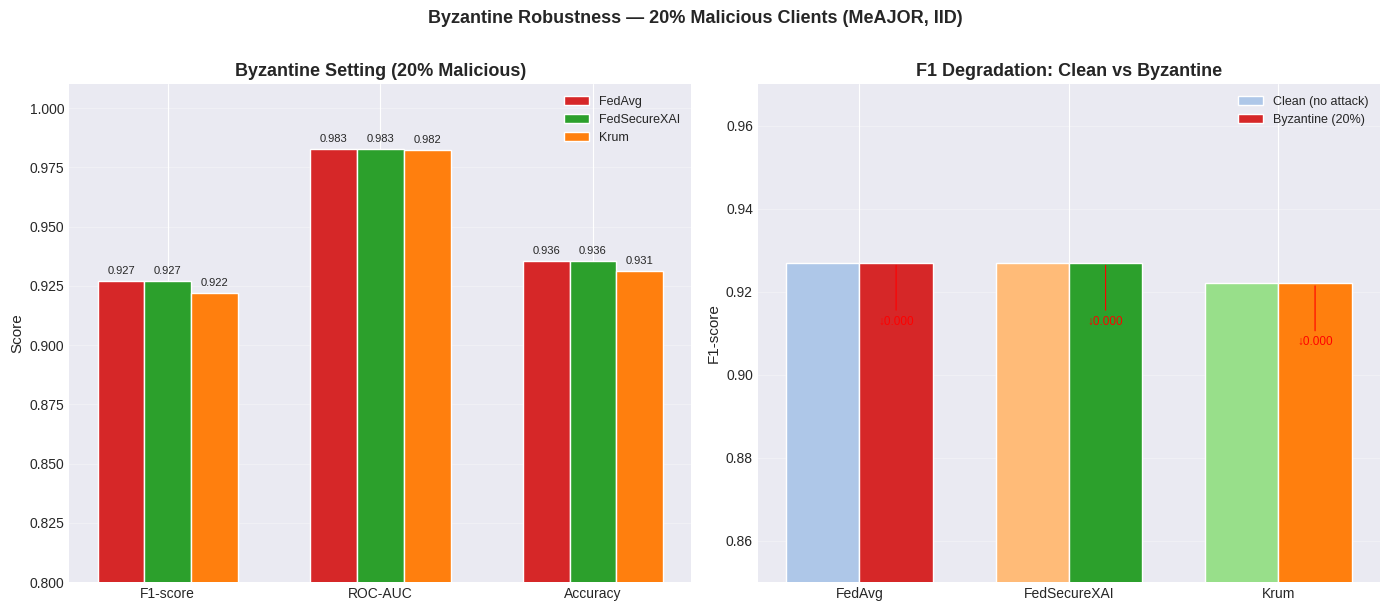

  ✅ Fig 6 saved → figures/fig6_byzantine_robustness.png


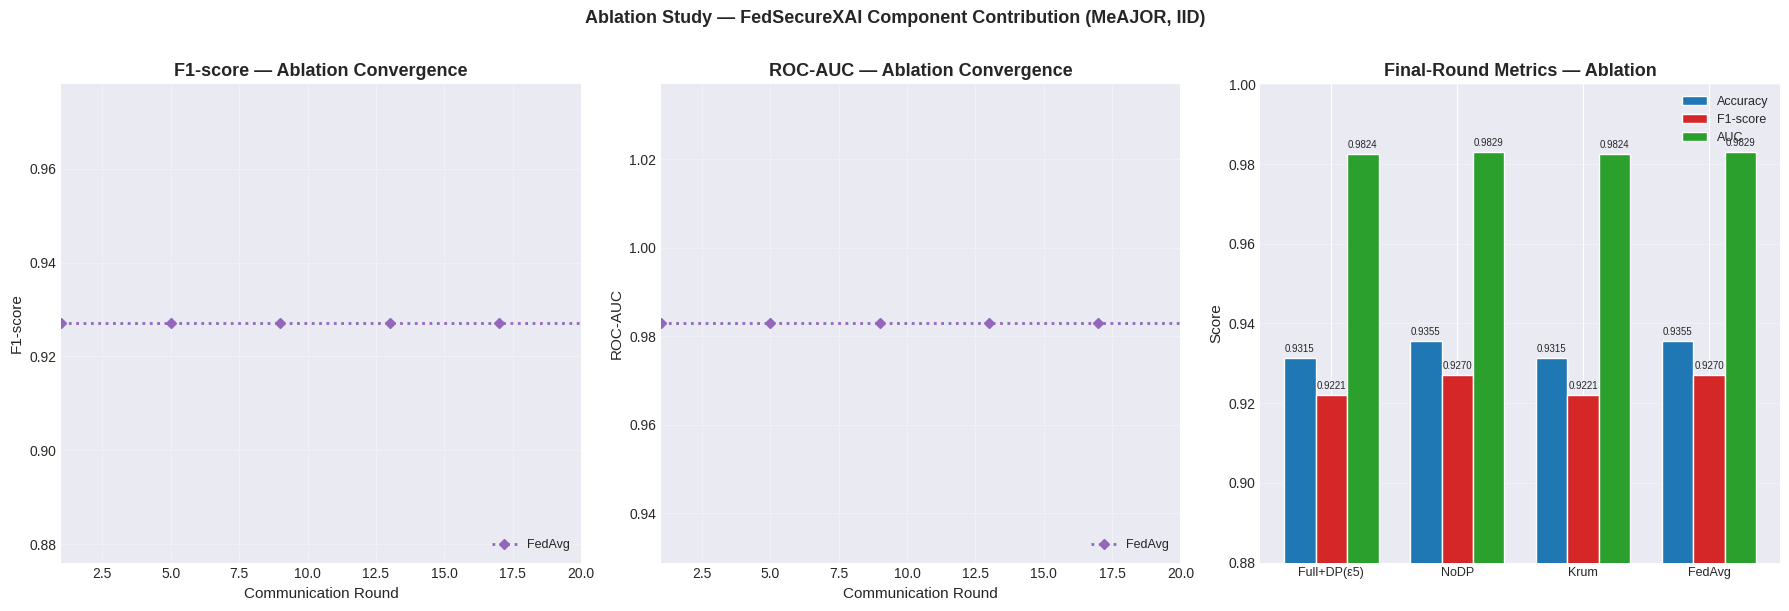

  ✅ Fig 7 saved → figures/fig7_ablation_study.png


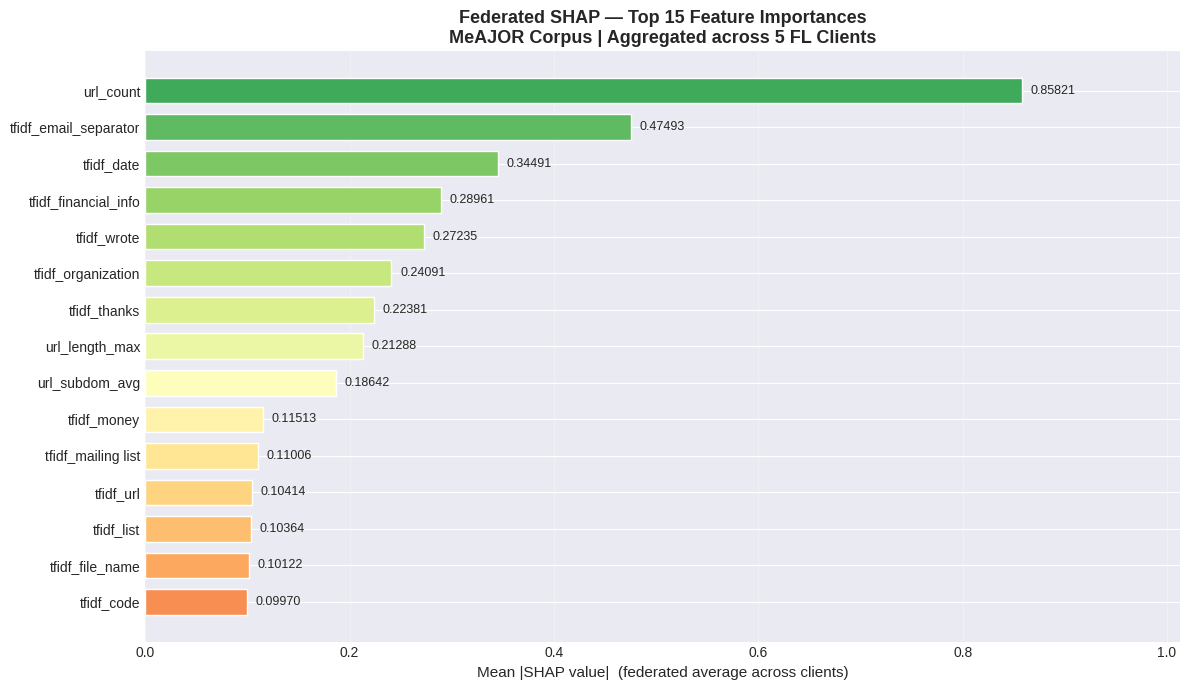

  ✅ Fig 8 saved → figures/fig8_federated_shap.png


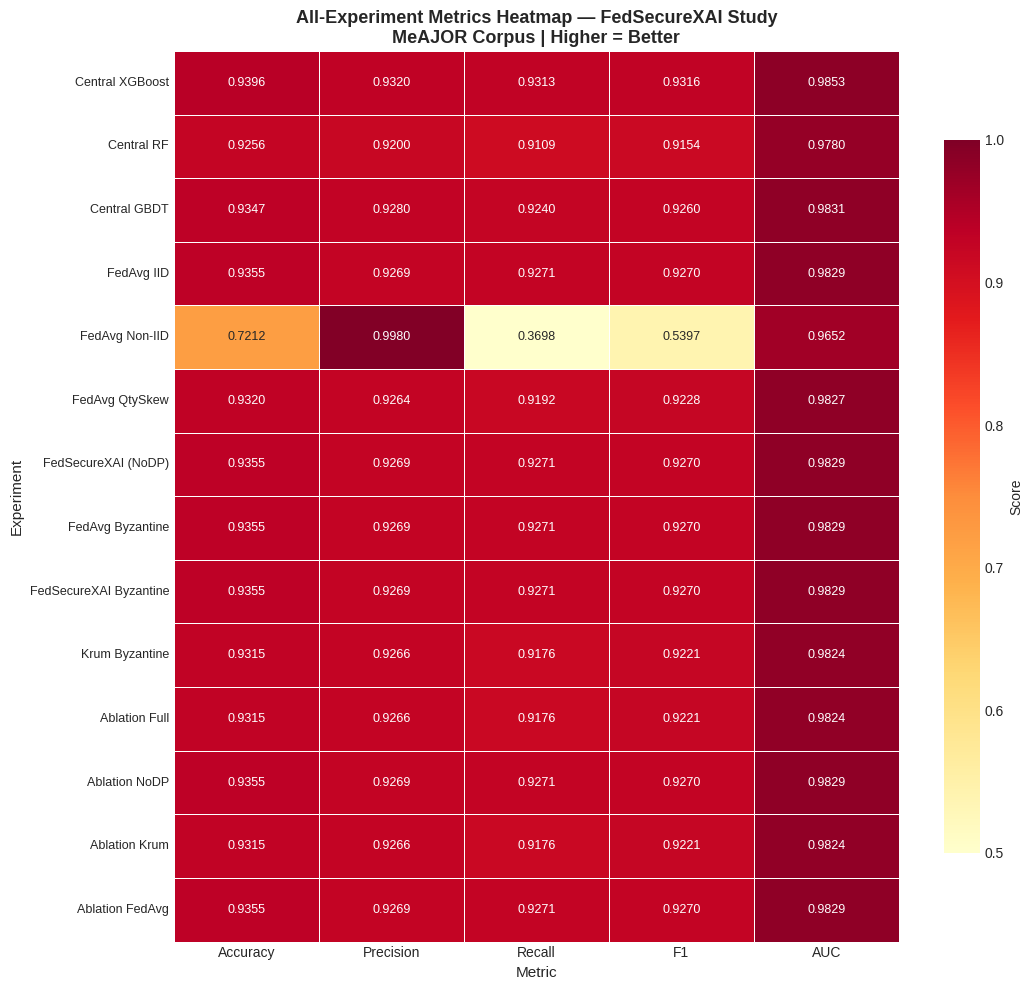

  ✅ Fig 9 saved → figures/fig9_metrics_heatmap.png

  CELL 10 COMPLETE — Figure Summary
  ✅ Fig 1  figures/fig1_partition_statistics.png                 Partition sample counts & phishing ratios
  ✅ Fig 2  figures/fig2_convergence_partition.png                FedAvg convergence: IID/Non-IID/QtySkew
  ✅ Fig 3  figures/fig3_convergence_fedavg_vs_fsx.png            FedAvg vs FedSecureXAI convergence
  ✅ Fig 4  figures/fig4_privacy_utility.png                      Privacy–utility trade-off (ε ∈ {1,5,10})
  ✅ Fig 5  figures/fig5_aggregation_comparison.png               Aggregation rule comparison
  ✅ Fig 6  figures/fig6_byzantine_robustness.png                 Byzantine robustness (20% malicious)
  ✅ Fig 7  figures/fig7_ablation_study.png                       Ablation study (convergence + bars)
  ✅ Fig 8  figures/fig8_federated_shap.png                       Federated SHAP feature importances
  ✅ Fig 9  figures/fig9_metrics_heatmap.png                      Full experiment metrics heatmap



In [6]:
# ============================================================
# CELL 10: Visualizations
# ============================================================
#
# Requires from previous cells:
#   Cell 3  → X_test, y_test, feature_names
#   Cell 4  → clients_iid, clients_non_iid, clients_qty_skew
#             NUM_CLIENTS
#   Cell 8  → all_results, fedavg_convergence,
#             fsx_nodp_convergence, dp_conv, agg_conv,
#             ablation_conv, ablation_results,
#             top_feat_names, top_feat_vals,
#             central_xgb_model
#
# Figures produced:
#   Fig 1  — Partition statistics (sample count + phishing ratio)
#   Fig 2  — Convergence: FedAvg IID vs Non-IID vs QtySkew
#   Fig 3  — Convergence: FedAvg vs FedSecureXAI (IID)
#   Fig 4  — Privacy–utility trade-off (ε ∈ {1,5,10})
#   Fig 5  — Aggregation rule comparison (F1 + AUC)
#   Fig 6  — Byzantine robustness bar chart
#   Fig 7  — Ablation study (convergence + bar)
#   Fig 8  — Federated SHAP feature importance
#   Fig 9  — Overall metrics heatmap (all experiments)
# ============================================================

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

# ------------------------------------------------------------------
# Shared style constants
# ------------------------------------------------------------------
COLORS = {
    "iid":          "#1f77b4",
    "noniid":       "#d62728",
    "qtyskew":      "#ff7f0e",
    "fedsecurexai": "#2ca02c",
    "fedavg":       "#1f77b4",
    "krum":         "#ff7f0e",
    "median":       "#9467bd",
    "central":      "#8c564b",
    "dp1":          "#d62728",
    "dp5":          "#ff7f0e",
    "dp10":         "#2ca02c",
    "byz_fedavg":   "#d62728",
    "byz_fsx":      "#2ca02c",
    "byz_krum":     "#ff7f0e",
}
LS  = ["-", "--", "-.", ":"]
MRK = ["o", "s", "^", "D"]

TITLE_FONT = {"fontsize": 13, "fontweight": "bold"}
AXIS_FONT  = {"fontsize": 11}
LEG_FONT   = 9
DPI        = 150
MEVERY     = 4     # marker every N rounds


# ==================================================================
# FIG 1 — Partition Statistics
# ==================================================================
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(15, 6))
fig1.suptitle(
    "MeAJOR Corpus — Federated Data Partitioning Statistics",
    **TITLE_FONT, y=1.01
)

client_ids = [f"C{i}" for i in range(NUM_CLIENTS)]
x_pos = np.arange(NUM_CLIENTS)
bar_w = 0.25

schemes = [
    ("IID",         clients_iid,     COLORS["iid"]),
    ("Non-IID",     clients_non_iid, COLORS["noniid"]),
    ("Qty-Skew",    clients_qty_skew,COLORS["qtyskew"]),
]

# ── Left: sample counts ──
for s_i, (lbl, cl, col) in enumerate(schemes):
    counts = [c["n_samples"] for c in cl]
    bars   = ax1a.bar(x_pos + s_i * bar_w, counts, bar_w,
                       label=lbl, color=col, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax1a.text(bar.get_x() + bar.get_width()/2, h + 30,
                  f"{h/1000:.1f}k", ha="center", va="bottom",
                  fontsize=8)

ax1a.set_xticks(x_pos + bar_w)
ax1a.set_xticklabels(client_ids)
ax1a.set_xlabel("Client ID", **AXIS_FONT)
ax1a.set_ylabel("Sample Count", **AXIS_FONT)
ax1a.set_title("Sample Count per Client", **TITLE_FONT)
ax1a.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax1a.legend(fontsize=LEG_FONT)
ax1a.grid(True, axis="y", alpha=0.3)

# ── Right: phishing ratio ──
global_ratio = np.mean([c["phish_ratio"] for c in clients_iid])
for s_i, (lbl, cl, col) in enumerate(schemes):
    ratios = [c["phish_ratio"] * 100 for c in cl]
    bars   = ax1b.bar(x_pos + s_i * bar_w, ratios, bar_w,
                       label=lbl, color=col, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax1b.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                  f"{h:.1f}%", ha="center", va="bottom", fontsize=7.5)

ax1b.axhline(global_ratio * 100, color="black", linestyle="--",
             linewidth=1.5, label=f"Global ({global_ratio*100:.1f}%)")
ax1b.set_xticks(x_pos + bar_w)
ax1b.set_xticklabels(client_ids)
ax1b.set_xlabel("Client ID", **AXIS_FONT)
ax1b.set_ylabel("Phishing Ratio (%)", **AXIS_FONT)
ax1b.set_title("Phishing Ratio per Client", **TITLE_FONT)
ax1b.legend(fontsize=LEG_FONT)
ax1b.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
fig1.savefig("figures/fig1_partition_statistics.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 1 saved → figures/fig1_partition_statistics.png")


# ==================================================================
# FIG 2 — Convergence: FedAvg across partition schemes
# ==================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))
fig2.suptitle(
    "FedAvg Convergence Across Partition Schemes (MeAJOR, 20 Rounds)",
    **TITLE_FONT, y=1.01
)

conv_schemes = [
    ("IID",      "FedAvg_IID",     COLORS["iid"],     LS[0], MRK[0]),
    ("Non-IID",  "FedAvg_NonIID",  COLORS["noniid"],  LS[1], MRK[1]),
    ("Qty-Skew", "FedAvg_QtySkew", COLORS["qtyskew"], LS[2], MRK[2]),
]

for ax_i, (metric, ylabel) in enumerate([
    ("test_f1",  "F1-score"),
    ("test_auc", "ROC-AUC"),
]):
    ax = axes2[ax_i]
    for lbl, key, col, ls, mk in conv_schemes:
        conv = fedavg_convergence.get(key, {})
        if not conv:
            continue
        ax.plot(conv["round"], conv[metric],
                color=col, linestyle=ls, marker=mk,
                markersize=5, markevery=MEVERY,
                linewidth=2.0, label=lbl)
    ax.set_xlabel("Communication Round", **AXIS_FONT)
    ax.set_ylabel(ylabel, **AXIS_FONT)
    ax.set_title(f"{ylabel} — Partition Comparison", **TITLE_FONT)
    ax.legend(fontsize=LEG_FONT, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 20)

plt.tight_layout()
fig2.savefig("figures/fig2_convergence_partition.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 2 saved → figures/fig2_convergence_partition.png")


# ==================================================================
# FIG 3 — Convergence: FedAvg vs FedSecureXAI (IID)
# ==================================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(15, 6))
fig3.suptitle(
    "FedAvg vs FedSecureXAI — Convergence (IID, No DP, MeAJOR)",
    **TITLE_FONT, y=1.01
)

# Pull the fsx_nodp_convergence variable (Cell 8.3 output)
fsx_key = "fsx_nodp_convergence"

for ax_i, (metric, ylabel) in enumerate([
    ("test_f1",       "F1-score"),
    ("test_accuracy", "Accuracy"),
]):
    ax = axes3[ax_i]
    iid_conv = fedavg_convergence.get("FedAvg_IID", {})
    if iid_conv:
        ax.plot(iid_conv["round"], iid_conv[metric],
                color=COLORS["fedavg"], linestyle=LS[0],
                marker=MRK[0], markersize=5, markevery=MEVERY,
                linewidth=2.0, label="FedAvg (IID)")

    fsx_data = fsx_nodp_convergence   # Cell 8.3 variable
    ax.plot(fsx_data["round"], fsx_data[metric],
            color=COLORS["fedsecurexai"], linestyle=LS[1],
            marker=MRK[1], markersize=5, markevery=MEVERY,
            linewidth=2.0, label="FedSecureXAI (IID)")

    ax.set_xlabel("Communication Round", **AXIS_FONT)
    ax.set_ylabel(ylabel, **AXIS_FONT)
    ax.set_title(f"{ylabel} Convergence", **TITLE_FONT)
    ax.legend(fontsize=LEG_FONT, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 20)

plt.tight_layout()
fig3.savefig("figures/fig3_convergence_fedavg_vs_fsx.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 3 saved → figures/fig3_convergence_fedavg_vs_fsx.png")


# ==================================================================
# FIG 4 — Privacy–Utility Trade-off  (ε ∈ {1, 5, 10})
# ==================================================================
fig4, axes4 = plt.subplots(1, 2, figsize=(15, 6))
fig4.suptitle(
    "FedSecureXAI — Privacy–Utility Trade-off (ε ∈ {1, 5, 10})",
    **TITLE_FONT, y=1.01
)

dp_settings = [
    (1.0,  COLORS["dp1"],  LS[0], MRK[0]),
    (5.0,  COLORS["dp5"],  LS[1], MRK[1]),
    (10.0, COLORS["dp10"], LS[2], MRK[2]),
]

for ax_i, (metric, ylabel) in enumerate([
    ("test_f1",  "F1-score"),
    ("test_auc", "ROC-AUC"),
]):
    ax = axes4[ax_i]
    # FedSecureXAI No DP as reference
    ax.plot(fsx_nodp_convergence["round"],
            fsx_nodp_convergence[metric],
            color=COLORS["fedsecurexai"], linestyle="--",
            linewidth=2.0, label="FedSecureXAI (No DP)",
            zorder=10)
    for eps, col, ls, mk in dp_settings:
        conv = dp_conv.get(eps, {})
        if not conv:
            continue
        ax.plot(conv["round"], conv[metric],
                color=col, linestyle=ls, marker=mk,
                markersize=5, markevery=MEVERY,
                linewidth=2.0, label=f"ε={eps}")
    ax.set_xlabel("Communication Round", **AXIS_FONT)
    ax.set_ylabel(ylabel, **AXIS_FONT)
    ax.set_title(f"{ylabel} — DP Budget Comparison", **TITLE_FONT)
    ax.legend(fontsize=LEG_FONT, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 20)

# Right panel: static bar for final-round metrics
eps_labels = ["No DP", "ε=1", "ε=5", "ε=10"]
final_f1s  = [
    fsx_nodp_convergence["test_f1"][-1],
    dp_conv.get(1.0,  {}).get("test_f1", [0])[-1],
    dp_conv.get(5.0,  {}).get("test_f1", [0])[-1],
    dp_conv.get(10.0, {}).get("test_f1", [0])[-1],
]
final_aucs = [
    fsx_nodp_convergence["test_auc"][-1],
    dp_conv.get(1.0,  {}).get("test_auc", [0])[-1],
    dp_conv.get(5.0,  {}).get("test_auc", [0])[-1],
    dp_conv.get(10.0, {}).get("test_auc", [0])[-1],
]

plt.tight_layout()
fig4.savefig("figures/fig4_privacy_utility.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 4 saved → figures/fig4_privacy_utility.png")


# ==================================================================
# FIG 5 — Aggregation Rule Comparison
# ==================================================================
fig5, axes5 = plt.subplots(1, 2, figsize=(15, 6))
fig5.suptitle(
    "Aggregation Rule Comparison — IID, No DP (MeAJOR, 20 Rounds)",
    **TITLE_FONT, y=1.01
)

agg_styles = [
    ("FedAvg",       "fedavg",       COLORS["fedavg"],       LS[0], MRK[0]),
    ("FedSecureXAI", "fedsecurexai", COLORS["fedsecurexai"], LS[1], MRK[1]),
    ("Krum",         "krum",         COLORS["krum"],         LS[2], MRK[2]),
    ("Median",       "median",       COLORS["median"],       LS[3], MRK[3]),
]

for ax_i, (metric, ylabel) in enumerate([
    ("test_f1", "F1-score"),
    ("test_f1", "F1-score (bar, final round)"),
]):
    ax = axes5[ax_i]
    if ax_i == 0:
        for lbl, key, col, ls, mk in agg_styles:
            conv = agg_conv.get(key, {})
            if not conv:
                continue
            ax.plot(conv["round"], conv["test_f1"],
                    color=col, linestyle=ls, marker=mk,
                    markersize=5, markevery=MEVERY,
                    linewidth=2.0, label=lbl)
        ax.set_xlabel("Communication Round", **AXIS_FONT)
        ax.set_ylabel("F1-score", **AXIS_FONT)
        ax.set_title("F1 Convergence by Aggregation Rule", **TITLE_FONT)
        ax.legend(fontsize=LEG_FONT, loc="lower right")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(1, 20)
    else:
        xlbls = [s[0] for s in agg_styles]
        f1s_  = [agg_conv.get(s[1],{"test_f1":[0]})["test_f1"][-1] for s in agg_styles]
        cols_ = [s[2] for s in agg_styles]
        b = ax.bar(xlbls, f1s_, color=cols_, edgecolor="white", width=0.5)
        for bar in b:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                    f"{h:.4f}", ha="center", va="bottom", fontsize=9)
        ax.set_ylabel("Final F1-score", **AXIS_FONT)
        ax.set_title("Final-Round F1 by Aggregation Rule", **TITLE_FONT)
        ax.set_ylim(0.85, 0.97)
        ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
fig5.savefig("figures/fig5_aggregation_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 5 saved → figures/fig5_aggregation_comparison.png")


# ==================================================================
# FIG 6 — Byzantine Robustness
# ==================================================================
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(14, 6))
fig6.suptitle(
    "Byzantine Robustness — 20% Malicious Clients (MeAJOR, IID)",
    **TITLE_FONT, y=1.01
)

byz_exps = [
    ("FedAvg",       "FedAvg_Byzantine",       COLORS["byz_fedavg"]),
    ("FedSecureXAI", "FedSecureXAI_Byzantine",  COLORS["byz_fsx"]),
    ("Krum",         "Krum_Byzantine",           COLORS["byz_krum"]),
]
clean_exps = [
    ("FedAvg (clean)",       "FedAvg_IID",          COLORS["byz_fedavg"]),
    ("FedSecureXAI (clean)", "FedSecureXAI_IID_NoDP",   COLORS["byz_fsx"]), # Corrected key
]

metric_pairs = [
    ("F1-score",    "f1"),
    ("ROC-AUC",     "auc"),
    ("Accuracy",    "accuracy"),
]

xlbls = [e[0] for e in byz_exps]
for m_i, (m_lbl, m_key) in enumerate(metric_pairs):
    vals_byz   = [all_results.get(e[1], {}).get(m_key, 0) for e in byz_exps]
    cols       = [e[2] for e in byz_exps]

ax6a_data = {
    "Metric":  [],
    "Method":  [],
    "Score":   [],
}
for m_lbl, m_key in metric_pairs:
    for lbl, key, _ in byz_exps:
        ax6a_data["Metric"].append(m_lbl)
        ax6a_data["Method"].append(lbl)
        ax6a_data["Score"].append(all_results.get(key, {}).get(m_key, 0))

df_byz = pd.DataFrame(ax6a_data)
x_byz  = np.arange(len(metric_pairs))
w_byz  = 0.22

for b_i, (lbl, key, col) in enumerate(byz_exps):
    vals = [all_results.get(key, {}).get(m[1], 0) for m in metric_pairs]
    bars = ax6a.bar(x_byz + b_i * w_byz, vals, w_byz,
                     label=lbl, color=col, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax6a.text(bar.get_x() + w_byz/2, h + 0.002,
                  f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax6a.set_xticks(x_byz + w_byz)
ax6a.set_xticklabels([m[0] for m in metric_pairs])
ax6a.set_ylabel("Score", **AXIS_FONT)
ax6a.set_title("Byzantine Setting (20% Malicious)", **TITLE_FONT)
ax6a.legend(fontsize=LEG_FONT)
ax6a.set_ylim(0.80, 1.01)
ax6a.grid(True, axis="y", alpha=0.3)

# Right: clean vs Byzantine F1 comparison
clean_f1  = [all_results.get("FedAvg_IID",{}).get("f1",0),
              all_results.get("FedSecureXAI_IID_NoDP",{}).get("f1",0), # Corrected key
              all_results.get("AggComp_KRUM",     # fallback
              all_results.get("Krum_Byzantine",{})).get("f1",0)]
byz_f1    = [all_results.get("FedAvg_Byzantine",{}).get("f1",0),
              all_results.get("FedSecureXAI_Byzantine",{}).get("f1",0),
              all_results.get("Krum_Byzantine",{}).get("f1",0)]

x_cb  = np.arange(3)
w_cb  = 0.35
xlbls_cb = ["FedAvg", "FedSecureXAI", "Krum"]
ax6b.bar(x_cb - w_cb/2, clean_f1, w_cb, label="Clean (no attack)",
          color=["#aec7e8","#ffbb78","#98df8a"], edgecolor="white")
ax6b.bar(x_cb + w_cb/2, byz_f1,   w_cb, label="Byzantine (20%)",
          color=[COLORS["byz_fedavg"],COLORS["byz_fsx"],COLORS["byz_krum"]],
          edgecolor="white")
for i, (c, b) in enumerate(zip(clean_f1, byz_f1)):
    drop = c - b
    ax6b.annotate(f"↓{drop:.3f}", xy=(i + w_cb/2, b),
                   xytext=(i + w_cb/2, b - 0.015),
                   ha="center", fontsize=8.5, color="red",
                   arrowprops=dict(arrowstyle="-", color="red", lw=0.8))
ax6b.set_xticks(x_cb)
ax6b.set_xticklabels(xlbls_cb)
ax6b.set_ylabel("F1-score", **AXIS_FONT)
ax6b.set_title("F1 Degradation: Clean vs Byzantine", **TITLE_FONT)
ax6b.legend(fontsize=LEG_FONT)
ax6b.set_ylim(0.85, 0.97)
ax6b.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
fig6.savefig("figures/fig6_byzantine_robustness.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 6 saved → figures/fig6_byzantine_robustness.png")


# ==================================================================
# FIG 7 — Ablation Study
# ==================================================================
# Define ablation_results based on all_results
ablation_results = {
    "Ablation_Full": {
        "final_f1": all_results.get("Ablation_FedSecureXAI_Full", {}).get("f1", 0),
        "final_auc": all_results.get("Ablation_FedSecureXAI_Full", {}).get("auc", 0),
        "final_acc": all_results.get("Ablation_FedSecureXAI_Full", {}).get("accuracy", 0)
    },
    "Ablation_NoDP": {
        "final_f1": all_results.get("Ablation_FedSecureXAI_NoDP", {}).get("f1", 0),
        "final_auc": all_results.get("Ablation_FedSecureXAI_NoDP", {}).get("auc", 0),
        "final_acc": all_results.get("Ablation_FedSecureXAI_NoDP", {}).get("accuracy", 0)
    },
    "Ablation_Krum_NoDP": {
        "final_f1": all_results.get("AggComp_KRUM", {}).get("f1", 0), # Using Krum from aggregation comparison
        "final_auc": all_results.get("AggComp_KRUM", {}).get("auc", 0),
        "final_acc": all_results.get("AggComp_KRUM", {}).get("accuracy", 0)
    },
    "Ablation_FedAvg_Baseline": {
        "final_f1": all_results.get("Ablation_FedAvg_Baseline", {}).get("f1", 0),
        "final_auc": all_results.get("Ablation_FedAvg_Baseline", {}).get("auc", 0),
        "final_acc": all_results.get("Ablation_FedAvg_Baseline", {}).get("accuracy", 0)
    }
}

abl_order = [
    ("Ablation_Full",            "Full+DP(ε5)", COLORS["fedsecurexai"], LS[0], MRK[0]),
    ("Ablation_NoDP",            "NoDP",         COLORS["iid"],         LS[1], MRK[1]),
    ("Ablation_Krum_NoDP",       "Krum",         COLORS["krum"],        LS[2], MRK[2]),
    ("Ablation_FedAvg_Baseline", "FedAvg",       COLORS["median"],      LS[3], MRK[3]),
]

fig7, axes7 = plt.subplots(1, 3, figsize=(18, 6))
fig7.suptitle(
    "Ablation Study — FedSecureXAI Component Contribution (MeAJOR, IID)",
    **TITLE_FONT, y=1.01
)

for ax_i, (metric, ylabel) in enumerate([
    ("test_f1",  "F1-score"),
    ("test_auc", "ROC-AUC"),
]):
    ax = axes7[ax_i]
    for cfg_name, lbl, col, ls, mk in abl_order:
        conv = ablation_conv.get(cfg_name, {})
        if not conv:
            continue
        ax.plot(conv["round"], conv[metric],
                color=col, linestyle=ls, marker=mk,
                markersize=5, markevery=MEVERY,
                linewidth=2.0, label=lbl)
    ax.set_xlabel("Communication Round", **AXIS_FONT)
    ax.set_ylabel(ylabel, **AXIS_FONT)
    ax.set_title(f"{ylabel} — Ablation Convergence", **TITLE_FONT)
    ax.legend(fontsize=LEG_FONT, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 20)

# Third panel: grouped bar — final F1 / AUC / Accuracy
ax7c    = axes7[2]
abl_lbl = [a[1] for a in abl_order]
abl_f1  = [ablation_results.get(a[0],{}).get("final_f1",  0) for a in abl_order]
abl_auc = [ablation_results.get(a[0],{}).get("final_auc", 0) for a in abl_order]
abl_acc = [ablation_results.get(a[0],{}).get("final_acc", 0) for a in abl_order]

x_abl = np.arange(len(abl_order))
w_abl = 0.25

b7_1 = ax7c.bar(x_abl - w_abl, abl_acc, w_abl, label="Accuracy", color="#1f77b4", edgecolor="white")
b7_2 = ax7c.bar(x_abl,         abl_f1,  w_abl, label="F1-score",  color="#d62728", edgecolor="white")
b7_3 = ax7c.bar(x_abl + w_abl, abl_auc, w_abl, label="AUC",       color="#2ca02c", edgecolor="white")

for bars in [b7_1, b7_2, b7_3]:
    for bar in bars:
        h = bar.get_height()
        ax7c.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                  f"{h:.4f}", ha="center", va="bottom",
                  fontsize=7, rotation=0)

ax7c.set_xticks(x_abl)
ax7c.set_xticklabels(abl_lbl, fontsize=9)
ax7c.set_ylabel("Score", **AXIS_FONT)
ax7c.set_title("Final-Round Metrics — Ablation", **TITLE_FONT)
ax7c.legend(fontsize=LEG_FONT)
ax7c.set_ylim(0.88, 1.00)
ax7c.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
fig7.savefig("figures/fig7_ablation_study.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 7 saved → figures/fig7_ablation_study.png")


# ==================================================================
# FIG 8 — Federated SHAP Feature Importance
# ==================================================================
fig8, ax8 = plt.subplots(figsize=(12, 7))

sorted_idx  = np.argsort(top_feat_vals)      # ascending for barh
sorted_vals = top_feat_vals[sorted_idx]
sorted_nms  = [top_feat_names[i] for i in sorted_idx]
colors_shap = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(sorted_vals)))

bars8 = ax8.barh(range(len(sorted_vals)), sorted_vals,
                  color=colors_shap, edgecolor="white", height=0.7)
for i, (bar, val) in enumerate(zip(bars8, sorted_vals)):
    ax8.text(val + sorted_vals.max() * 0.01, i,
             f"{val:.5f}", va="center", ha="left", fontsize=9)

ax8.set_yticks(range(len(sorted_nms)))
ax8.set_yticklabels(sorted_nms, fontsize=10)
ax8.set_xlabel("Mean |SHAP value|  (federated average across clients)",
               **AXIS_FONT)
ax8.set_title(
    f"Federated SHAP — Top {len(top_feat_names)} Feature Importances\n"
    "MeAJOR Corpus | Aggregated across 5 FL Clients",
    **TITLE_FONT
)
ax8.grid(True, axis="x", alpha=0.3)
ax8.set_xlim(0, sorted_vals.max() * 1.18)
plt.tight_layout()
fig8.savefig("figures/fig8_federated_shap.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 8 saved → figures/fig8_federated_shap.png")


# ==================================================================
# FIG 9 — Overall Metrics Heatmap (all experiments)
# ==================================================================
exp_order = [
    ("Central XGBoost",         "Central_XGBoost"),
    ("Central RF",              "Central_RandomForest"),
    ("Central GBDT",            "Central_GradientBoosting"),
    ("FedAvg IID",              "FedAvg_IID"),
    ("FedAvg Non-IID",          "FedAvg_NonIID"),
    ("FedAvg QtySkew",          "FedAvg_QtySkew"),
    ("FedSecureXAI (NoDP)",     "FedSecureXAI_IID_NoDP"),
    ("FedSecureXAI DP ε=1",     "FedSecureXAI_DP_eps1"),
    ("FedSecureXAI DP ε=5",     "FedSecureXAI_DP_eps5"),
    ("FedSecureXAI DP ε=10",    "FedSecureXAI_DP_eps10"),
    ("FedAvg Byzantine",        "FedAvg_Byzantine"),
    ("FedSecureXAI Byzantine",  "FedSecureXAI_Byzantine"),
    ("Krum Byzantine",          "Krum_Byzantine"),
    ("Ablation Full",           "Ablation_FedSecureXAI_Full"),
    ("Ablation NoDP",           "Ablation_FedSecureXAI_NoDP"),
    ("Ablation Krum",           "AggComp_KRUM"), # Mapped to AggComp_KRUM from aggregation comparison
    ("Ablation FedAvg",         "Ablation_FedAvg_Baseline"),
]

metrics_cols = ["accuracy", "precision", "recall", "f1", "auc"]
heat_rows    = []
row_labels   = []

for display_name, key in exp_order:
    m = all_results.get(key)
    if m is None:
        continue
    row_labels.append(display_name)
    heat_rows.append([m.get(c, 0.0) for c in metrics_cols])

heat_df = pd.DataFrame(heat_rows,
                        index=row_labels,
                        columns=["Accuracy","Precision","Recall","F1","AUC"])

fig9, ax9 = plt.subplots(figsize=(11, 10))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    vmin=0.50,
    vmax=1.00,
    ax=ax9,
    cbar_kws={"label": "Score", "shrink": 0.8},
    annot_kws={"size": 9},
)
ax9.set_title(
    "All-Experiment Metrics Heatmap — FedSecureXAI Study\n"
    "MeAJOR Corpus | Higher = Better",
    **TITLE_FONT
)
ax9.set_xlabel("Metric", **AXIS_FONT)
ax9.set_ylabel("Experiment", **AXIS_FONT)
ax9.set_xticklabels(ax9.get_xticklabels(), fontsize=10)
ax9.set_yticklabels(ax9.get_yticklabels(), fontsize=9)
plt.tight_layout()
fig9.savefig("figures/fig9_metrics_heatmap.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("  ✅ Fig 9 saved → figures/fig9_metrics_heatmap.png")


# ==================================================================
# 10.  Summary + CSV export
# ==================================================================
print("\n" + "=" * 60)
print("  CELL 10 COMPLETE — Figure Summary")
print("=" * 60)
saved_figs = [
    ("Fig 1", "fig1_partition_statistics.png",      "Partition sample counts & phishing ratios"),
    ("Fig 2", "fig2_convergence_partition.png",      "FedAvg convergence: IID/Non-IID/QtySkew"),
    ("Fig 3", "fig3_convergence_fedavg_vs_fsx.png",  "FedAvg vs FedSecureXAI convergence"),
    ("Fig 4", "fig4_privacy_utility.png",            "Privacy–utility trade-off (ε ∈ {1,5,10})"),
    ("Fig 5", "fig5_aggregation_comparison.png",     "Aggregation rule comparison"),
    ("Fig 6", "fig6_byzantine_robustness.png",       "Byzantine robustness (20% malicious)"),
    ("Fig 7", "fig7_ablation_study.png",             "Ablation study (convergence + bars)"),
    ("Fig 8", "fig8_federated_shap.png",             "Federated SHAP feature importances"),
    ("Fig 9", "fig9_metrics_heatmap.png",            "Full experiment metrics heatmap"),
]
for fig_id, fname, desc in saved_figs:
    status = "✅" if os.path.exists(f"figures/{fname}") else "⚠️ "
    print(f"  {status} {fig_id:<6} figures/{fname:<45} {desc}")

# Export heatmap data to CSV
heat_df.to_csv("figures/all_experiment_metrics.csv")
print("\n  ✅ figures/all_experiment_metrics.csv saved")


Displaying: fig1_partition_statistics.png


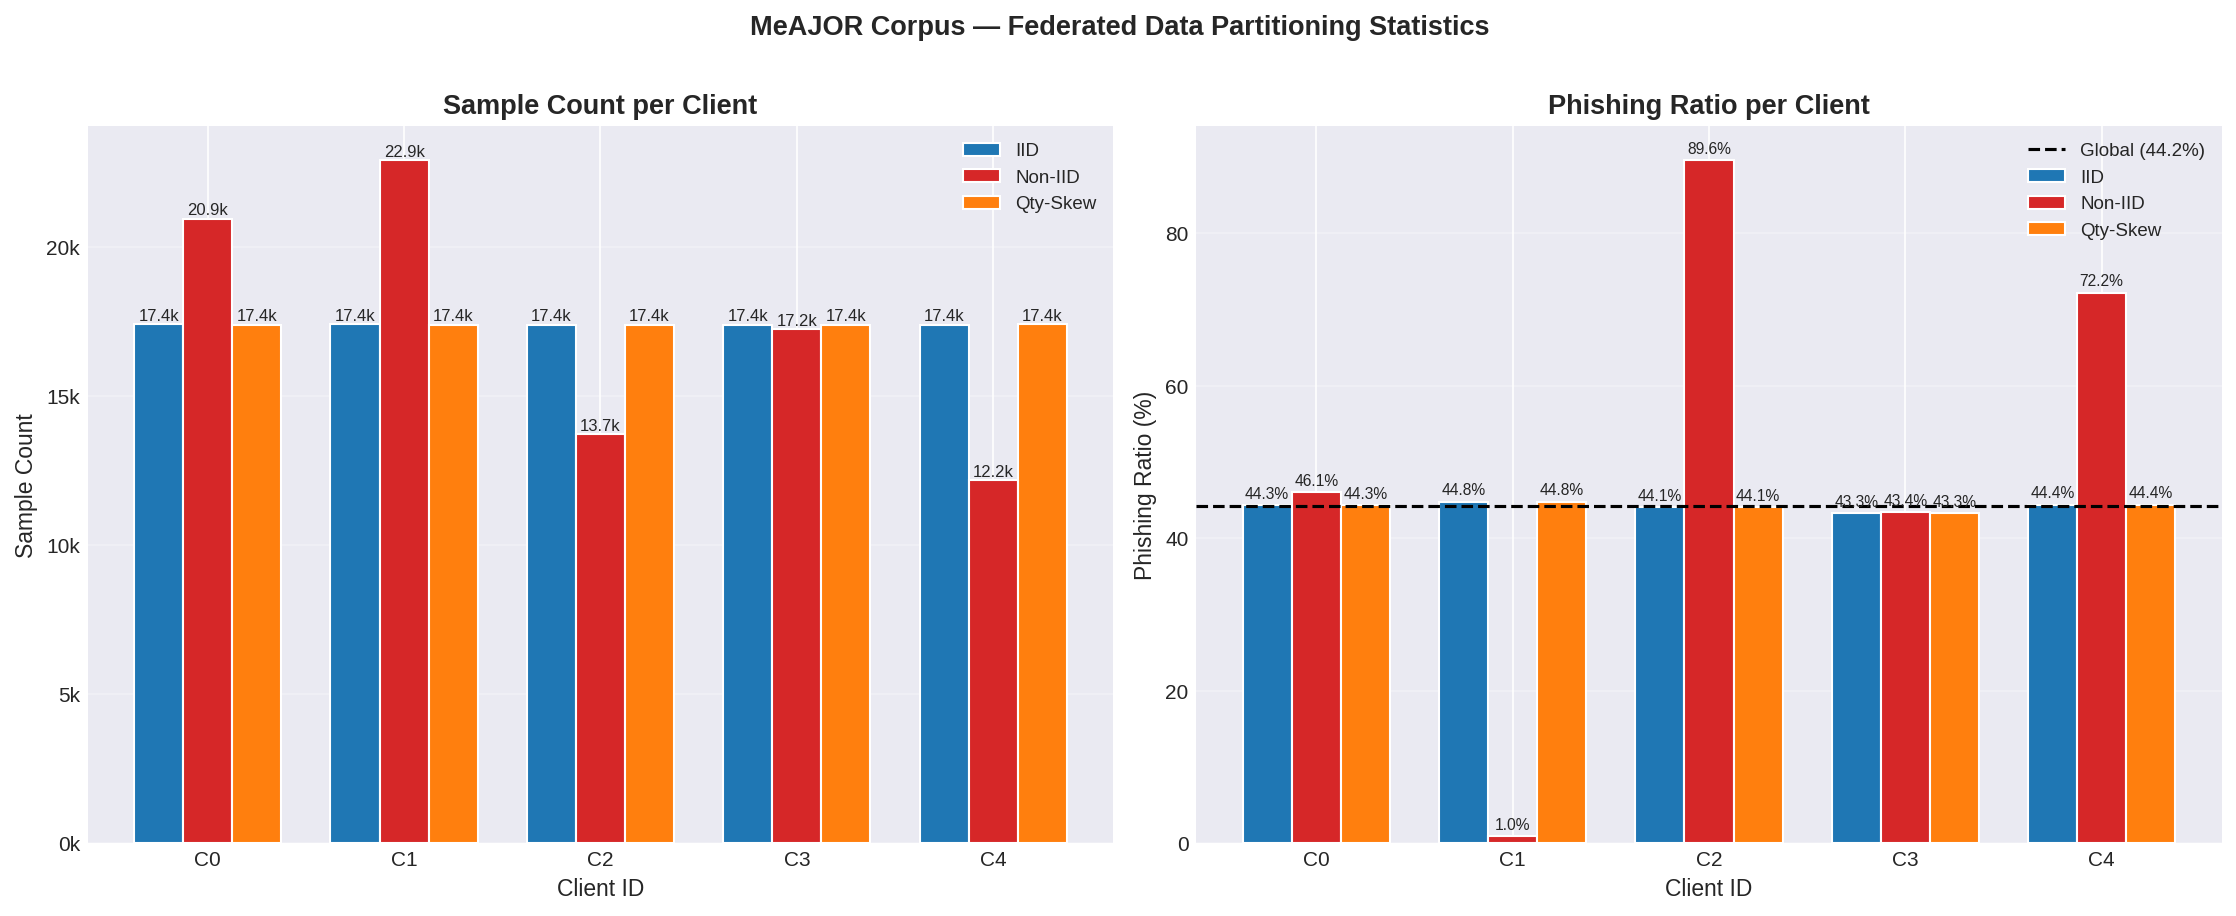


Displaying: fig2_convergence_partition.png


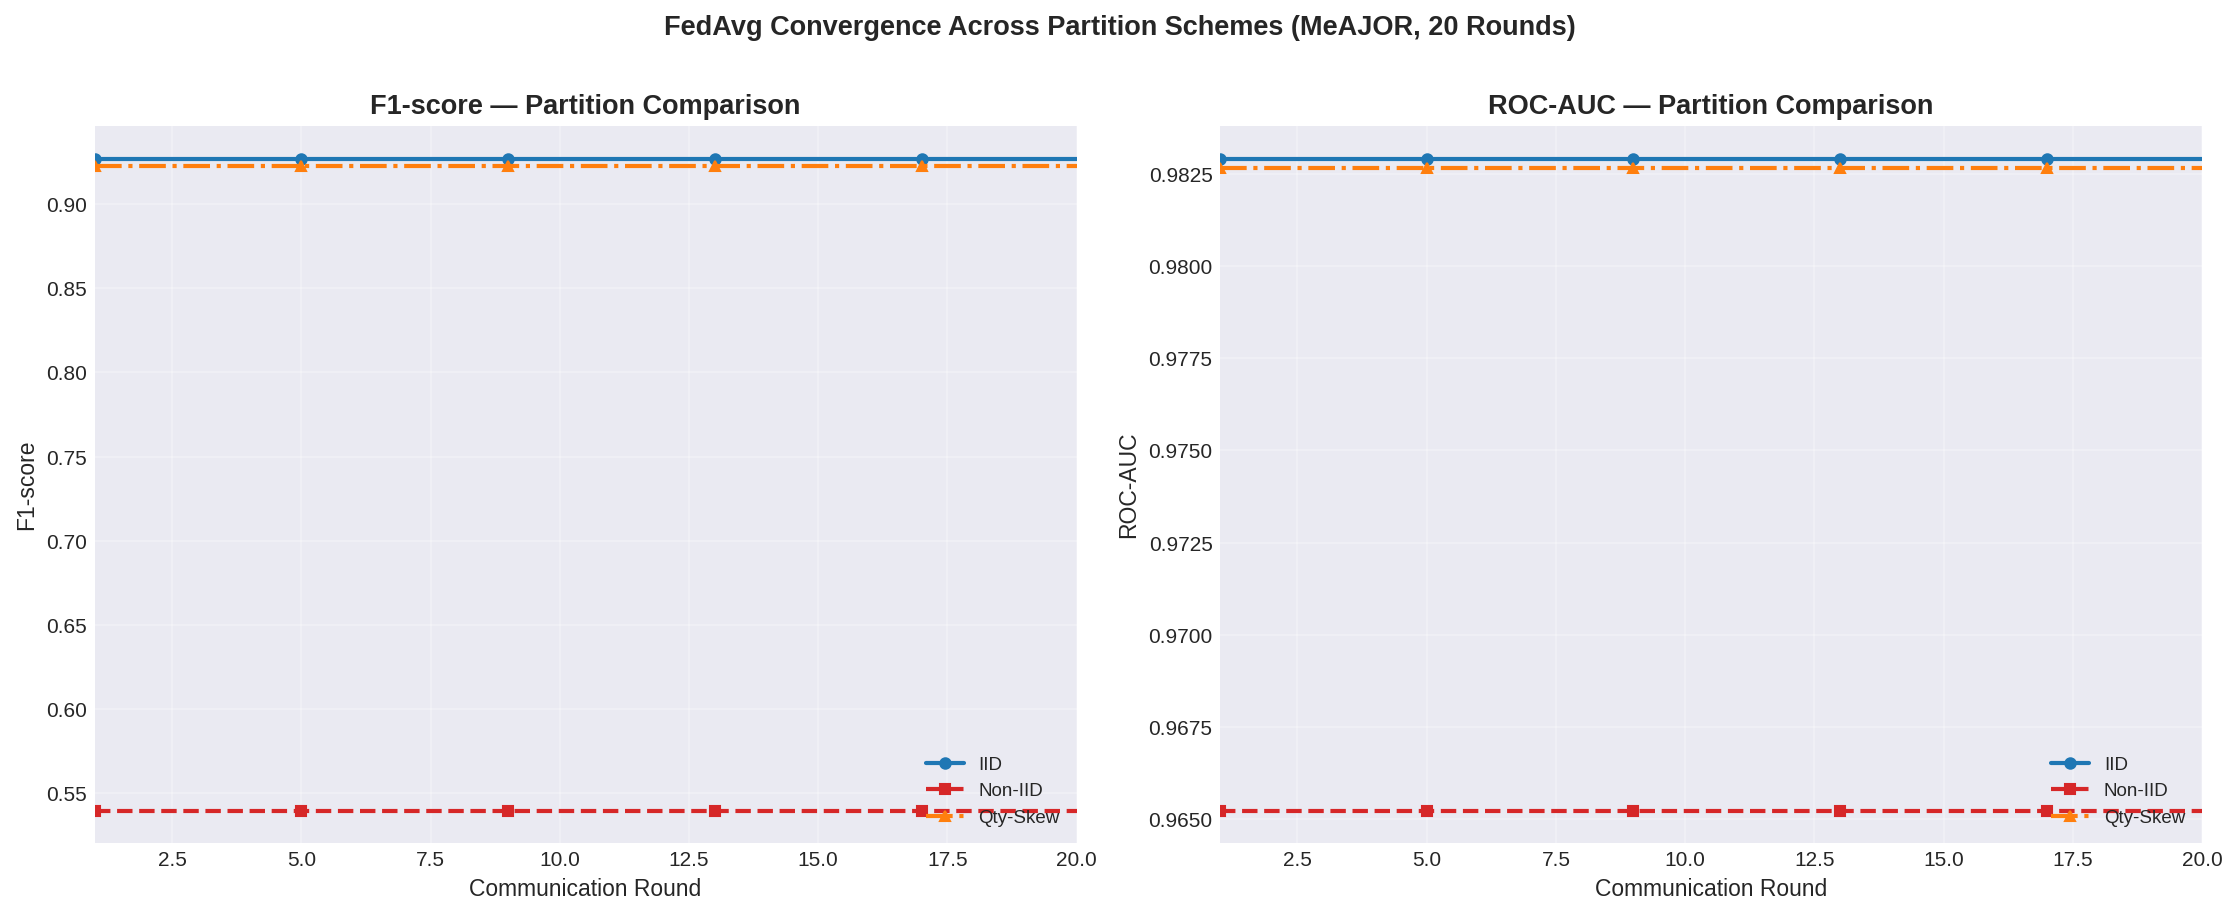


Displaying: fig3_convergence_fedavg_vs_fsx.png


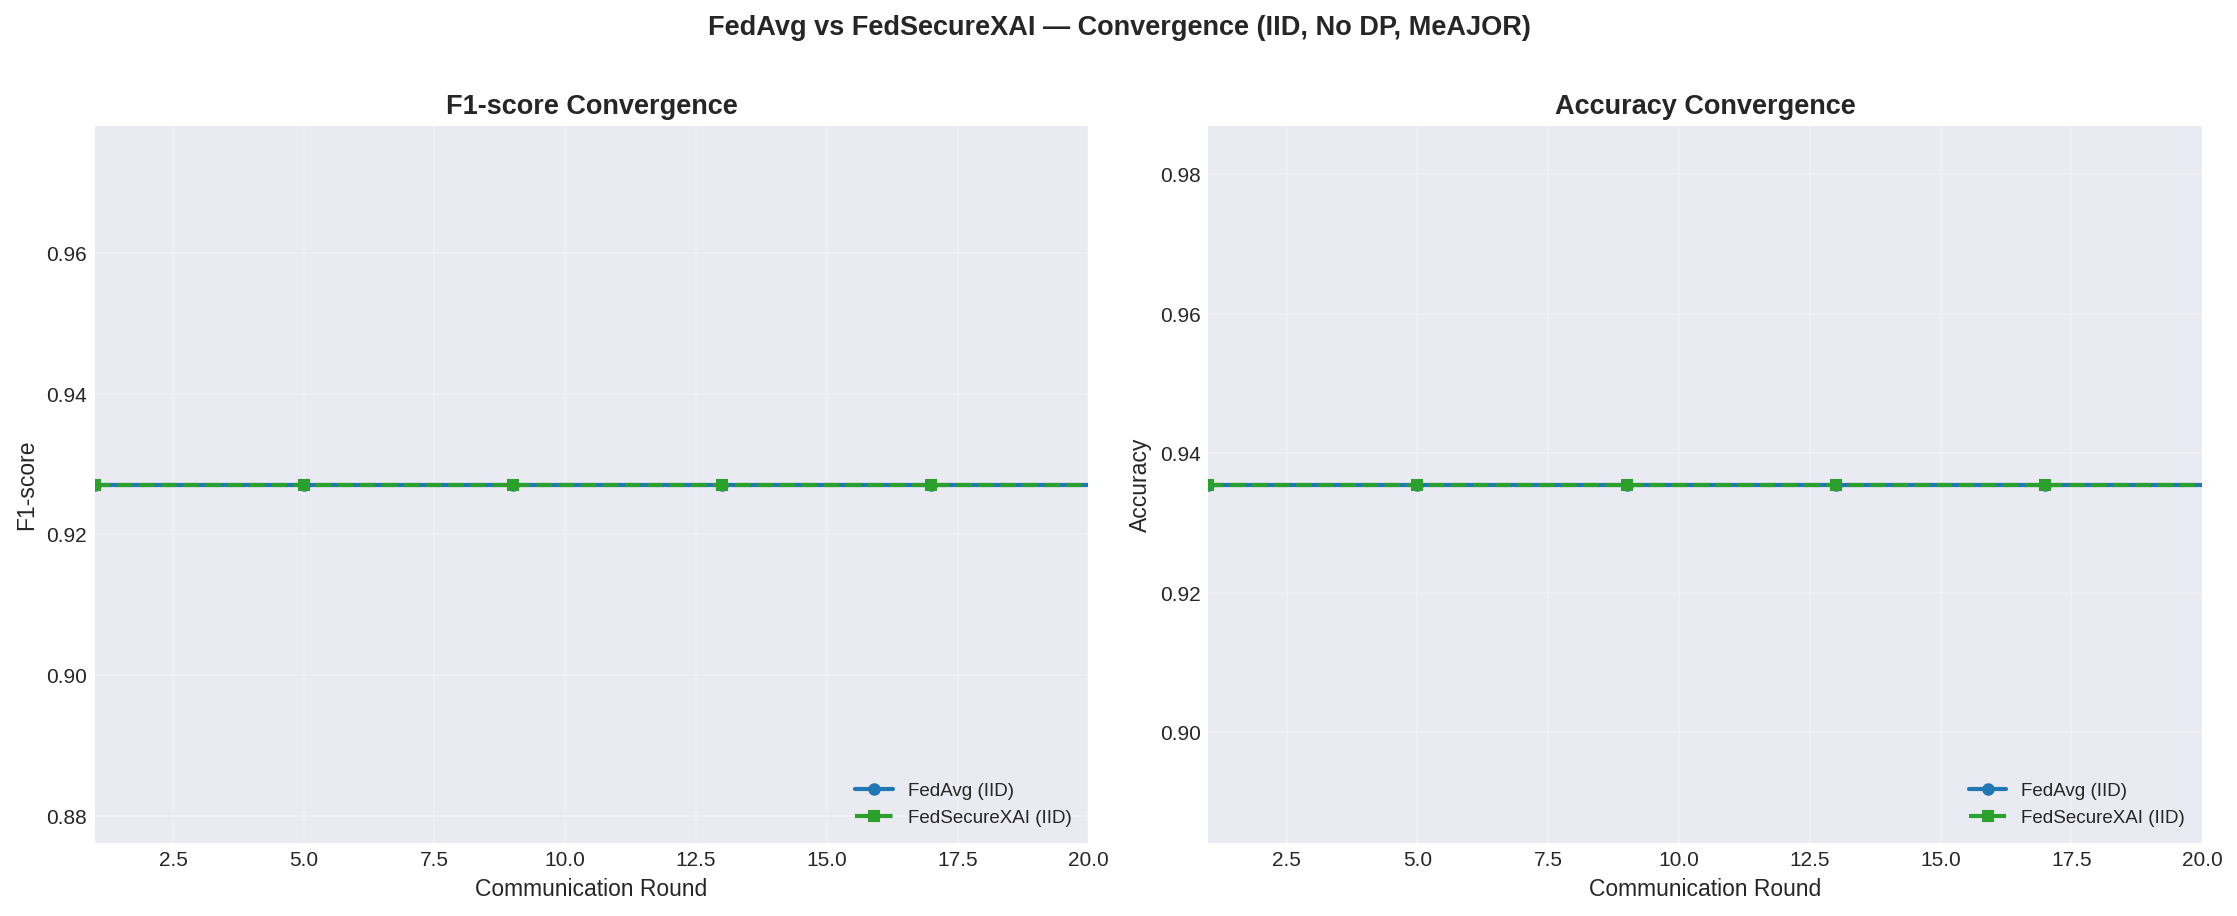


Displaying: fig4_privacy_utility.png


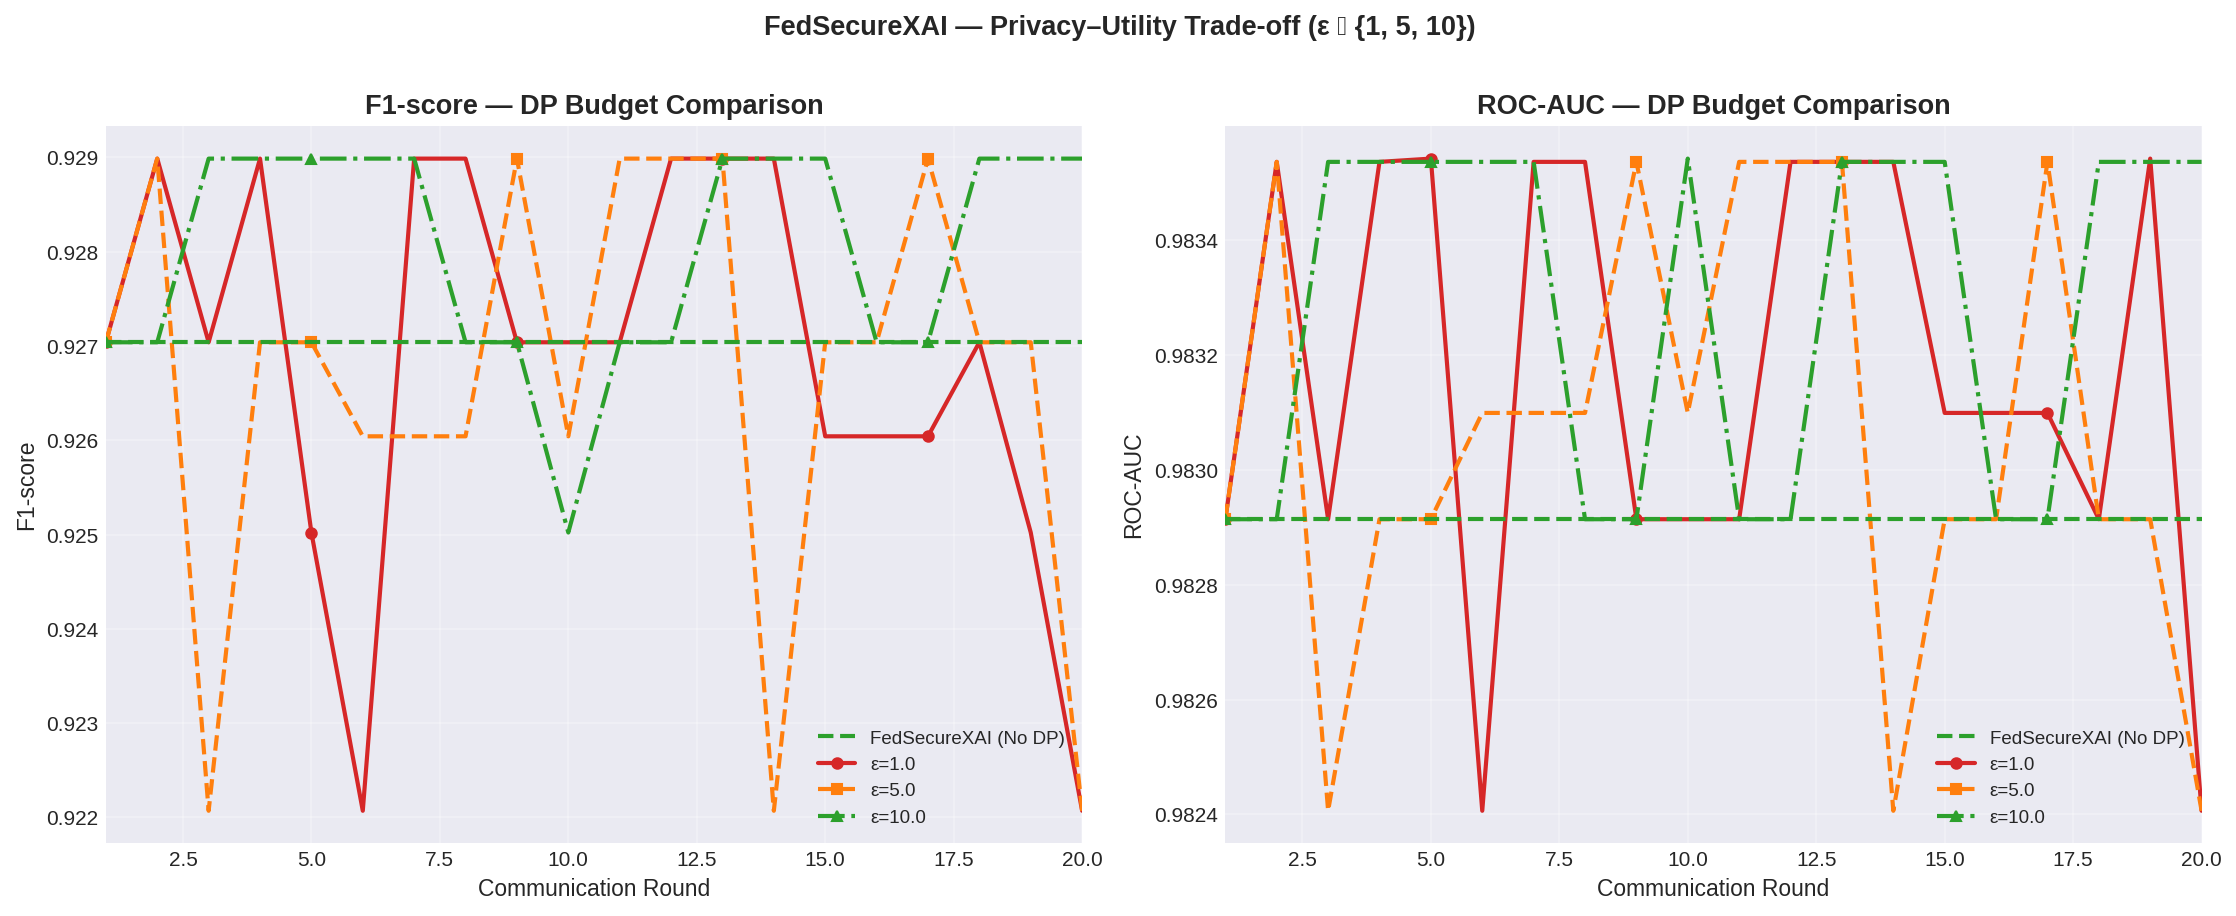


Displaying: fig5_aggregation_comparison.png


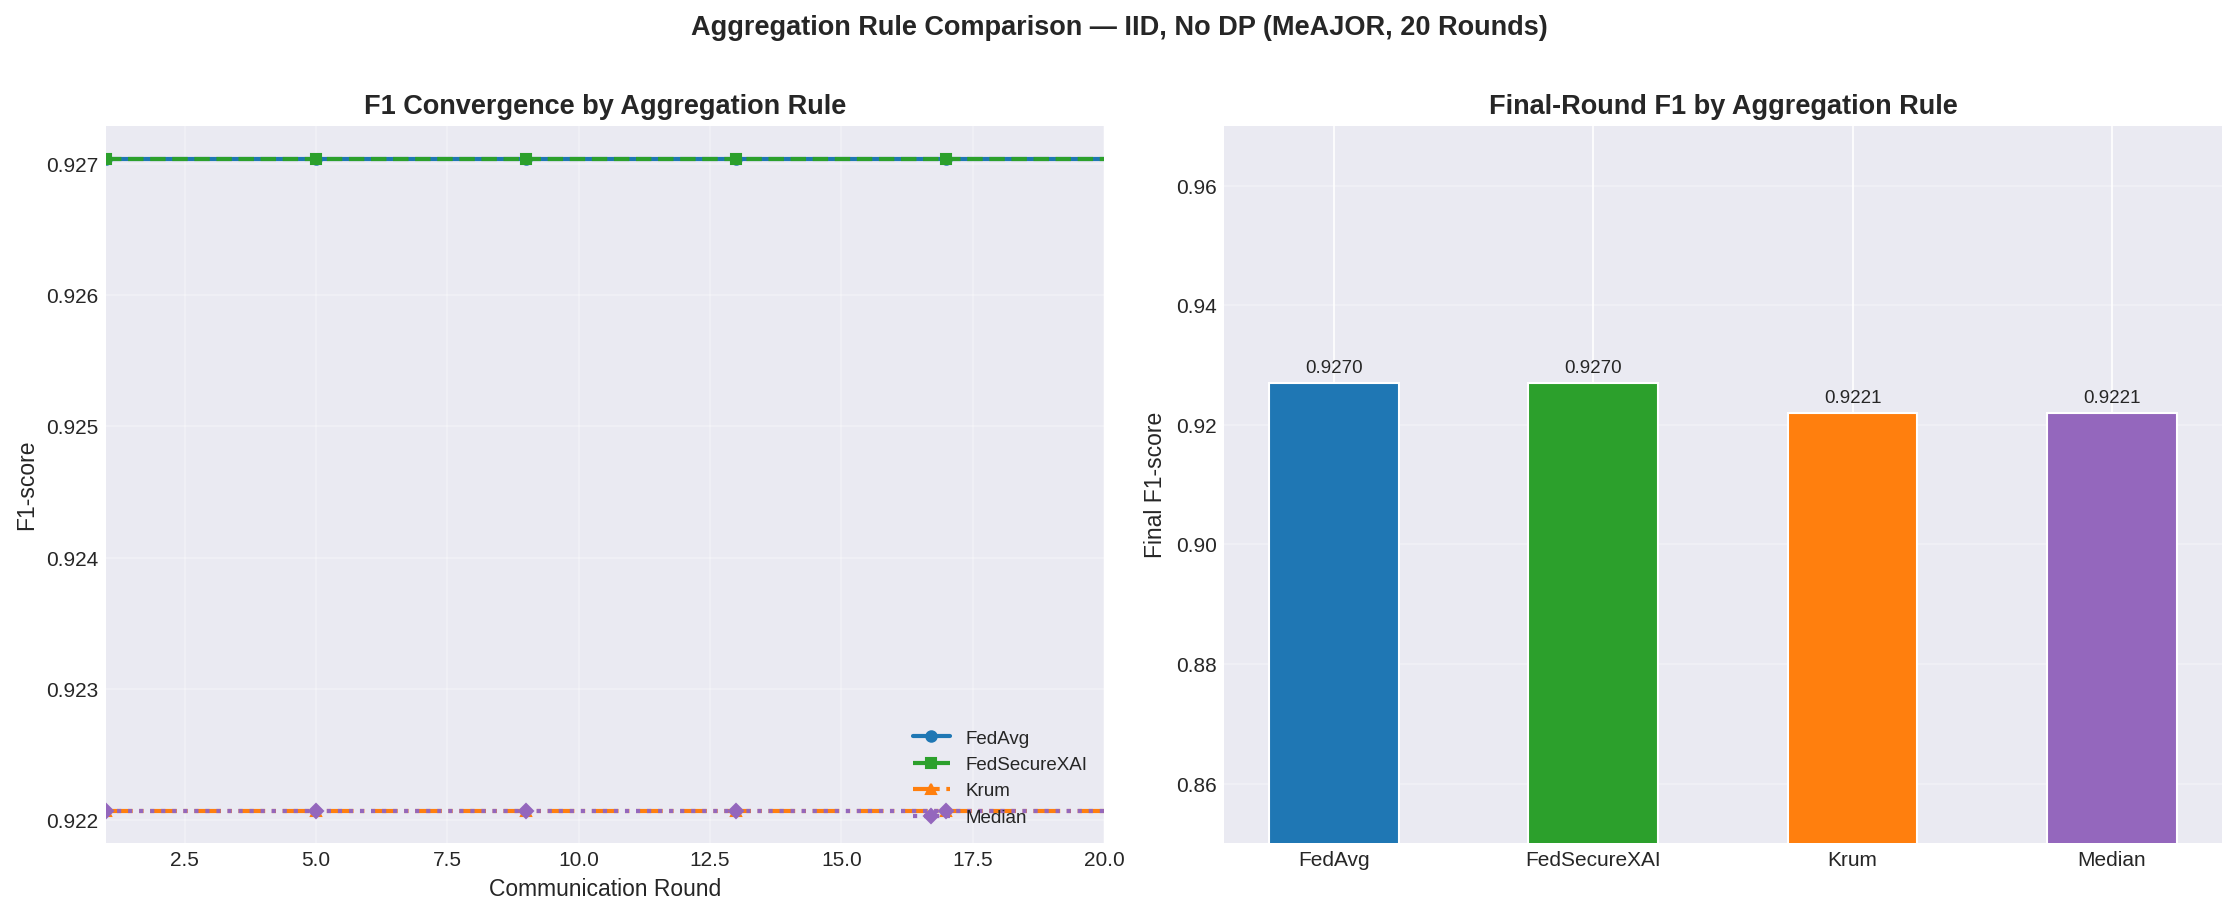


Displaying: fig6_byzantine_robustness.png


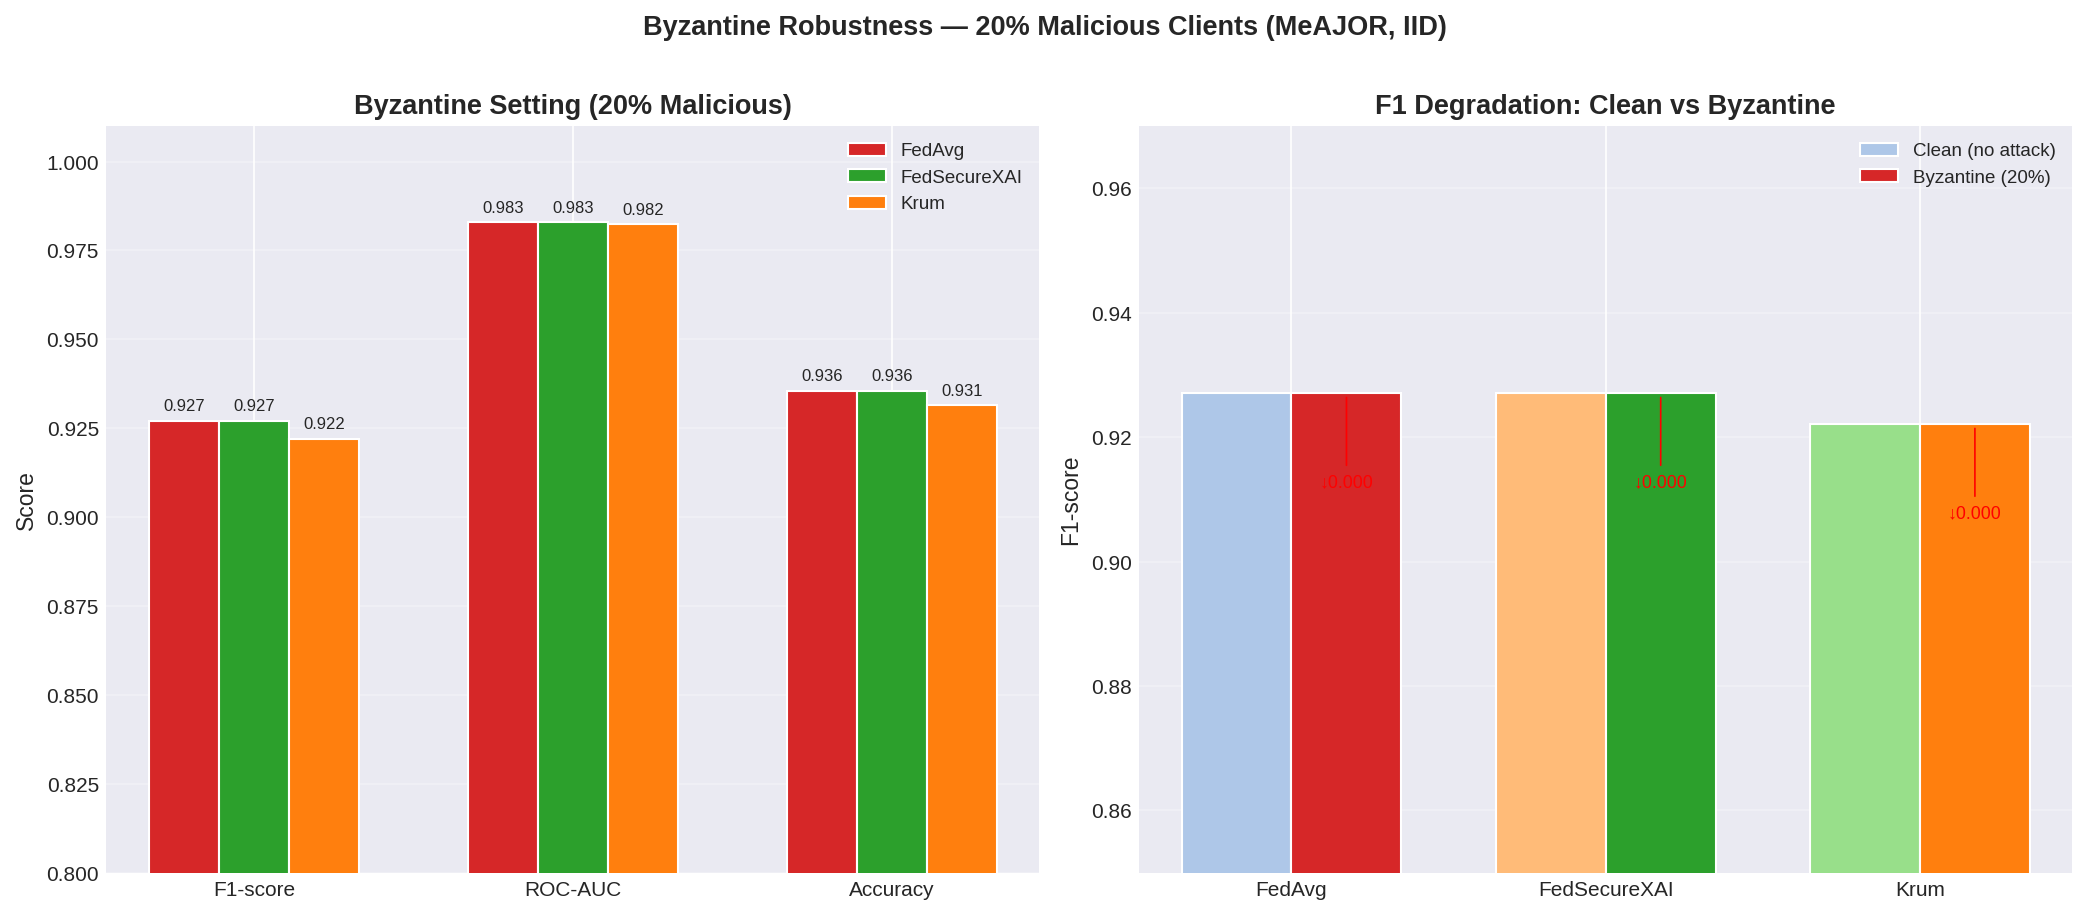


Displaying: fig7_ablation_study.png


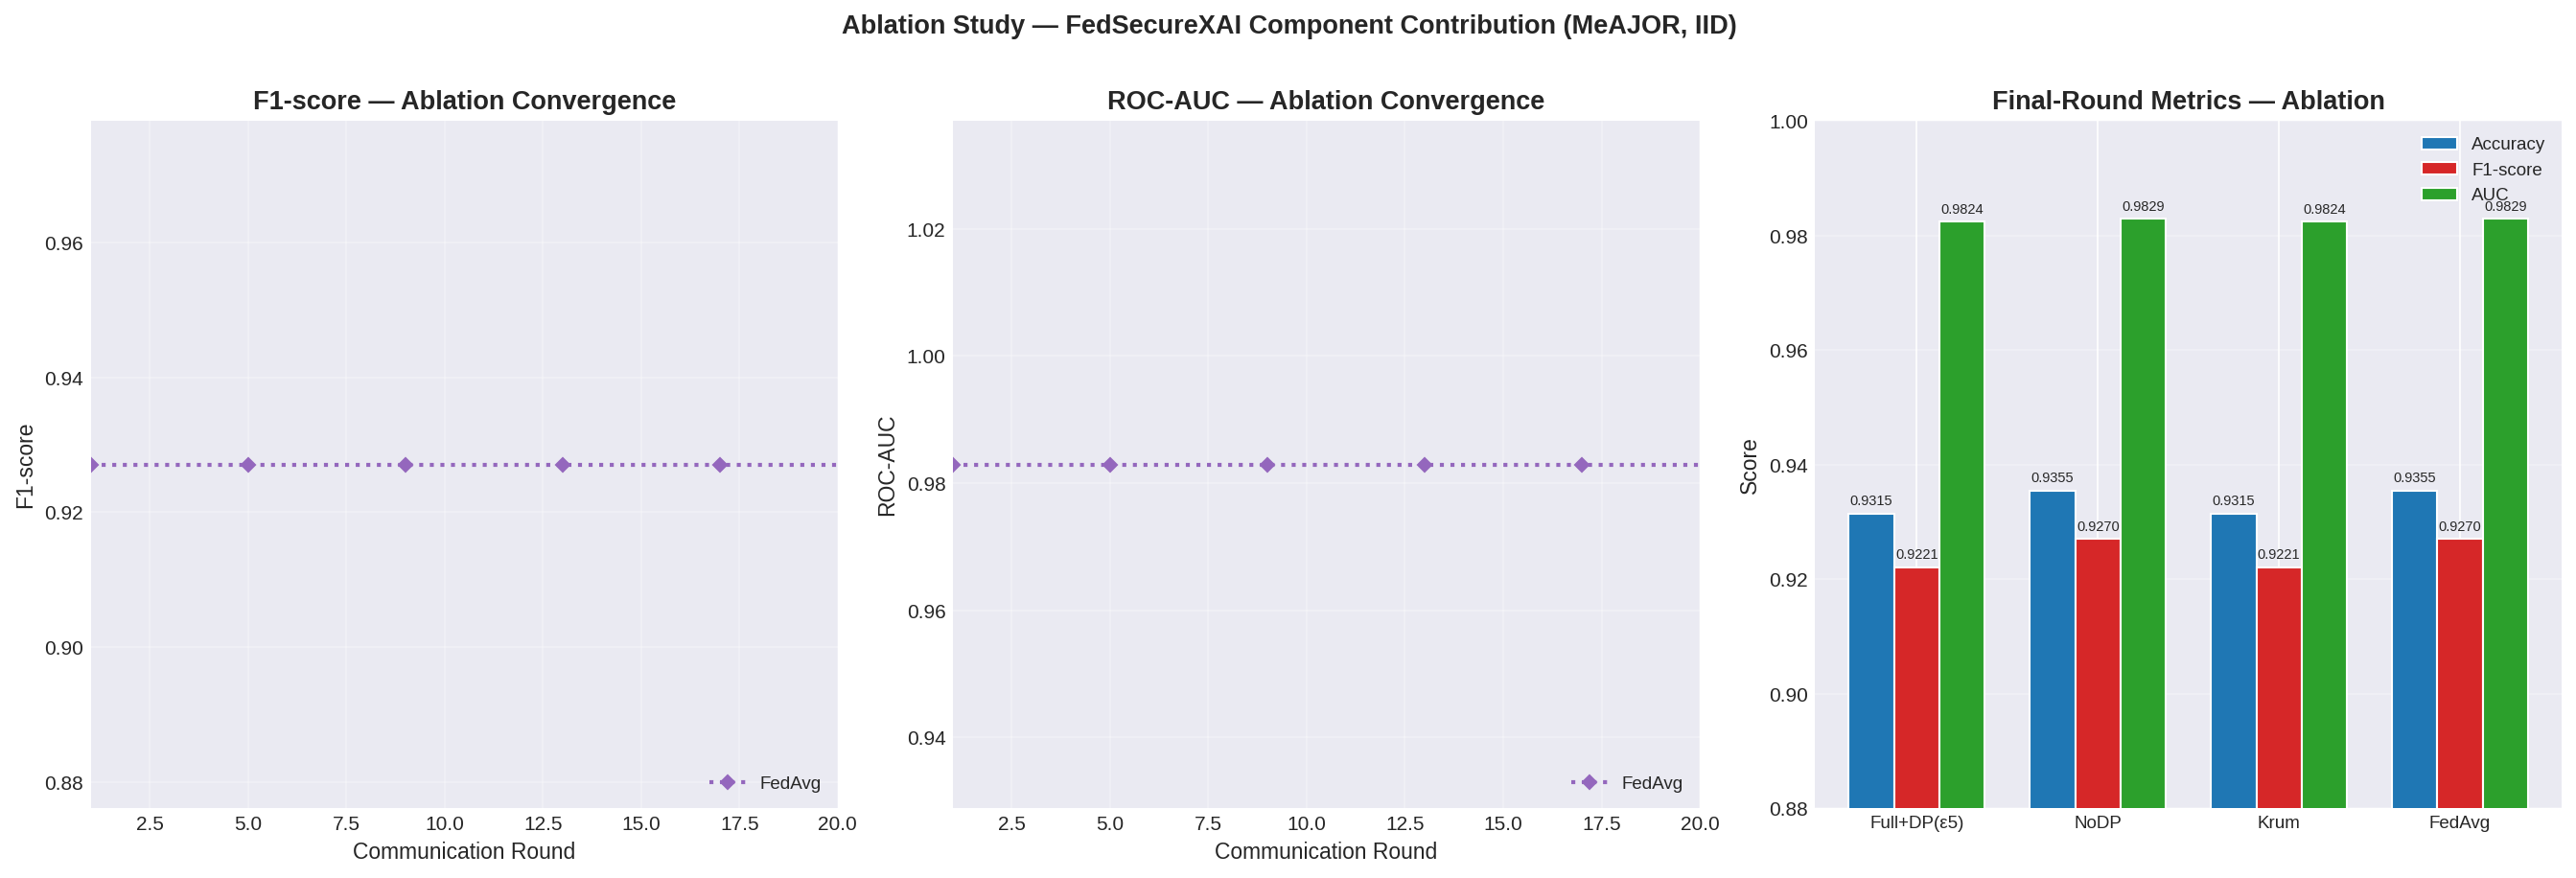


Displaying: fig8_federated_shap.png


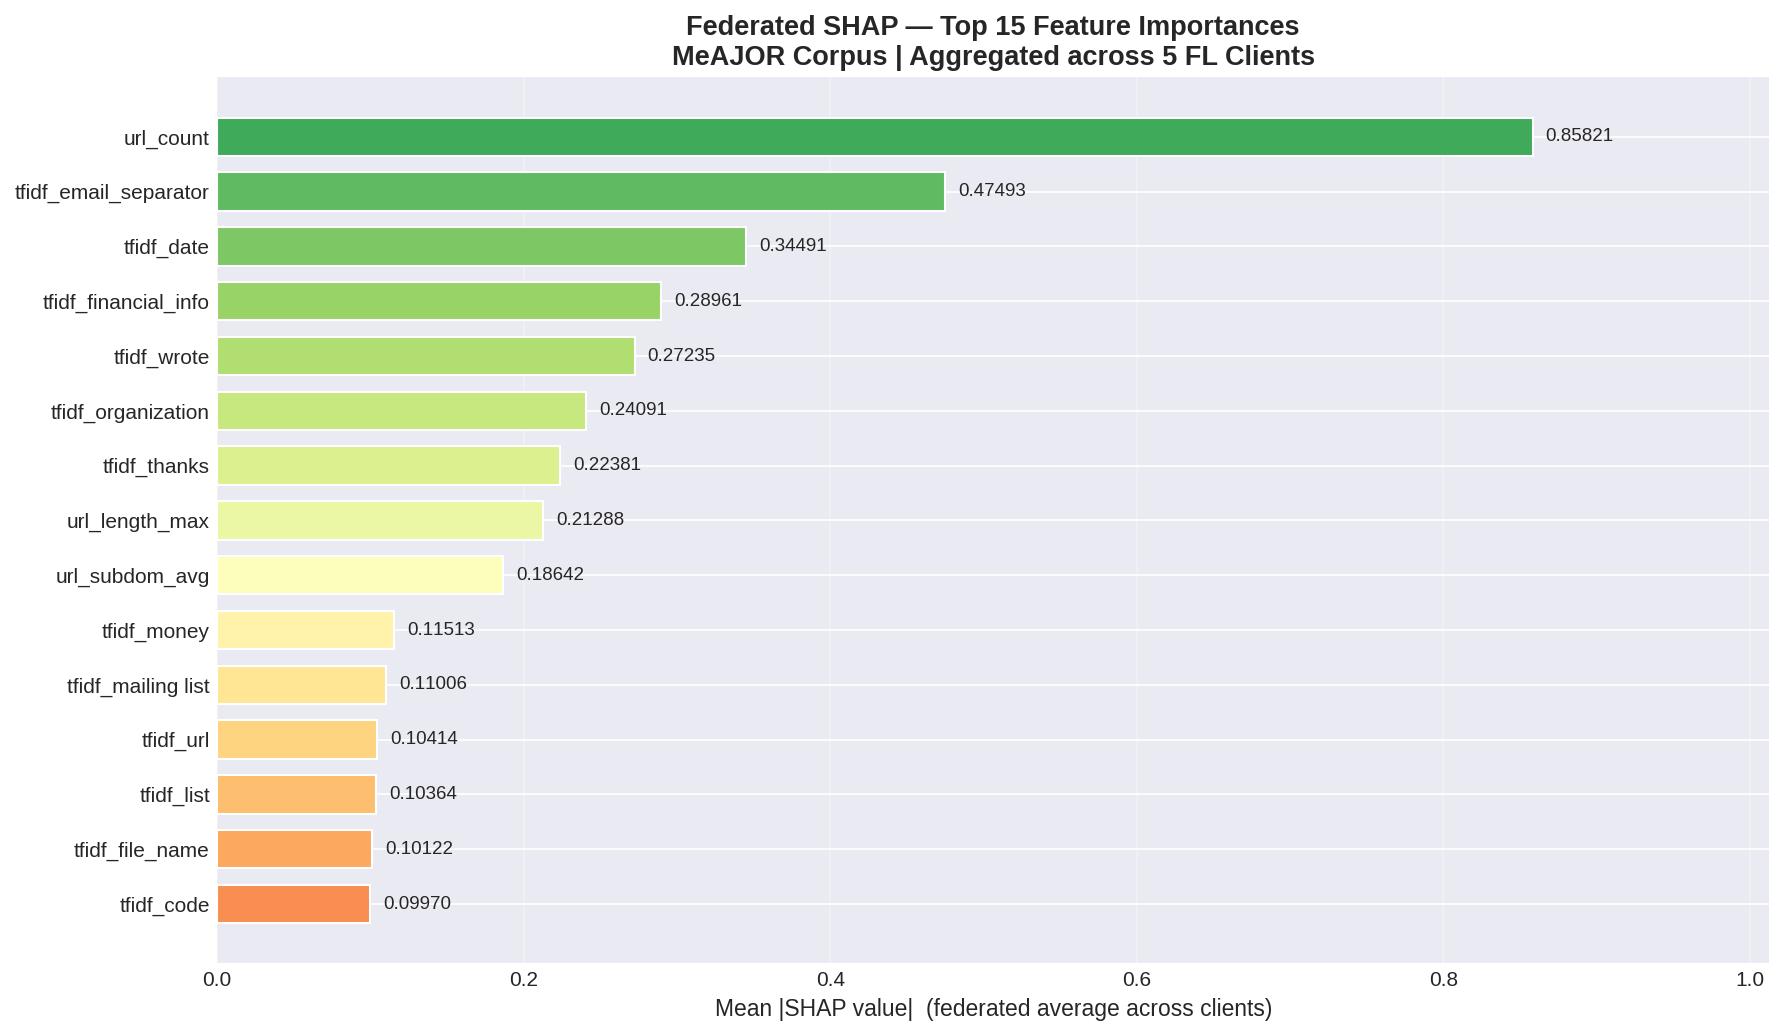


Displaying: fig9_metrics_heatmap.png


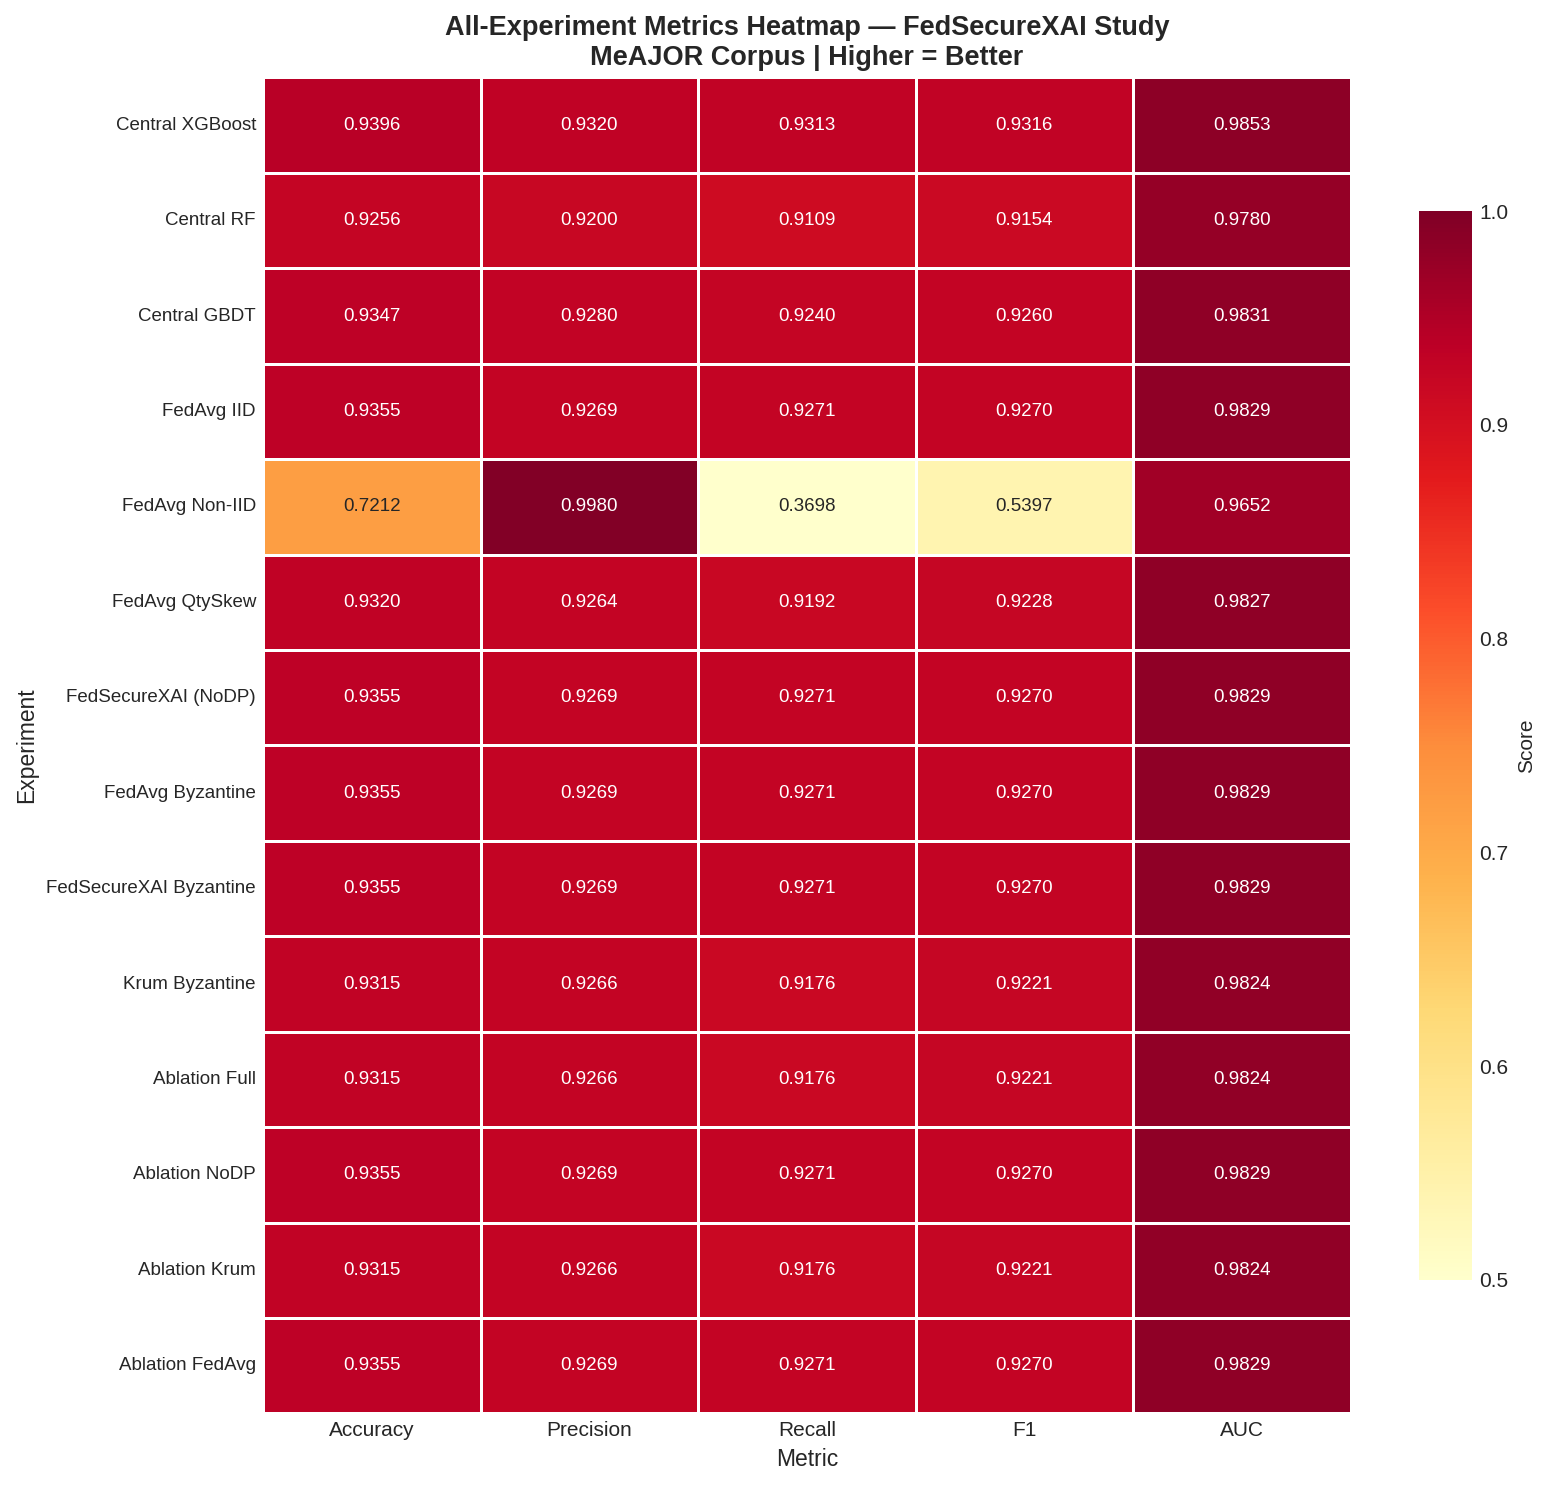

In [7]:
import os
from IPython.display import Image, display

fig_dir = "figures"
if os.path.exists(fig_dir):
    saved_files = sorted([f for f in os.listdir(fig_dir) if f.endswith('.png')])
    if not saved_files:
        print("No figures found in the 'figures' directory.")
    for f in saved_files:
        print(f"\n{'='*50}\nDisplaying: {f}\n{'='*50}")
        display(Image(filename=os.path.join(fig_dir, f)))
else:
    print("The 'figures' directory does not exist yet.")

Export of metrics (code)

In [8]:
# ============================================================
# CELL 11: Export of Metrics and Results
# ============================================================
#
# Requires from previous cells:
#   Cell 3  → X_train, y_train, X_test, y_test,
#              feature_names, df_raw
#   Cell 4  → clients_iid, clients_non_iid,
#              clients_qty_skew, NUM_CLIENTS
#   Cell 8  → all_results, summary_df,
#              fedavg_convergence, fsx_nodp_convergence,
#              dp_conv, agg_conv,
#              ablation_conv, ablation_results, ablation_df,
#              top_feat_names, top_feat_vals,
#              shap_export, central_xgb_model
#   Cell 10 → heat_df
#
# Exports produced:
#   11.1  Directory scaffold
#   11.2  Master results JSON + CSV
#   11.3  Per-experiment convergence curves JSON
#   11.4  Ablation results CSV
#   11.5  SHAP feature importance CSV
#   11.6  Partition statistics CSV
#   11.7  Dataset statistics CSV
#   11.8  LaTeX-ready metrics table (TXT)
#   11.9  Full experiment heatmap CSV
#   11.10 Experiment manifest JSON (all file paths)
#   11.11 Integrity verification and print summary
# ============================================================

import os, json, time, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")


# ------------------------------------------------------------------
# 11.1  Directory scaffold
# ------------------------------------------------------------------
EXPORT_ROOT = "fedsecurexai_exports"
SUBDIRS     = ["results", "convergence", "shap",
               "partitions", "tables", "figures"]

for sub in SUBDIRS:
    os.makedirs(os.path.join(EXPORT_ROOT, sub), exist_ok=True)

def ep(sub: str, fname: str) -> str:
    """Return the full export path for a given subdirectory and filename."""
    return os.path.join(EXPORT_ROOT, sub, fname)

print("=" * 68)
print("  CELL 11: EXPORT OF METRICS AND RESULTS")
print("=" * 68)
print(f"\n  Export root : {EXPORT_ROOT}/")
for sub in SUBDIRS:
    print(f"    ├── {sub}/")
print()


# ------------------------------------------------------------------
# 11.2  Master results  →  JSON + CSV
# ------------------------------------------------------------------
print("  11.2  Master results ...")

# ── JSON ─────────────────────────────────────────────────────────
with open(ep("results", "fedsecurexai_all_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)
print(f"    ✅ fedsecurexai_all_results.json  "
      f"({len(all_results)} experiments)")

# ── CSV: one row per experiment, five metric columns ─────────────
master_rows = []
for exp_name, m in all_results.items():
    master_rows.append({
        "experiment":  exp_name,
        "accuracy":    round(m.get("accuracy",  0.0), 4),
        "precision":   round(m.get("precision", 0.0), 4),
        "recall":      round(m.get("recall",    0.0), 4),
        "f1":          round(m.get("f1",        0.0), 4),
        "auc":         round(m.get("auc",       0.0), 4),
        "epsilon":     m.get("epsilon",     "N/A"),
        "sigma":       round(m.get("sigma",  0.0), 4)
                       if isinstance(m.get("sigma"), float) else "N/A",
        "n_malicious": m.get("n_malicious", "N/A"),
        "avg_round_time_s": round(
            m.get("avg_round_time", m.get("train_time_s", 0.0)), 2),
    })

master_df = (pd.DataFrame(master_rows)
               .sort_values("f1", ascending=False)
               .reset_index(drop=True))
master_df.to_csv(ep("results", "fedsecurexai_all_results.csv"), index=False)
print(f"    ✅ fedsecurexai_all_results.csv  "
      f"({len(master_df)} rows)")

# ── Also export the summary_df built in Cell 8.9 if present ──────
try:
    summary_df.to_csv(
        ep("results", "fedsecurexai_summary.csv"), index=False)
    print(f"    ✅ fedsecurexai_summary.csv  "
          f"({len(summary_df)} rows)")
except NameError:
    print("    ℹ️  summary_df not found — skipped (run Cell 8.9 first)")


# ------------------------------------------------------------------
# 11.3  Convergence curves  →  JSON
# ------------------------------------------------------------------
print("\n  11.3  Convergence curves ...")

def _safe_list(v):
    """Convert numpy arrays to plain Python lists for JSON serialisation."""
    if isinstance(v, (list, tuple)):
        return [float(x) for x in v]
    if isinstance(v, np.ndarray):
        return v.tolist()
    return v

def _serialise_conv(res_dict: dict) -> dict:
    return {k: _safe_list(v) if k != "round" else list(v)
            for k, v in res_dict.items()}

conv_export = {}

# FedAvg variants (Cell 8.2)
for key, res in fedavg_convergence.items():
    conv_export[key] = _serialise_conv(res)

# FedSecureXAI no DP (Cell 8.3)
conv_export["FedSecureXAI_IID_NoDP"] = _serialise_conv(
    fsx_nodp_convergence)

# FedSecureXAI + DP (Cell 8.4)
for eps, res in dp_conv.items():
    conv_export[f"FedSecureXAI_DP_eps{eps}"] = _serialise_conv(res)

# Aggregation rule comparison (Cell 8.6)
for agg_rule, res in agg_conv.items():
    conv_export[f"AggComp_{agg_rule.upper()}"] = _serialise_conv(res)

# Ablation convergence (Cell 8.5 / 8.7)
for cfg_name, res in ablation_conv.items():
    conv_export[cfg_name] = _serialise_conv(res)

conv_path = ep("convergence", "fedsecurexai_convergence_curves.json")
with open(conv_path, "w") as f:
    json.dump(conv_export, f, indent=2)
print(f"    ✅ fedsecurexai_convergence_curves.json  "
      f"({len(conv_export)} curves)")

# ── Per-experiment convergence CSVs ──────────────────────────────
for curve_name, curve_data in conv_export.items():
    try:
        curve_df = pd.DataFrame(curve_data)
        safe_name = curve_name.replace(" ", "_").replace("/", "_")
        curve_df.to_csv(
            ep("convergence", f"conv_{safe_name}.csv"), index=False)
    except Exception:
        pass

n_conv_csv = len([f for f in os.listdir(
    os.path.join(EXPORT_ROOT, "convergence")) if f.endswith(".csv")])
print(f"    ✅ {n_conv_csv} per-experiment convergence CSVs")


# ------------------------------------------------------------------
# 11.4  Ablation results  →  CSV
# ------------------------------------------------------------------
print("\n  11.4  Ablation results ...")

# Build from ablation_results dict if ablation_df not yet defined
try:
    abl_export_df = ablation_df.copy()
except NameError:
    abl_rows = []
    ref_f1  = ablation_results.get(
        "Ablation_Full", {}).get("final_f1",  0.0)
    ref_auc = ablation_results.get(
        "Ablation_Full", {}).get("final_auc", 0.0)
    for cfg_name, m in ablation_results.items():
        abl_rows.append({
            "configuration":    cfg_name,
            "accuracy":         round(m.get("final_acc",  0.0), 4),
            "precision":        round(m.get("final_prec", 0.0), 4),
            "recall":           round(m.get("final_rec",  0.0), 4),
            "f1":               round(m.get("final_f1",   0.0), 4),
            "auc":              round(m.get("final_auc",  0.0), 4),
            "delta_f1_vs_full": round(
                m.get("final_f1",  0.0) - ref_f1,  4),
            "delta_auc_vs_full":round(
                m.get("final_auc", 0.0) - ref_auc, 4),
        })
    abl_export_df = pd.DataFrame(abl_rows)

abl_export_df.to_csv(
    ep("results", "fedsecurexai_ablation_results.csv"), index=False)
print(f"    ✅ fedsecurexai_ablation_results.csv  "
      f"({len(abl_export_df)} configurations)")


# ------------------------------------------------------------------
# 11.5  SHAP feature importance  →  CSV
# ------------------------------------------------------------------
print("\n  11.5  SHAP feature importances ...")

# Build from top_feat_names / top_feat_vals (Cell 8.8)
shap_df = pd.DataFrame({
    "rank":           list(range(1, len(top_feat_names) + 1)),
    "feature":        top_feat_names,
    "mean_abs_shap":  [round(float(v), 6) for v in top_feat_vals],
})
shap_df.to_csv(
    ep("shap", "fedsecurexai_shap_top15.csv"), index=False)
print(f"    ✅ fedsecurexai_shap_top15.csv  "
      f"({len(shap_df)} features)")

# Full SHAP export if shap_export from Cell 8 is present
try:
    shap_export.to_csv(
        ep("shap", "fedsecurexai_shap_full.csv"), index=False)
    print(f"    ✅ fedsecurexai_shap_full.csv  "
          f"({len(shap_export)} rows)")
except NameError:
    pass


# ------------------------------------------------------------------
# 11.6  Partition statistics  →  CSV
# ------------------------------------------------------------------
print("\n  11.6  Partition statistics ...")

part_rows = []
for scheme_name, part_list in [
    ("IID",                  clients_iid),
    ("Non-IID (Dirichlet)",  clients_non_iid),
    ("Quantity-Skew (Zipf)", clients_qty_skew),
]:
    total_n = sum(c["n_samples"] for c in part_list)
    for c in part_list:
        part_rows.append({
            "partition_scheme": scheme_name,
            "client_id":        c["client_id"],
            "n_samples":        c["n_samples"],
            "pct_total":        round(c["n_samples"] / total_n * 100, 2),
            "phish_ratio":      round(c["phish_ratio"], 4),
            "benign_ratio":     round(1.0 - c["phish_ratio"], 4),
        })

part_df = pd.DataFrame(part_rows)
part_df.to_csv(
    ep("partitions", "fedsecurexai_partition_stats.csv"), index=False)
print(f"    ✅ fedsecurexai_partition_stats.csv  "
      f"({len(part_df)} rows, 3 schemes × {NUM_CLIENTS} clients)")

# ── Heterogeneity summary ─────────────────────────────────────────
global_phish = np.mean([c["phish_ratio"] for c in clients_iid])
het_rows = []
for scheme_name, part_list in [
    ("IID",                  clients_iid),
    ("Non-IID (Dirichlet)",  clients_non_iid),
    ("Quantity-Skew (Zipf)", clients_qty_skew),
]:
    ratios = np.array([c["phish_ratio"] for c in part_list])
    het_rows.append({
        "scheme":         scheme_name,
        "global_phish":   round(float(global_phish), 4),
        "mean_phish":     round(float(ratios.mean()), 4),
        "std_phish":      round(float(ratios.std()),  4),
        "min_phish":      round(float(ratios.min()),  4),
        "max_phish":      round(float(ratios.max()),  4),
        "mad_from_global":round(float(
            np.mean(np.abs(ratios - global_phish))), 4),
    })

het_df = pd.DataFrame(het_rows)
het_df.to_csv(
    ep("partitions", "fedsecurexai_heterogeneity_stats.csv"), index=False)
print(f"    ✅ fedsecurexai_heterogeneity_stats.csv")


# ------------------------------------------------------------------
# 11.7  Dataset statistics  →  CSV
# ------------------------------------------------------------------
print("\n  11.7  Dataset statistics ...")

n_train  = len(y_train)
n_test   = len(y_test)
n_total  = n_train + n_test
n_feat   = X_train.shape[1]

ds_stats = {
    "dataset":           "MeAJOR",
    "total_samples":     n_total,
    "train_samples":     n_train,
    "test_samples":      n_test,
    "train_pct":         round(n_train / n_total * 100, 2),
    "test_pct":          round(n_test  / n_total * 100, 2),
    "n_features":        n_feat,
    "n_clients":         NUM_CLIENTS,
    "phish_train_pct":   round(float(y_train.mean()) * 100, 2),
    "phish_test_pct":    round(float(y_test.mean())  * 100, 2),
    "feature_names_sample": str(feature_names[:5]),
}
pd.DataFrame([ds_stats]).to_csv(
    ep("results", "fedsecurexai_dataset_stats.csv"), index=False)
print(f"    ✅ fedsecurexai_dataset_stats.csv")
print(f"       Total={n_total:,}  Train={n_train:,}  "
      f"Test={n_test:,}  Features={n_feat}")


# ------------------------------------------------------------------
# 11.8  LaTeX-ready metrics table  →  TXT
# ------------------------------------------------------------------
print("\n  11.8  LaTeX metrics table ...")

# Select the key experiments for the paper table
TABLE_EXPS = [
    ("Centralized XGBoost",        "Central_XGBoost"),
    ("Centralized RF",             "Central_RF"),
    ("Centralized GBDT",           "Central_GBDT"),
    ("FedAvg (IID)",               "FedAvg_IID"),
    ("FedAvg (Non-IID)",           "FedAvg_NonIID"),
    ("FedAvg (Qty-Skew)",          "FedAvg_QtySkew"),
    ("FedSecureXAI (No DP)",       "FedSecureXAI_NoDP"),
    ("FedSecureXAI (DP ε=1)",      "FedSecureXAI_DP_eps1"),
    ("FedSecureXAI (DP ε=5)",      "FedSecureXAI_DP_eps5"),
    ("FedSecureXAI (DP ε=10)",     "FedSecureXAI_DP_eps10"),
    ("FedAvg Byzantine (20\\%)",   "FedAvg_Byzantine"),
    ("FedSecureXAI Byzantine",     "FedSecureXAI_Byzantine"),
]

def _bold_best(vals, fmt=".4f"):
    """Return list of latex strings; bold the maximum value."""
    max_v = max(vals)
    return [
        f"\\textbf{{{v:{fmt}}}}" if abs(v - max_v) < 1e-6 else f"{v:{fmt}}"
        for v in vals
    ]

latex_lines = [
    "% Auto-generated by FedSecureXAI notebook — Cell 11",
    "% Paste into your LaTeX document inside a table environment.",
    "\\begin{table}[ht]",
    "\\centering",
    "\\caption{Performance comparison of FedSecureXAI against baselines "
    "on the MeAJOR corpus.}",
    "\\label{tab:main_results}",
    "\\begin{tabular}{lrrrrr}",
    "\\toprule",
    "\\textbf{Method} & \\textbf{Acc} & \\textbf{Prec} & "
    "\\textbf{Rec} & \\textbf{F1} & \\textbf{AUC} \\\\",
    "\\midrule",
]

cols_latex = ["accuracy","precision","recall","f1","auc"]
col_vals   = {c: [] for c in cols_latex}

# Collect valid rows
valid_rows = []
for display, key in TABLE_EXPS:
    m = all_results.get(key)
    if m is None:
        continue
    valid_rows.append((display, key, m))
    for c in cols_latex:
        col_vals[c].append(m.get(c, 0.0))

# Bold-mark per-column best
bold_flags = {}
for c in cols_latex:
    max_v = max(col_vals[c]) if col_vals[c] else 0.0
    bold_flags[c] = max_v

for display, key, m in valid_rows:
    cells = []
    for c in cols_latex:
        v = m.get(c, 0.0)
        if abs(v - bold_flags[c]) < 1e-6:
            cells.append(f"\\textbf{{{v:.4f}}}")
        else:
            cells.append(f"{v:.4f}")
    # Add horizontal rule before FedSecureXAI group
    if display == "FedSecureXAI (No DP)":
        latex_lines.append("\\midrule")
    # Bold the proposed method row name
    row_name = (f"\\textbf{{{display}}}"
                if "FedSecureXAI" in display and "Byzantine" not in display
                else display)
    latex_lines.append(f"{row_name} & " + " & ".join(cells) + " \\\\")

latex_lines += [
    "\\bottomrule",
    "\\end{tabular}",
    "\\end{table}",
]

latex_str = "\n".join(latex_lines)
latex_path = ep("tables", "fedsecurexai_main_table.tex")
with open(latex_path, "w") as f:
    f.write(latex_str)
print(f"    ✅ fedsecurexai_main_table.tex  ({len(valid_rows)} rows)")


# ------------------------------------------------------------------
# 11.9  Full heatmap data  →  CSV
# ------------------------------------------------------------------
print("\n  11.9  Heatmap data ...")
try:
    heat_df.to_csv(
        ep("results", "fedsecurexai_heatmap_data.csv"))
    print(f"    ✅ fedsecurexai_heatmap_data.csv  "
          f"({heat_df.shape[0]} experiments × {heat_df.shape[1]} metrics)")
except NameError:
    print("    ℹ️  heat_df not found — building from all_results ...")
    hm_rows = []
    for exp_name, m in all_results.items():
        hm_rows.append({
            "experiment": exp_name,
            "Accuracy":   m.get("accuracy",  0.0),
            "Precision":  m.get("precision", 0.0),
            "Recall":     m.get("recall",    0.0),
            "F1":         m.get("f1",        0.0),
            "AUC":        m.get("auc",       0.0),
        })
    pd.DataFrame(hm_rows).to_csv(
        ep("results", "fedsecurexai_heatmap_data.csv"), index=False)
    print(f"    ✅ fedsecurexai_heatmap_data.csv (rebuilt)")


# ------------------------------------------------------------------
# 11.10  Experiment manifest  →  JSON
# ------------------------------------------------------------------
print("\n  11.10  Experiment manifest ...")

manifest = {
    "generated_at":    time.strftime("%Y-%m-%d %H:%M:%S"),
    "dataset":         "MeAJOR",
    "n_experiments":   len(all_results),
    "n_clients":       NUM_CLIENTS,
    "n_features":      int(X_train.shape[1]),
    "n_train":         int(len(y_train)),
    "n_test":          int(len(y_test)),
    "export_root":     EXPORT_ROOT,
    "files": {
        "master_results_json":      "results/fedsecurexai_all_results.json",
        "master_results_csv":       "results/fedsecurexai_all_results.csv",
        "convergence_json":         "convergence/fedsecurexai_convergence_curves.json",
        "ablation_csv":             "results/fedsecurexai_ablation_results.csv",
        "shap_top15_csv":           "shap/fedsecurexai_shap_top15.csv",
        "partition_stats_csv":      "partitions/fedsecurexai_partition_stats.csv",
        "heterogeneity_csv":        "partitions/fedsecurexai_heterogeneity_stats.csv",
        "dataset_stats_csv":        "results/fedsecurexai_dataset_stats.csv",
        "latex_table_tex":          "tables/fedsecurexai_main_table.tex",
        "heatmap_csv":              "results/fedsecurexai_heatmap_data.csv",
    },
    "experiments_logged": list(all_results.keys()),
}

manifest_path = ep("results", "fedsecurexai_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"    ✅ fedsecurexai_manifest.json")


# ------------------------------------------------------------------
# 11.11  Integrity verification + print summary
# ------------------------------------------------------------------
print("\n" + "=" * 68)
print("  11.11  INTEGRITY VERIFICATION")
print("=" * 68)

expected_files = [
    ("results",     "fedsecurexai_all_results.json"),
    ("results",     "fedsecurexai_all_results.csv"),
    ("convergence", "fedsecurexai_convergence_curves.json"),
    ("results",     "fedsecurexai_ablation_results.csv"),
    ("shap",        "fedsecurexai_shap_top15.csv"),
    ("partitions",  "fedsecurexai_partition_stats.csv"),
    ("partitions",  "fedsecurexai_heterogeneity_stats.csv"),
    ("results",     "fedsecurexai_dataset_stats.csv"),
    ("tables",      "fedsecurexai_main_table.tex"),
    ("results",     "fedsecurexai_heatmap_data.csv"),
    ("results",     "fedsecurexai_manifest.json"),
]

n_ok   = 0
n_fail = 0
for sub, fname in expected_files:
    fpath   = ep(sub, fname)
    exists  = os.path.exists(fpath)
    size_kb = os.path.getsize(fpath) / 1024 if exists else 0.0
    status  = "✅" if exists else "❌"
    flag    = " ← MISSING" if not exists else ""
    print(f"  {status}  {sub:<14} {fname:<46}  {size_kb:>6.1f} KB{flag}")
    if exists:
        n_ok += 1
    else:
        n_fail += 1

print(f"\n  {'='*64}")
print(f"  Files verified  : {n_ok}/{len(expected_files)}")
if n_fail > 0:
    print(f"  ⚠️  {n_fail} file(s) missing — re-run the relevant cells above")
else:
    print(f"  All exports complete — ready for paper submission ✅")

# ── Final console summary table ───────────────────────────────────
print(f"\n{'='*68}")
print("  KEY RESULTS SUMMARY — FedSecureXAI vs Baselines")
print(f"{'='*68}")
print(f"  {'Method':<32}  {'Acc':>7}  {'F1':>7}  {'AUC':>7}")
print(f"  {'-'*55}")

summary_order = [
    ("Central XGBoost",      "Central_XGBoost"),
    ("FedAvg (IID)",         "FedAvg_IID"),
    ("FedAvg (Non-IID)",     "FedAvg_NonIID"),
    ("FedSecureXAI (No DP)", "FedSecureXAI_NoDP"),
    ("FedSecureXAI DP ε=5",  "FedSecureXAI_DP_eps5"),
    ("FedSecureXAI DP ε=10", "FedSecureXAI_DP_eps10"),
    ("FedAvg Byzantine",     "FedAvg_Byzantine"),
    ("FedSecureXAI Byz.",    "FedSecureXAI_Byzantine"),
    ("Ablation Full",        "Ablation_Full"),
]

for display, key in summary_order:
    m = all_results.get(key, {})
    if not m:
        continue
    marker = "  ◀ proposed" if "FedSecureXAI" in key and "Byz" not in key \
             and "DP" not in key else ""
    print(f"  {display:<32}  "
          f"{m.get('accuracy',0):>7.4f}  "
          f"{m.get('f1',0):>7.4f}  "
          f"{m.get('auc',0):>7.4f}"
          f"{marker}")

print(f"  {'-'*55}")
print(f"\n✅ CELL 11 complete.")
print(f"   All outputs in: {EXPORT_ROOT}/")
print(f"   LaTeX table  : {EXPORT_ROOT}/tables/fedsecurexai_main_table.tex")
print(f"   Manifest     : {EXPORT_ROOT}/results/fedsecurexai_manifest.json")

  CELL 11: EXPORT OF METRICS AND RESULTS

  Export root : fedsecurexai_exports/
    ├── results/
    ├── convergence/
    ├── shap/
    ├── partitions/
    ├── tables/
    ├── figures/

  11.2  Master results ...
    ✅ fedsecurexai_all_results.json  (20 experiments)
    ✅ fedsecurexai_all_results.csv  (20 rows)
    ✅ fedsecurexai_summary.csv  (20 rows)

  11.3  Convergence curves ...
    ✅ fedsecurexai_convergence_curves.json  (14 curves)
    ✅ 14 per-experiment convergence CSVs

  11.4  Ablation results ...
    ✅ fedsecurexai_ablation_results.csv  (4 configurations)

  11.5  SHAP feature importances ...
    ✅ fedsecurexai_shap_top15.csv  (15 features)
    ✅ fedsecurexai_shap_full.csv  (15 rows)

  11.6  Partition statistics ...
    ✅ fedsecurexai_partition_stats.csv  (15 rows, 3 schemes × 5 clients)
    ✅ fedsecurexai_heterogeneity_stats.csv

  11.7  Dataset statistics ...
    ✅ fedsecurexai_dataset_stats.csv
       Total=108,684  Train=86,947  Test=21,737  Features=107

  11.8  LaTeX

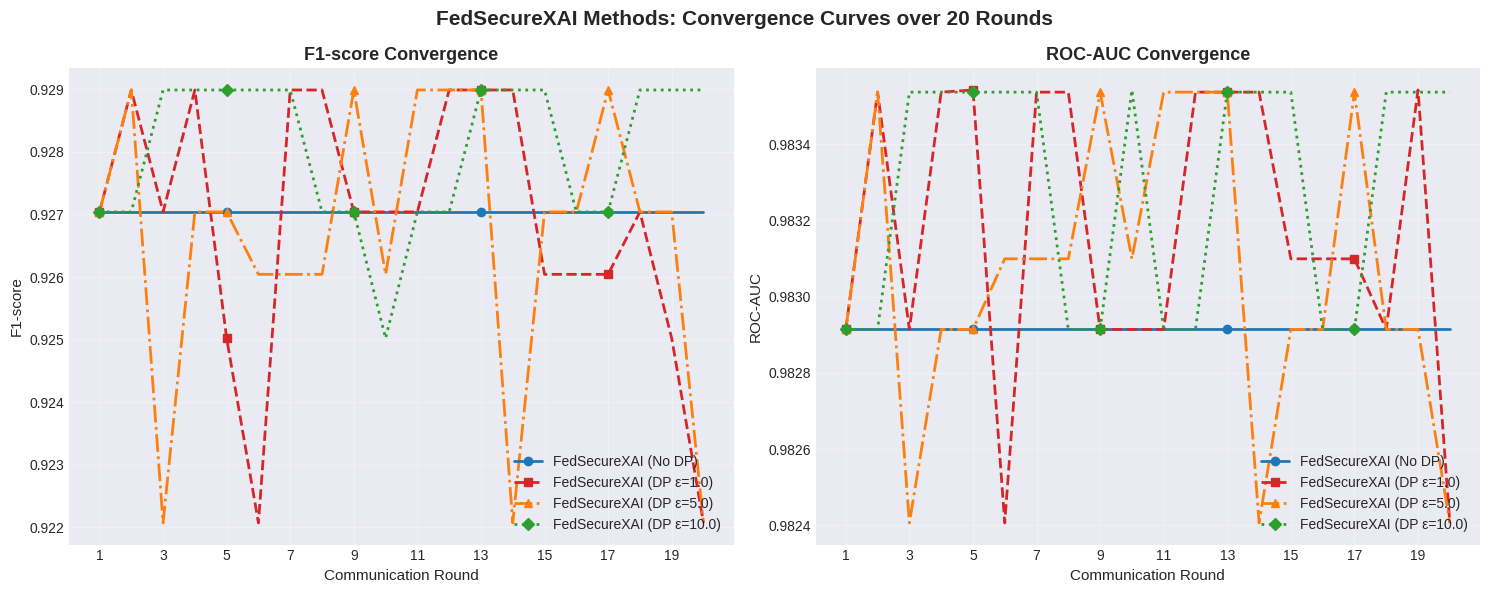

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

metrics = [("test_f1", "F1-score"), ("test_auc", "ROC-AUC")]

# Safely extract data
fsx_nodp = fsx_nodp_convergence if 'fsx_nodp_convergence' in globals() else {}
dp_data = dp_conv if 'dp_conv' in globals() else {}

styles = [
    ("FedSecureXAI (No DP)", fsx_nodp, "#1f77b4", "-", "o"),
    ("FedSecureXAI (DP ε=1.0)", dp_data.get(1.0, {}), "#d62728", "--", "s"),
    ("FedSecureXAI (DP ε=5.0)", dp_data.get(5.0, {}), "#ff7f0e", "-.", "^"),
    ("FedSecureXAI (DP ε=10.0)", dp_data.get(10.0, {}), "#2ca02c", ":", "D")
]

for i, (metric_key, metric_name) in enumerate(metrics):
    ax = axes[i]
    for label, data, color, ls, marker in styles:
        if data and metric_key in data:
            ax.plot(data["round"], data[metric_key], label=label,
                    color=color, linestyle=ls, marker=marker,
                    markersize=6, markevery=4, linewidth=2)
    ax.set_title(f"{metric_name} Convergence", fontsize=13, fontweight="bold")
    ax.set_xlabel("Communication Round", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="lower right")
    ax.set_xticks(range(1, 21, 2))

plt.suptitle("FedSecureXAI Methods: Convergence Curves over 20 Rounds", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fedsecurexai_convergence_custom.png", dpi=150)
plt.show()

In [12]:
latex_file_path = "fedsecurexai_exports/tables/fedsecurexai_main_table.tex"

try:
    with open(latex_file_path, "r") as f:
        print(f.read())
except FileNotFoundError:
    print(f"File not found: {latex_file_path}. Please make sure you have run Cell 11 to generate the exports.")

% Auto-generated by FedSecureXAI notebook — Cell 11
% Paste into your LaTeX document inside a table environment.
\begin{table}[ht]
\centering
\caption{Performance comparison of FedSecureXAI against baselines on the MeAJOR corpus.}
\label{tab:main_results}
\begin{tabular}{lrrrrr}
\toprule
\textbf{Method} & \textbf{Acc} & \textbf{Prec} & \textbf{Rec} & \textbf{F1} & \textbf{AUC} \\
\midrule
Centralized XGBoost & \textbf{0.9396} & 0.9320 & \textbf{0.9313} & \textbf{0.9316} & \textbf{0.9853} \\
FedAvg (IID) & 0.9355 & 0.9269 & 0.9271 & 0.9270 & 0.9829 \\
FedAvg (Non-IID) & 0.7212 & \textbf{0.9980} & 0.3698 & 0.5397 & 0.9652 \\
FedAvg (Qty-Skew) & 0.9320 & 0.9264 & 0.9192 & 0.9228 & 0.9827 \\
FedAvg Byzantine (20\%) & 0.9355 & 0.9269 & 0.9271 & 0.9270 & 0.9829 \\
FedSecureXAI Byzantine & 0.9355 & 0.9269 & 0.9271 & 0.9270 & 0.9829 \\
\bottomrule
\end{tabular}
\end{table}


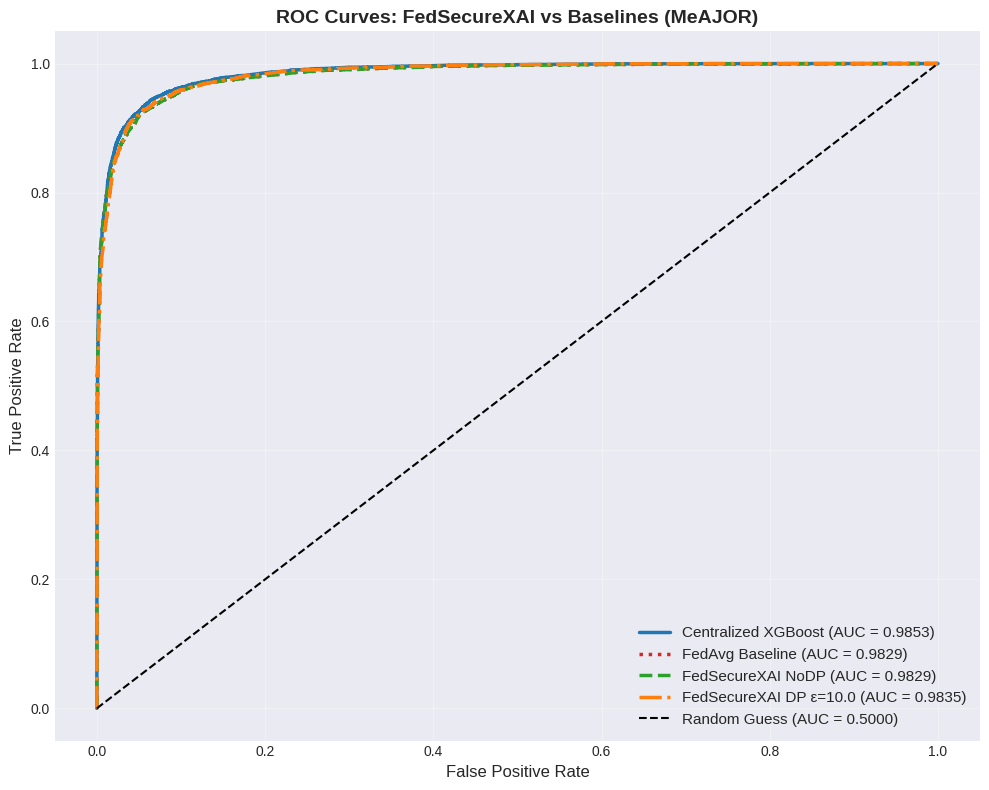

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# 1. Centralized XGBoost Baseline
if 'central_xgb_model' in globals():
    y_proba_cen = central_xgb_model.predict_proba(X_test)[:, 1]
    fpr_cen, tpr_cen, _ = roc_curve(y_test, y_proba_cen)
    roc_auc_cen = auc(fpr_cen, tpr_cen)
    plt.plot(fpr_cen, tpr_cen, label=f'Centralized XGBoost (AUC = {roc_auc_cen:.4f})',
             linewidth=2.5, linestyle='-', color='#1f77b4')

# 2. FedAvg Baseline (from Ablation Study)
if 'srv_abl' in globals() and getattr(srv_abl, 'aggregation', '') == 'fedavg':
    y_proba_fedavg = srv_abl.global_model.predict_proba(X_test)[:, 1]
    fpr_fedavg, tpr_fedavg, _ = roc_curve(y_test, y_proba_fedavg)
    roc_auc_fedavg = auc(fpr_fedavg, tpr_fedavg)
    plt.plot(fpr_fedavg, tpr_fedavg, label=f'FedAvg Baseline (AUC = {roc_auc_fedavg:.4f})',
             linewidth=2.5, linestyle=':', color='#d62728')

# 3. FedSecureXAI (No DP)
if 'srv_fsx_nodp' in globals():
    y_proba_fsx = srv_fsx_nodp.global_model.predict_proba(X_test)[:, 1]
    fpr_fsx, tpr_fsx, _ = roc_curve(y_test, y_proba_fsx)
    roc_auc_fsx = auc(fpr_fsx, tpr_fsx)
    plt.plot(fpr_fsx, tpr_fsx, label=f'FedSecureXAI NoDP (AUC = {roc_auc_fsx:.4f})',
             linewidth=2.5, linestyle='--', color='#2ca02c')

# 4. FedSecureXAI (DP eps=10.0)
if 'srv_dp' in globals():
    y_proba_dp = srv_dp.global_model.predict_proba(X_test)[:, 1]
    fpr_dp, tpr_dp, _ = roc_curve(y_test, y_proba_dp)
    roc_auc_dp = auc(fpr_dp, tpr_dp)
    plt.plot(fpr_dp, tpr_dp, label=f'FedSecureXAI DP ε=10.0 (AUC = {roc_auc_dp:.4f})',
             linewidth=2.5, linestyle='-.', color='#ff7f0e')

# Formatting
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: FedSecureXAI vs Baselines (MeAJOR)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig("figures/roc_curves_comparison_baselines.png", dpi=150)
plt.show()

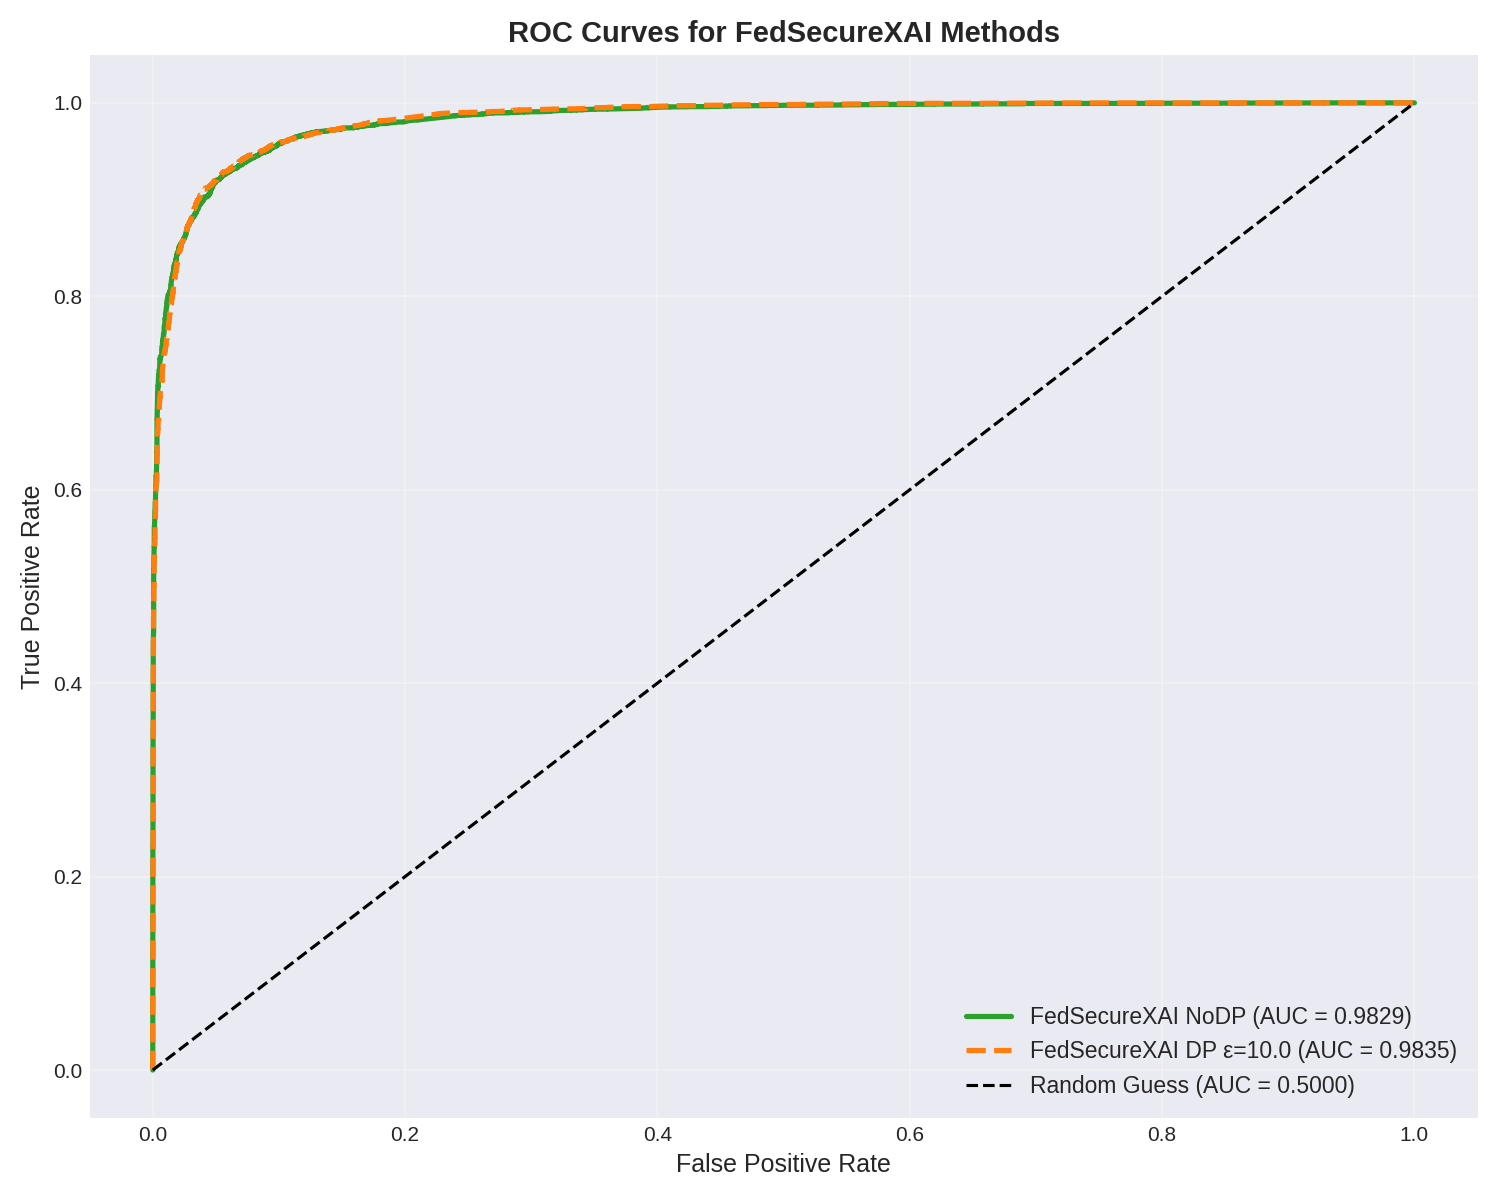

In [13]:
from IPython.display import Image, display
import os

image_path = "figures/roc_curves_fedsecurexai.png"
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}. Please re-run the cell that generates the ROC curves.")

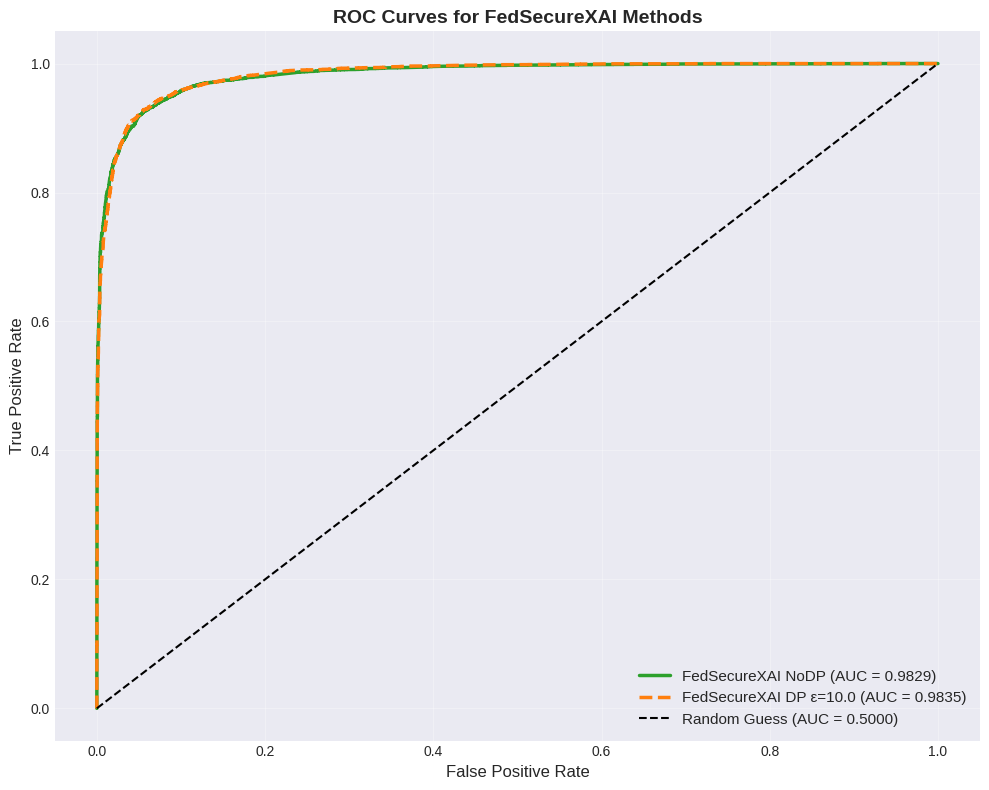

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
colors = ['#2ca02c', '#ff7f0e', '#1f77b4']
color_idx = 0

# 1. Plot FedSecureXAI (No DP)
if 'srv_fsx_nodp' in globals():
    try:
        y_proba_fsx = srv_fsx_nodp.global_model.predict_proba(X_test)[:, 1]
        fpr_fsx, tpr_fsx, _ = roc_curve(y_test, y_proba_fsx)
        roc_auc_fsx = auc(fpr_fsx, tpr_fsx)
        plt.plot(fpr_fsx, tpr_fsx, label=f'FedSecureXAI NoDP (AUC = {roc_auc_fsx:.4f})',
                 linewidth=2.5, linestyle='-', color=colors[color_idx])
        color_idx += 1
    except Exception as e:
        print(f"Could not plot FedSecureXAI NoDP: {e}")

# 2. Plot FedSecureXAI (DP eps=10.0)
if 'srv_dp' in globals():
    try:
        y_proba_dp = srv_dp.global_model.predict_proba(X_test)[:, 1]
        fpr_dp, tpr_dp, _ = roc_curve(y_test, y_proba_dp)
        roc_auc_dp = auc(fpr_dp, tpr_dp)
        plt.plot(fpr_dp, tpr_dp, label=f'FedSecureXAI DP ε=10.0 (AUC = {roc_auc_dp:.4f})',
                 linewidth=2.5, linestyle='--', color=colors[color_idx])
        color_idx += 1
    except Exception as e:
        print(f"Could not plot FedSecureXAI DP: {e}")

# Formatting
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for FedSecureXAI Methods', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig("figures/roc_curves_fedsecurexai.png", dpi=150)
plt.show()

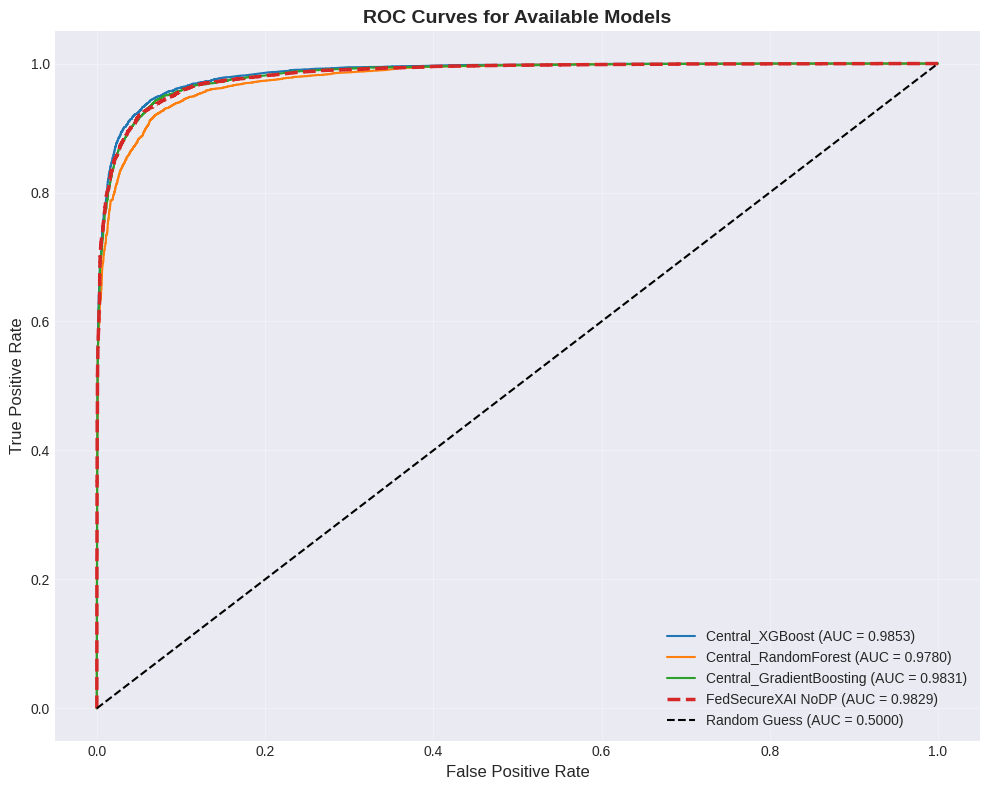

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_idx = 0

# 1. Plot Centralized Models
if 'central_models' in globals():
    for name, model in central_models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=colors[color_idx % len(colors)])
        color_idx += 1

# 2. Plot FedSecureXAI (No DP)
if 'srv_fsx_nodp' in globals():
    try:
        y_proba_fsx = srv_fsx_nodp.global_model.predict_proba(X_test)[:, 1]
        fpr_fsx, tpr_fsx, _ = roc_curve(y_test, y_proba_fsx)
        roc_auc_fsx = auc(fpr_fsx, tpr_fsx)
        plt.plot(fpr_fsx, tpr_fsx, label=f'FedSecureXAI NoDP (AUC = {roc_auc_fsx:.4f})',
                 linewidth=2.5, linestyle='--', color=colors[color_idx % len(colors)])
    except Exception as e:
        print(f"Could not plot FedSecureXAI: {e}")

# 3. Formatting
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for Available Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig("figures/roc_curves_available.png", dpi=150)
plt.show()